### [ACE-SWICS] Data analysis

### data load

데이터를 불러옵니다.

실행없이 출력 결과만 보고 싶으시다면, 왼쪽 목차에서 data review를 클릭하여 넘어가주셔도 좋습니다.

In [2]:
import numpy as np
import pandas as pd
import os
import glob
import datetime

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
inp_files = glob.glob('/content/drive/MyDrive/ace_level2_98_11/centered_20min_input/*.csv')
tar_file = '/content/drive/MyDrive/ace_level2_98_11/SWICS_all.csv'

In [5]:
inp_df = pd.DataFrame()
for file in inp_files:
    temp = pd.read_csv(file, engine="python", encoding="UTF-8")
    inp_df = pd.concat([inp_df, temp])

inp_df.head()

,datetime,Vp,Alpha_ratio,entropy,Alfvenicity,label1,label2,Np,Tp,coulomb num,sigma_r
0,1998-02-04 0:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1998-02-04 0:20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1998-02-04 0:40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1998-02-04 1:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1998-02-04 1:20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
tar_df = pd.read_csv(tar_file, engine="python", encoding="UTF-8")
tar_df.head()

,datetime,C6to5,O7to6,FetoO,datetime_re,Vp_avg,label1,label2,is_CME
0,1998-02-04 00:09:16.416,1.76360,0.36783,NaN,1998-02-04 00:00:00,NaN,NaN,NaN,0
1,1998-02-04 02:10:26.976,1.44520,0.36516,0.15177,1998-02-04 02:20:00,NaN,NaN,NaN,0
2,1998-02-04 04:11:38.400,0.93360,0.18537,0.53862,1998-02-04 04:20:00,NaN,NaN,NaN,1
3,1998-02-04 06:12:49.824,0.87715,0.37197,0.48157,1998-02-04 06:20:00,NaN,NaN,NaN,1
4,1998-02-04 08:14:01.248,1.50650,0.30744,0.57538,1998-02-04 08:20:00,NaN,NaN,NaN,1


In [7]:
inp_df['datetime'] = pd.to_datetime(inp_df['datetime'])
tar_df['datetime_re'] = pd.to_datetime(tar_df['datetime_re'])

In [8]:
inp_time = inp_df['datetime']
tar_time = tar_df['datetime_re'][1:]

In [9]:
time_to_idx = {t: i for i, t in enumerate(inp_time)}
idxs = np.array([time_to_idx[t] for t in tar_time], dtype=int)

inp_data_col = ['Vp', 'Alpha_ratio', 'entropy', 'Alfvenicity', 'Np', 'Tp', 'coulomb num']
inp_df['Alfvenicity'] = inp_df['Alfvenicity'].abs() # abs(Alfvenicity)
tar_data_col = ['C6to5', 'O7to6', 'FetoO', 'is_CME']

inp_array = inp_df[inp_data_col].values
tar_array = tar_df[tar_data_col].values[1:]
is_cme_array = tar_df['is_CME'].values[1:]

inp_windows = np.full((len(idxs), 7, len(inp_data_col)), np.nan, dtype=float)

for i, idx in enumerate(idxs):
    inp_windows[i] = inp_array[idx-3:idx+4]

In [10]:
inp_windows.shape

(59178, 7, 7)

In [11]:
tar_array.shape

(59178, 4)

In [12]:
tar_missing = set(np.where(np.isnan(tar_array))[0])
inp_missing = set(np.where(np.isnan(inp_windows).sum(axis=1) >= 5.)[0])

In [13]:
missing_idx = tar_missing | inp_missing
valid_idx = sorted(list(set(range(len(tar_array))) - missing_idx))

In [14]:
len(tar_time)

59178

In [15]:
inp = inp_windows[valid_idx]
tar = tar_array[valid_idx]
time = tar_time.values[valid_idx]
is_cme = is_cme_array[valid_idx]

In [16]:
print("입력 데이터(inp) shape:", inp.shape)
print("타겟 데이터(tar) shape:", tar.shape)
print("시간 데이터(time) shape:", time.shape)
print("CME (is_cme) shape:", is_cme.shape)

입력 데이터(inp) shape: (39436, 7, 7)
타겟 데이터(tar) shape: (39436, 4)
시간 데이터(time) shape: (39436,)
CME (is_cme) shape: (39436,)


### Data review & EDA



### distribution

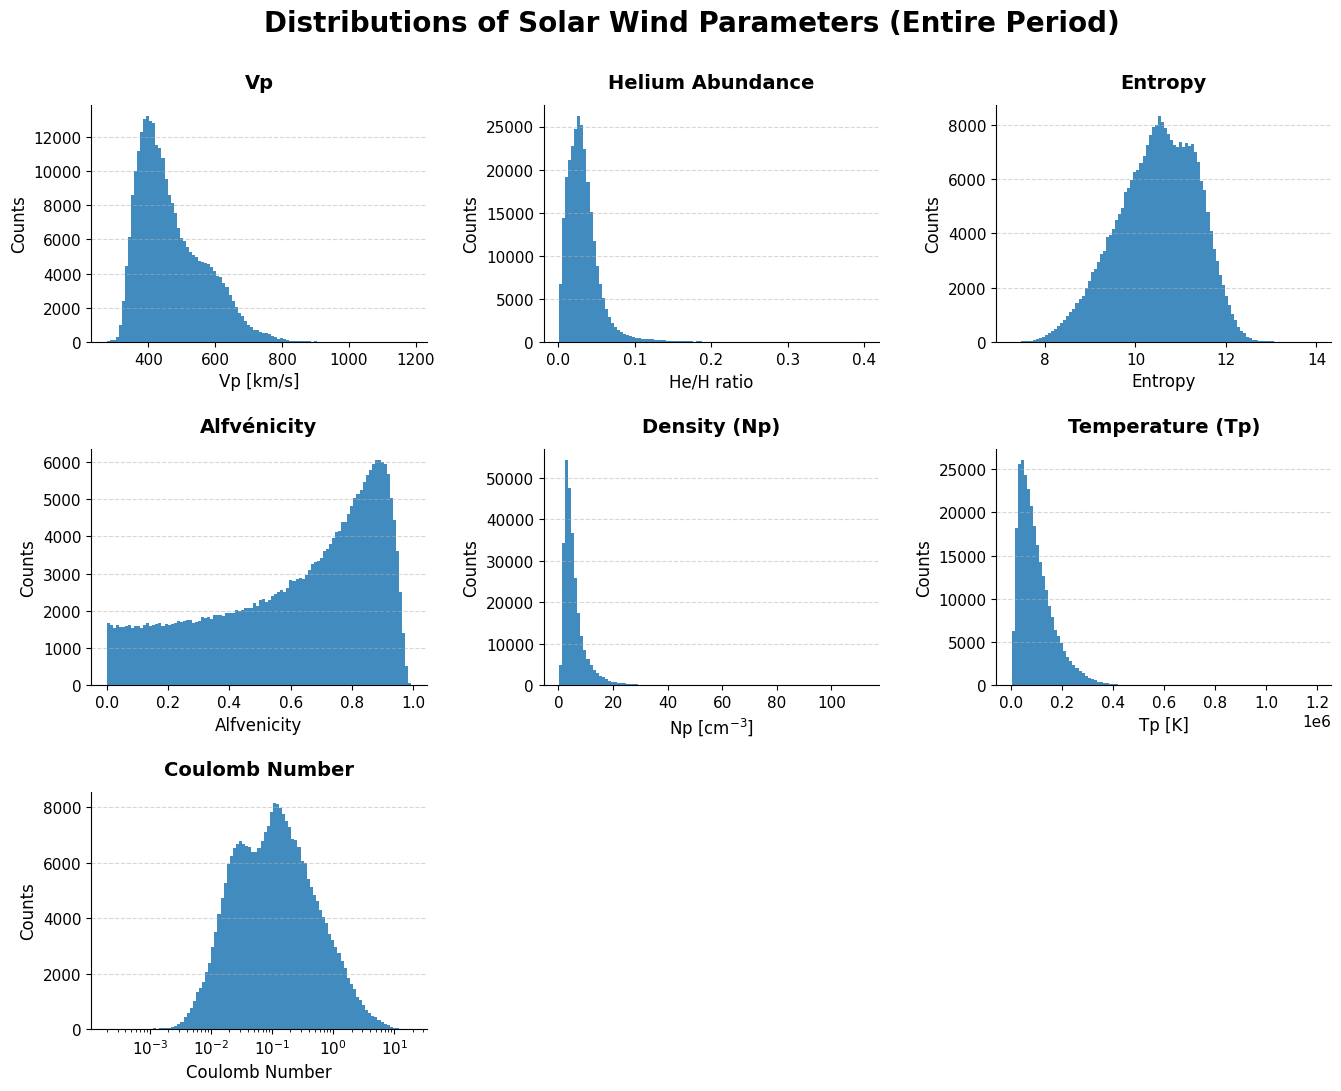

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

# 데이터 준비
inp_flat = inp.reshape(-1, 7)

vp = inp_flat[:, 0]          # 0: Vp (속도)
alpha_ratio = inp_flat[:, 1] # 1: Alpha_ratio (헬륨비)
entropy = inp_flat[:, 2]     # 2: Entropy (엔트로피)
alfvenicity = inp_flat[:, 3] # 3: Alfvenicity (알펜성)
np_dens = inp_flat[:, 4]     # 4: Np (밀도)
tp = inp_flat[:, 5]          # 5: Tp (온도)
coulomb = inp_flat[:, 6]     # 6: coulomb num (충돌 수)

# 그래프를 그릴 7개의 변수 리스트 구성
variables = [
    (vp, 'Vp', 'Vp [km/s]'),
    (alpha_ratio, 'Helium Abundance', 'He/H ratio'),
    (entropy, 'Entropy', 'Entropy'),
    (alfvenicity, 'Alfvénicity', 'Alfvenicity'),
    (np_dens, 'Density (Np)', 'Np [cm$^{-3}$]'),
    (tp, 'Temperature (Tp)', 'Tp [K]'),
    (coulomb, 'Coulomb Number', 'Coulomb Number') # C num만 x축 로그 적용
]

# 3x3 형태의 서브플롯 생성
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
plt.subplots_adjust(hspace=0.45, wspace=0.35)
axes = axes.flatten()

# 색상 지정
plot_color = '#1f77b4'

# 각 물리량별 1D 히스토그램 그리기
for i, (var, title, xlabel) in enumerate(variables):
    # 결측치(NaN) 제외
    valid_mask = ~np.isnan(var)
    var_valid = var[valid_mask]

    # 테두리 처리 (위, 오른쪽 선 제거)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    # y축 기준 연한 점선 그리드 추가
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

    if title == 'Coulomb Number':
        # 0 이하 값 제외 (로그 스케일을 위해)
        positive_mask = var_valid > 0
        var_valid = var_valid[positive_mask]

        # x축 로그 스케일 빈(bins) 생성
        x_bins = np.logspace(np.log10(var_valid.min()), np.log10(var_valid.max()), 100)

        # 히스토그램 그리기
        axes[i].hist(var_valid, bins=x_bins, color=plot_color, alpha=0.85)
        axes[i].set_xscale('log') # Coulomb Number x축 로그 스케일 적용
    else:
        # 나머지 변수들은 일반 선형(Linear) 스케일로 히스토그램을 그린다.
        axes[i].hist(var_valid, bins=100, color=plot_color, alpha=0.85)

    # 제목 & 축 이름 설정
    axes[i].set_title(title, fontweight='bold', pad=12)
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel('Counts')

    axes[7].axis('off') # 빈 서브플롯 숨기기
    axes[8].axis('off')

plt.suptitle('Distributions of Solar Wind Parameters (Entire Period)', fontsize=20, fontweight='bold', y=0.96)
plt.show()


태양풍 물리량들에 대한 "2차원 히스토그램(2D histogram)"
- 변수 간 분포와 관계를 시각화하여, 해석하는 것을 목적으로 한다.

- 태양풍 속도 vs 양성자 개수 밀도
- 태양풍 속도 vs 양성자 온도
- 태양풍 속도 vs 헬륨 abundance
- 태양풍 속도 vs Coulomb collision number
- 태양풍 속도 vs Alfvénicity


### Vp vs ...

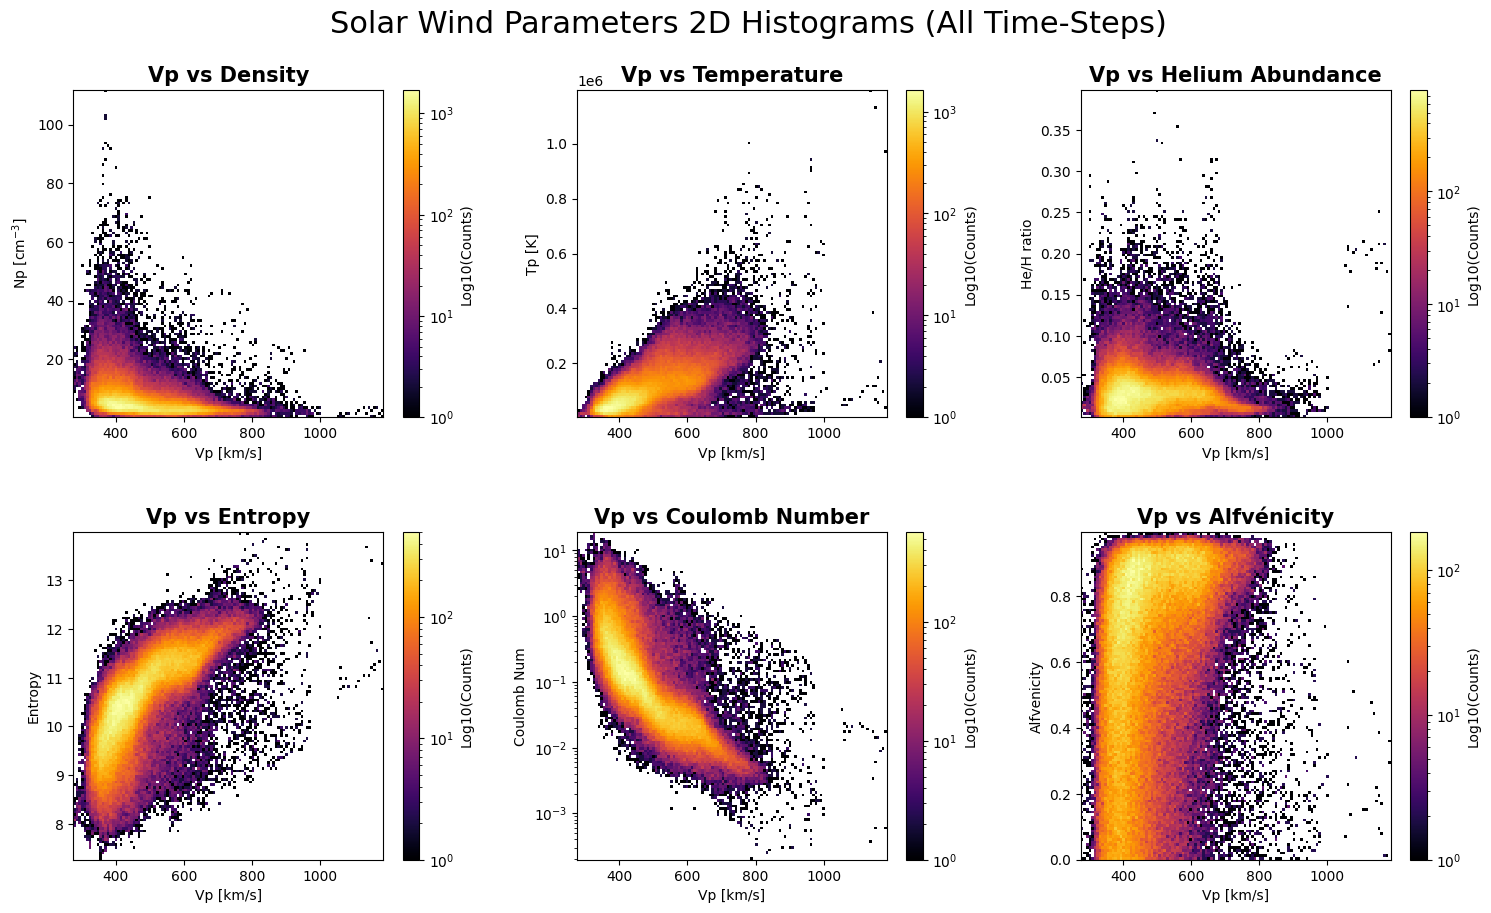

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

inp_flat = inp.reshape(-1, 7)

vp = inp_flat[:, 0]          # 0: Vp (속도)
alpha_ratio = inp_flat[:, 1] # 1: Alpha_ratio (헬륨비)
entropy = inp_flat[:, 2]     # 2: Entropy (엔트로피)
alfvenicity = inp_flat[:, 3] # 3: Alfvenicity (알펜성)
np_dens = inp_flat[:, 4]     # 4: Np (밀도)
tp = inp_flat[:, 5]          # 5: Tp (온도)
coulomb = inp_flat[:, 6]     # 6: coulomb num (충돌 수)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(hspace=0.35, wspace=0.3)
axes = axes.flatten()

# pairing
relations = [
    (vp, np_dens, 'Vp vs Density', 'Vp [km/s]', 'Np [cm$^{-3}$]'),
    (vp, tp, 'Vp vs Temperature', 'Vp [km/s]', 'Tp [K]'),
    (vp, alpha_ratio, 'Vp vs Helium Abundance', 'Vp [km/s]', 'He/H ratio'),
    (vp, entropy, 'Vp vs Entropy', 'Vp [km/s]', 'Entropy'),
    (vp, coulomb, 'Vp vs Coulomb Number', 'Vp [km/s]', 'Coulomb Num'),
    (vp, alfvenicity, 'Vp vs Alfvénicity', 'Vp [km/s]', 'Alfvenicity')
]

# 그래프 그리기
for i, (x, y, title, xlabel, ylabel) in enumerate(relations):
    # 결측치(NaN) 제외
    valid_mask = ~np.isnan(x) & ~np.isnan(y)
    x_valid = x[valid_mask]
    y_valid = y[valid_mask]

    if title == 'Vp vs Coulomb Number':
        # 0 이하 값 제외 및 y축 로그 스케일 빈(bins) 생성
        positive_mask = y_valid > 0
        x_valid = x_valid[positive_mask]
        y_valid = y_valid[positive_mask]

        y_bins = np.logspace(np.log10(y_valid.min()), np.log10(y_valid.max()), 120)

        # 데이터 분포
        counts, xedges, yedges, im = axes[i].hist2d(
            x_valid, y_valid, bins=[120, y_bins], cmap='inferno', norm=mcolors.LogNorm()
        )
        axes[i].set_yscale('log')
    else:
        # 데이터 분포
        counts, xedges, yedges, im = axes[i].hist2d(
            x_valid, y_valid, bins=120, cmap='inferno', norm=mcolors.LogNorm()
        )

    # 제목 & 축 이름
    axes[i].set_title(title, fontsize=15, fontweight='bold')
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel(ylabel)

    fig.colorbar(im, ax=axes[i], label='Log10(Counts)')

plt.suptitle('Solar Wind Parameters 2D Histograms (All Time-Steps)', fontsize=22, y=0.96)
plt.show()

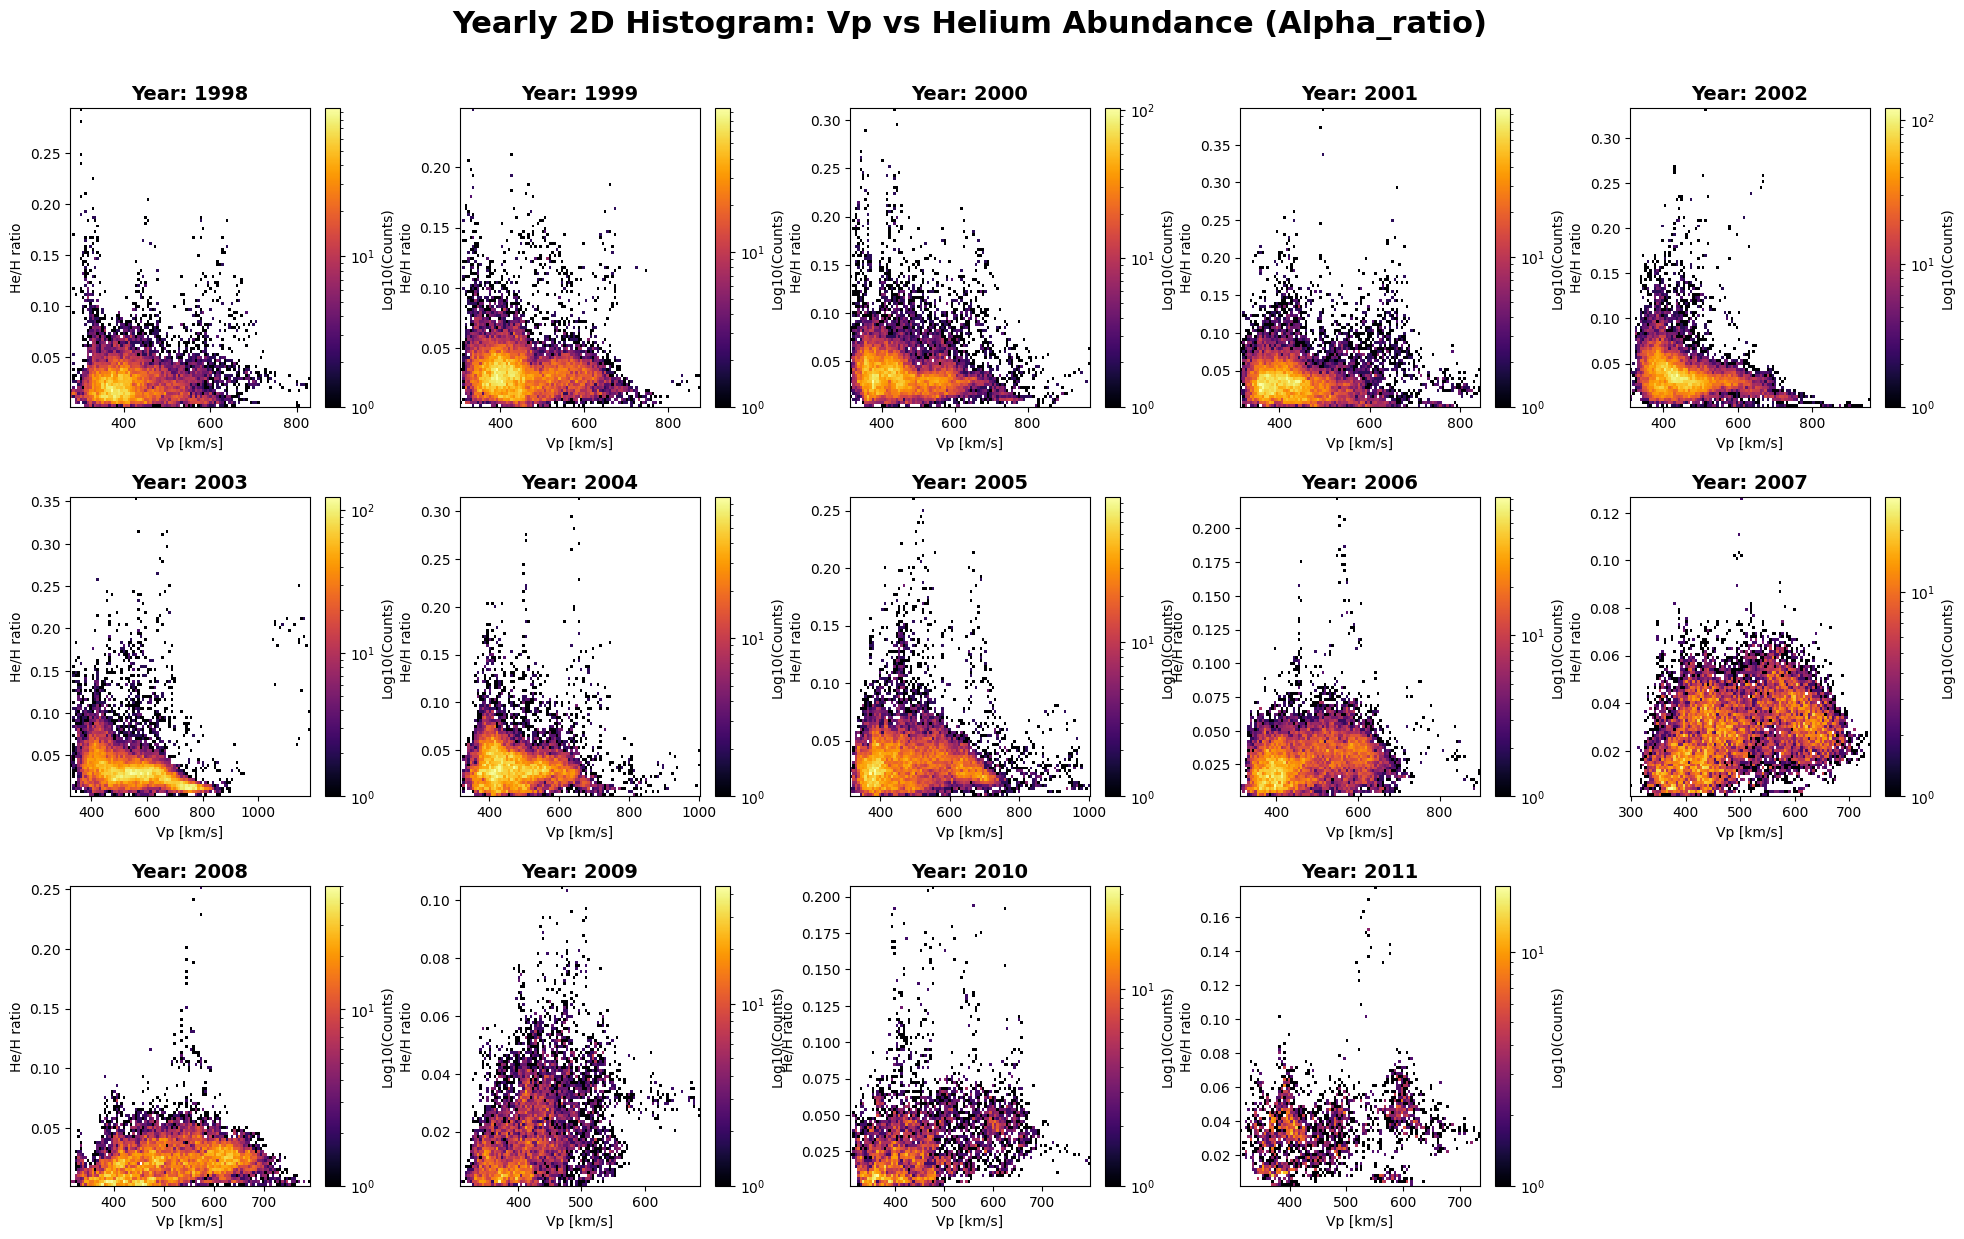

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 데이터를 2D로 평탄화 (276052, 7)
inp_flat = inp.reshape(-1, 7)

# time 배열을 inp_flat 길이에 맞게 확장 (1개 샘플당 7개 타임스텝)
repeated_time = np.repeat(time, 7)

# 각 데이터 포인트의 연도(Year) 추출하여 저장한다.
years_array = pd.to_datetime(repeated_time).year
unique_years = np.sort(np.unique(years_array))

vp = inp_flat[:, 0]
target_var = inp_flat[:, 1] # 1: Alpha_ratio

fig, axes = plt.subplots(3, 5, figsize=(24, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()

for i, y_val in enumerate(unique_years):
    mask = (years_array == y_val) & ~np.isnan(vp) & ~np.isnan(target_var)
    x_year = vp[mask]
    y_year = target_var[mask]

    if len(x_year) > 0:
        counts, xedges, yedges, im = axes[i].hist2d(
            x_year, y_year, bins=100, cmap='inferno', norm=mcolors.LogNorm()
        )
        axes[i].set_title(f'Year: {y_val}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Vp [km/s]')
        axes[i].set_ylabel('He/H ratio')
        fig.colorbar(im, ax=axes[i], label='Log10(Counts)')

# 남는 빈 그래프 공간 숨기기
for j in range(len(unique_years), len(axes)):
    axes[j].axis('off')

plt.suptitle('Yearly 2D Histogram: Vp vs Helium Abundance (Alpha_ratio)', fontsize=22, fontweight='bold', y=0.95)
plt.show()

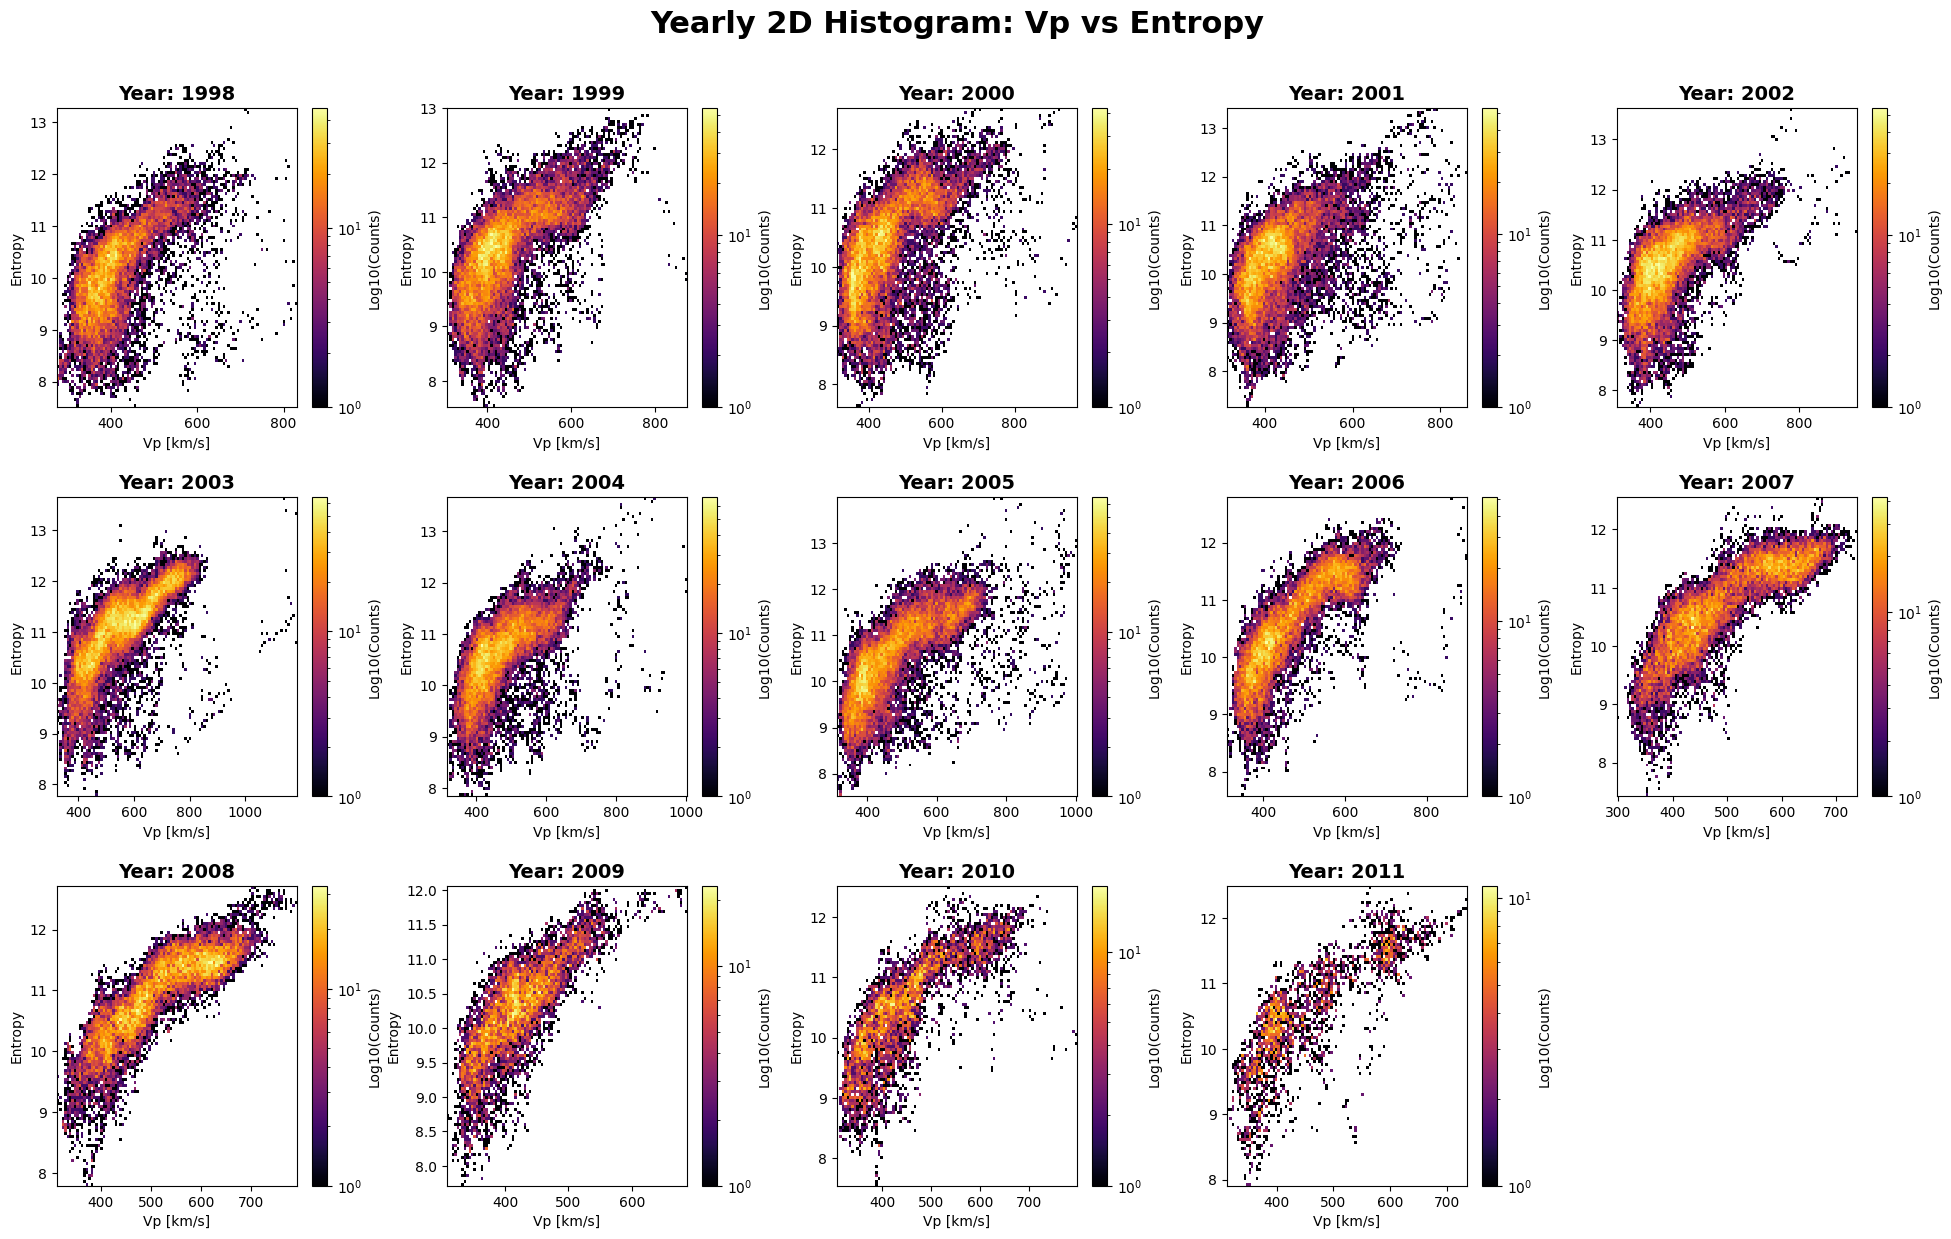

In [20]:
vp = inp_flat[:, 0]
target_var = inp_flat[:, 2] # 2: Entropy

fig, axes = plt.subplots(3, 5, figsize=(24, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()

for i, y_val in enumerate(unique_years):
    mask = (years_array == y_val) & ~np.isnan(vp) & ~np.isnan(target_var)
    x_year = vp[mask]
    y_year = target_var[mask]

    if len(x_year) > 0:
        counts, xedges, yedges, im = axes[i].hist2d(
            x_year, y_year, bins=100, cmap='inferno', norm=mcolors.LogNorm()
        )
        axes[i].set_title(f'Year: {y_val}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Vp [km/s]')
        axes[i].set_ylabel('Entropy')
        fig.colorbar(im, ax=axes[i], label='Log10(Counts)')

for j in range(len(unique_years), len(axes)):
    axes[j].axis('off')

plt.suptitle('Yearly 2D Histogram: Vp vs Entropy', fontsize=22, fontweight='bold', y=0.95)
plt.show()

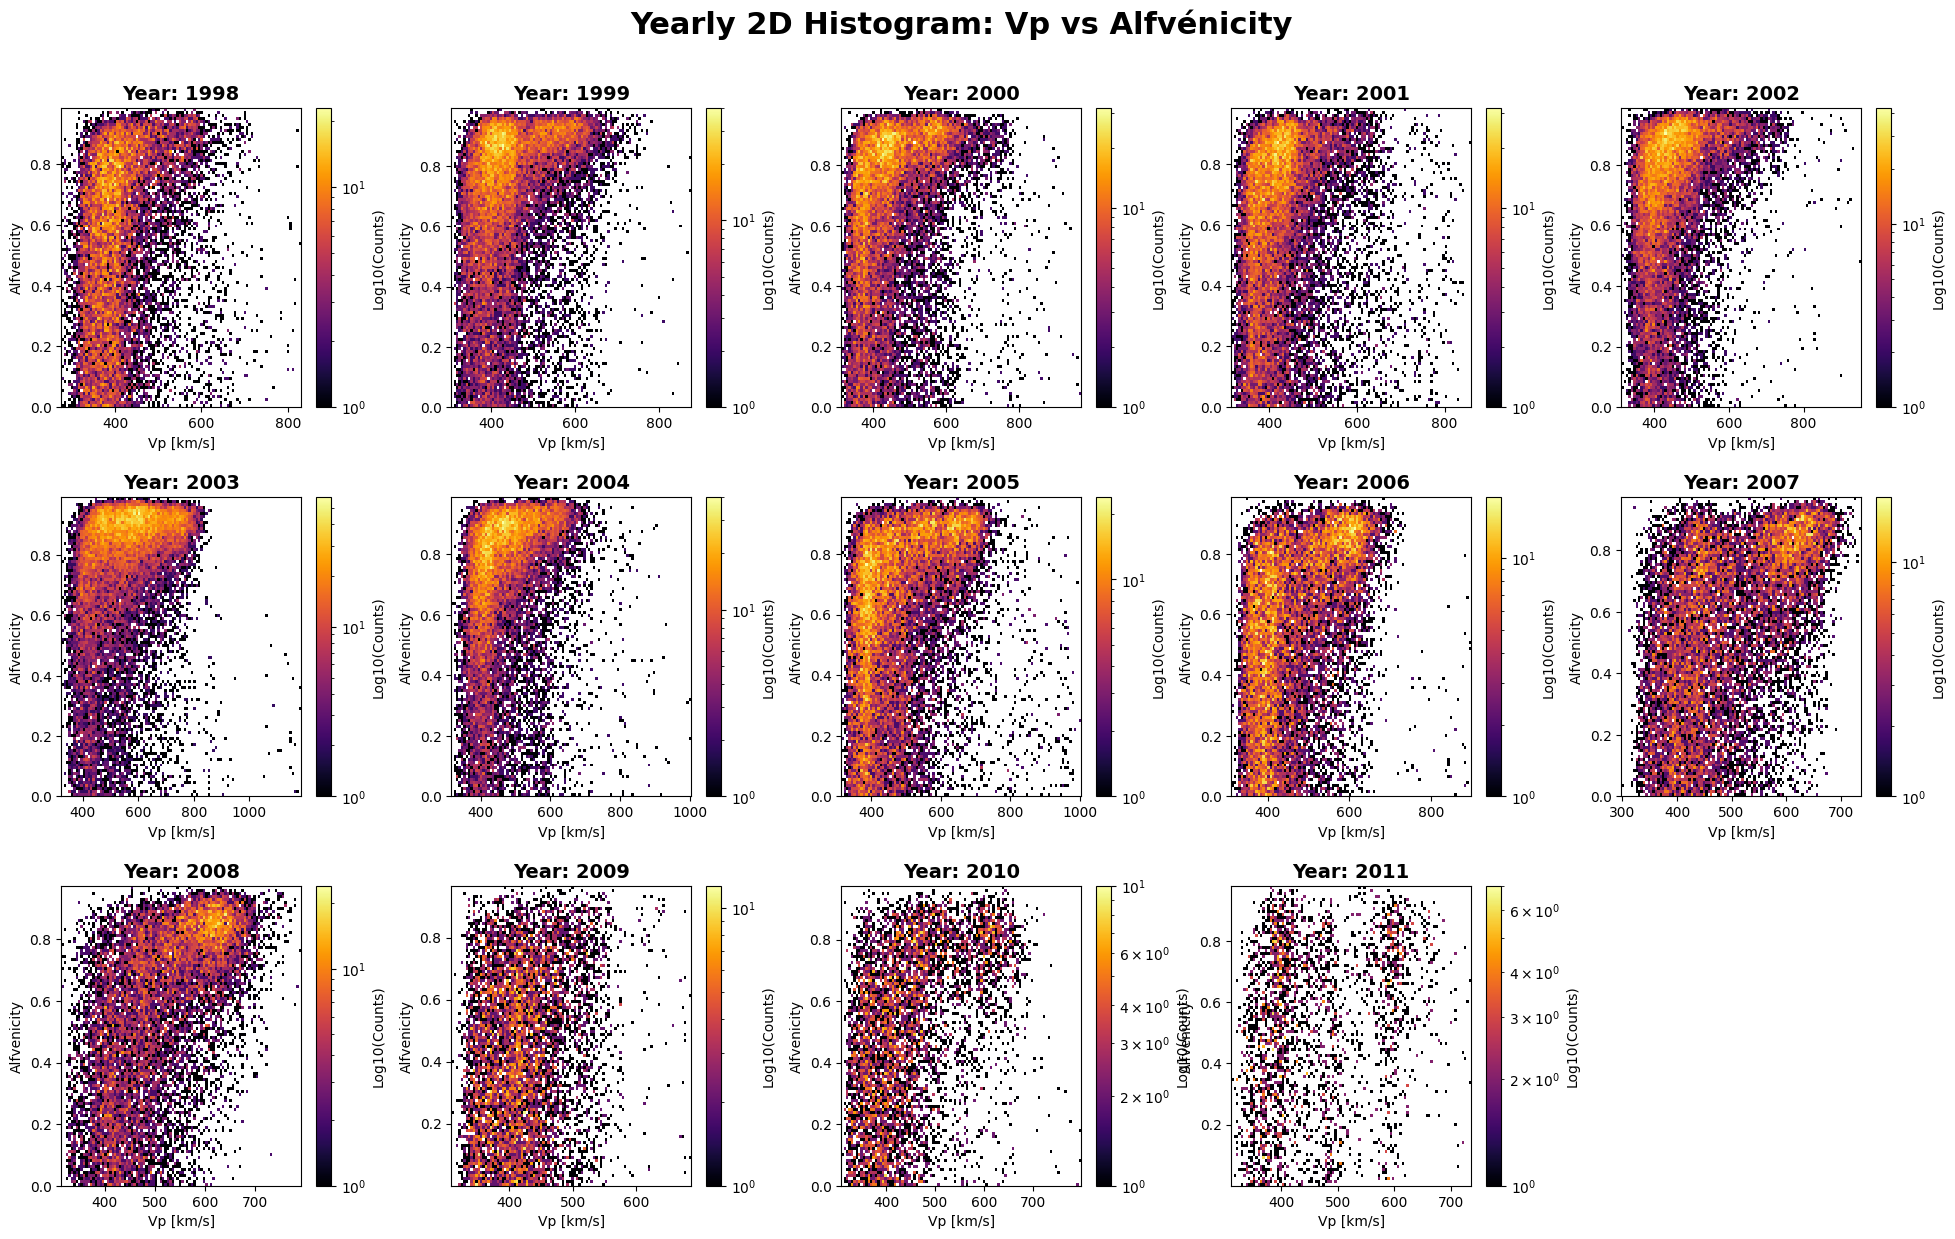

In [21]:
vp = inp_flat[:, 0]
target_var = inp_flat[:, 3] # 3: Alfvenicity

fig, axes = plt.subplots(3, 5, figsize=(24, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()

for i, y_val in enumerate(unique_years):
    mask = (years_array == y_val) & ~np.isnan(vp) & ~np.isnan(target_var)
    x_year = vp[mask]
    y_year = target_var[mask]

    if len(x_year) > 0:
        counts, xedges, yedges, im = axes[i].hist2d(
            x_year, y_year, bins=100, cmap='inferno', norm=mcolors.LogNorm()
        )
        axes[i].set_title(f'Year: {y_val}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Vp [km/s]')
        axes[i].set_ylabel('Alfvenicity')
        fig.colorbar(im, ax=axes[i], label='Log10(Counts)')

for j in range(len(unique_years), len(axes)):
    axes[j].axis('off')

plt.suptitle('Yearly 2D Histogram: Vp vs Alfvénicity', fontsize=22, fontweight='bold', y=0.95)
plt.show()

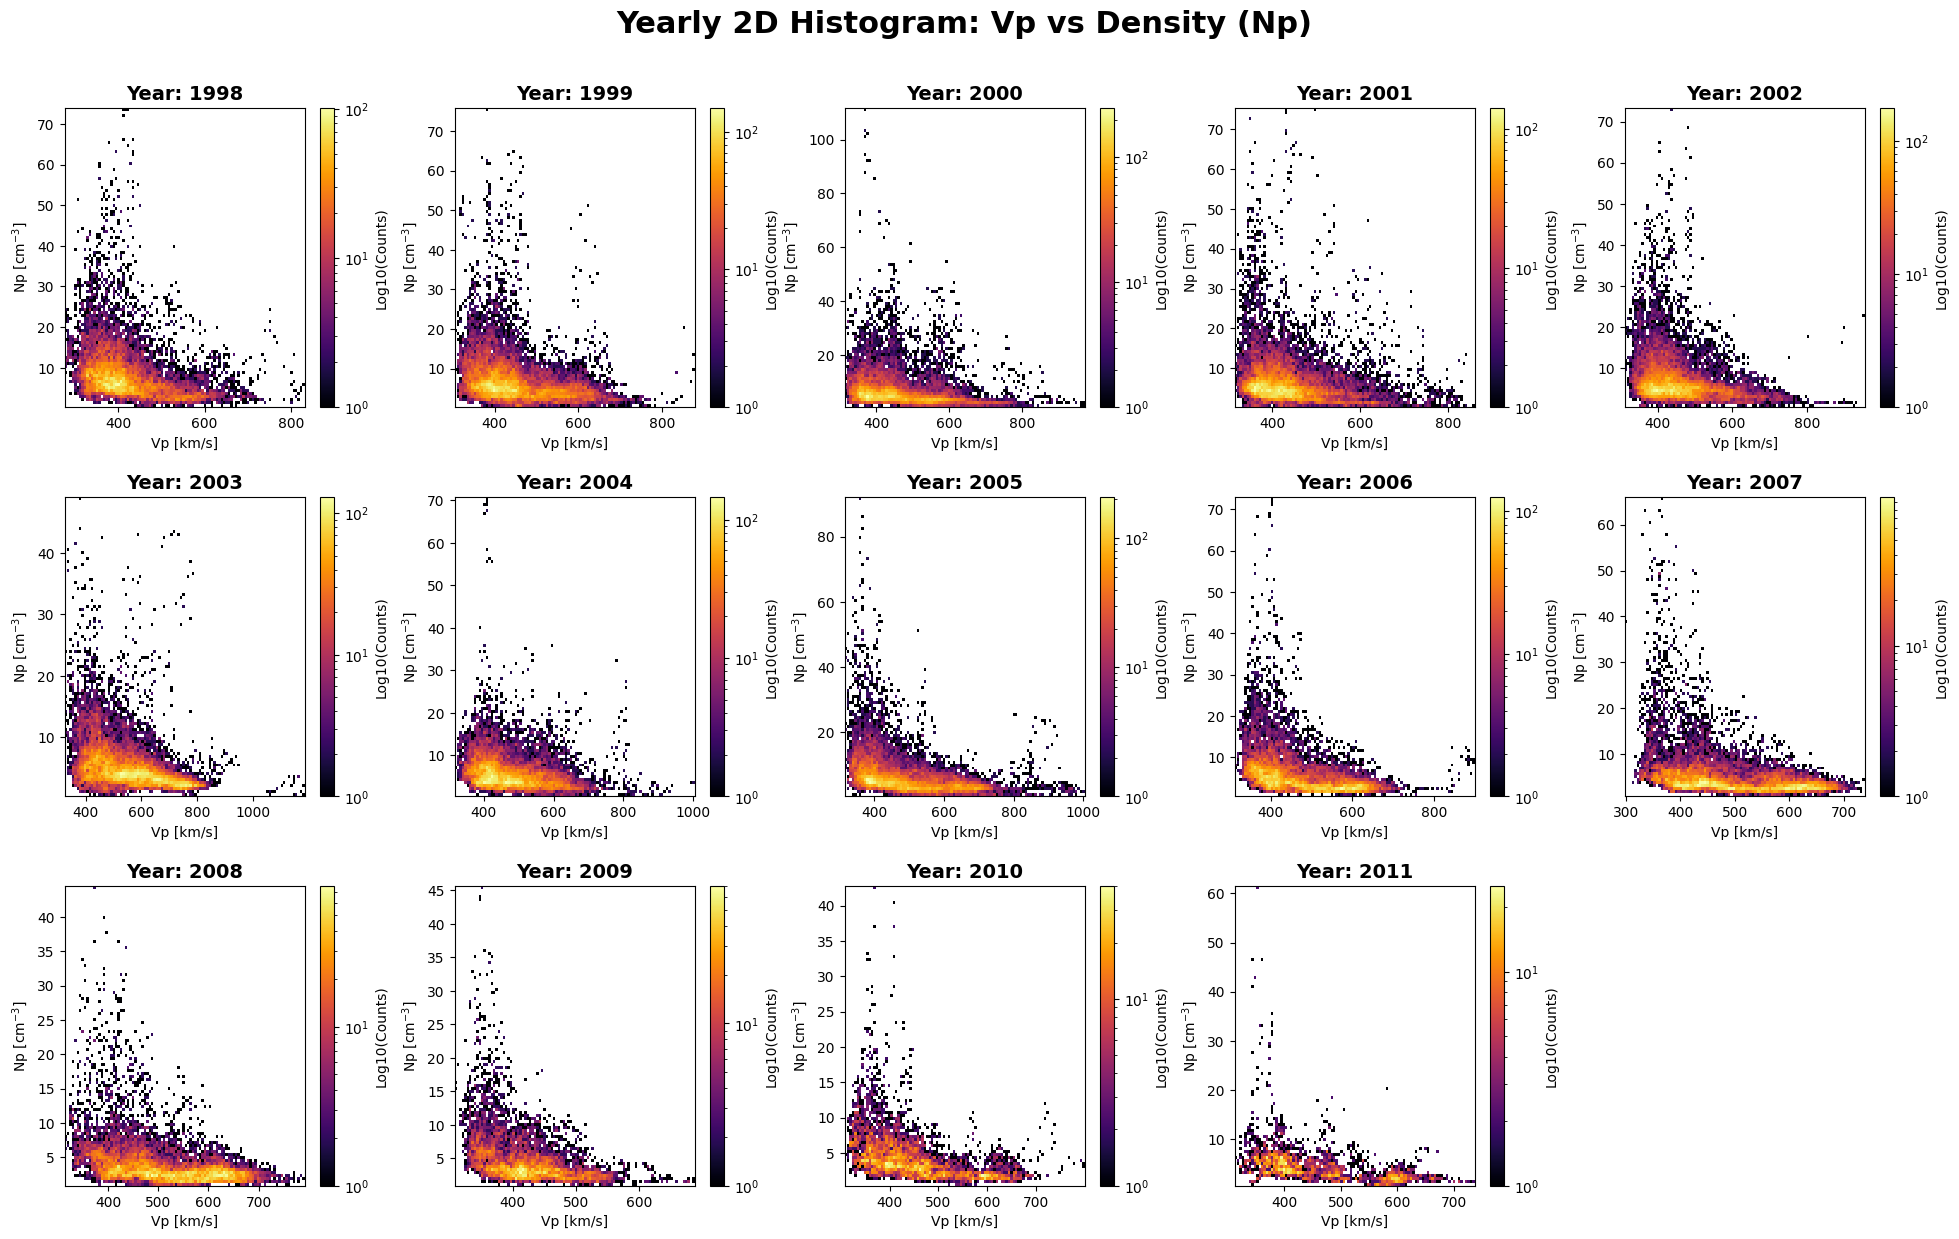

In [22]:
vp = inp_flat[:, 0]
target_var = inp_flat[:, 4] # 4: Np

fig, axes = plt.subplots(3, 5, figsize=(24, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()

for i, y_val in enumerate(unique_years):
    mask = (years_array == y_val) & ~np.isnan(vp) & ~np.isnan(target_var)
    x_year = vp[mask]
    y_year = target_var[mask]

    if len(x_year) > 0:
        counts, xedges, yedges, im = axes[i].hist2d(
            x_year, y_year, bins=100, cmap='inferno', norm=mcolors.LogNorm()
        )
        axes[i].set_title(f'Year: {y_val}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Vp [km/s]')
        axes[i].set_ylabel('Np [cm$^{-3}$]')
        fig.colorbar(im, ax=axes[i], label='Log10(Counts)')

for j in range(len(unique_years), len(axes)):
    axes[j].axis('off')

plt.suptitle('Yearly 2D Histogram: Vp vs Density (Np)', fontsize=22, fontweight='bold', y=0.95)
plt.show()

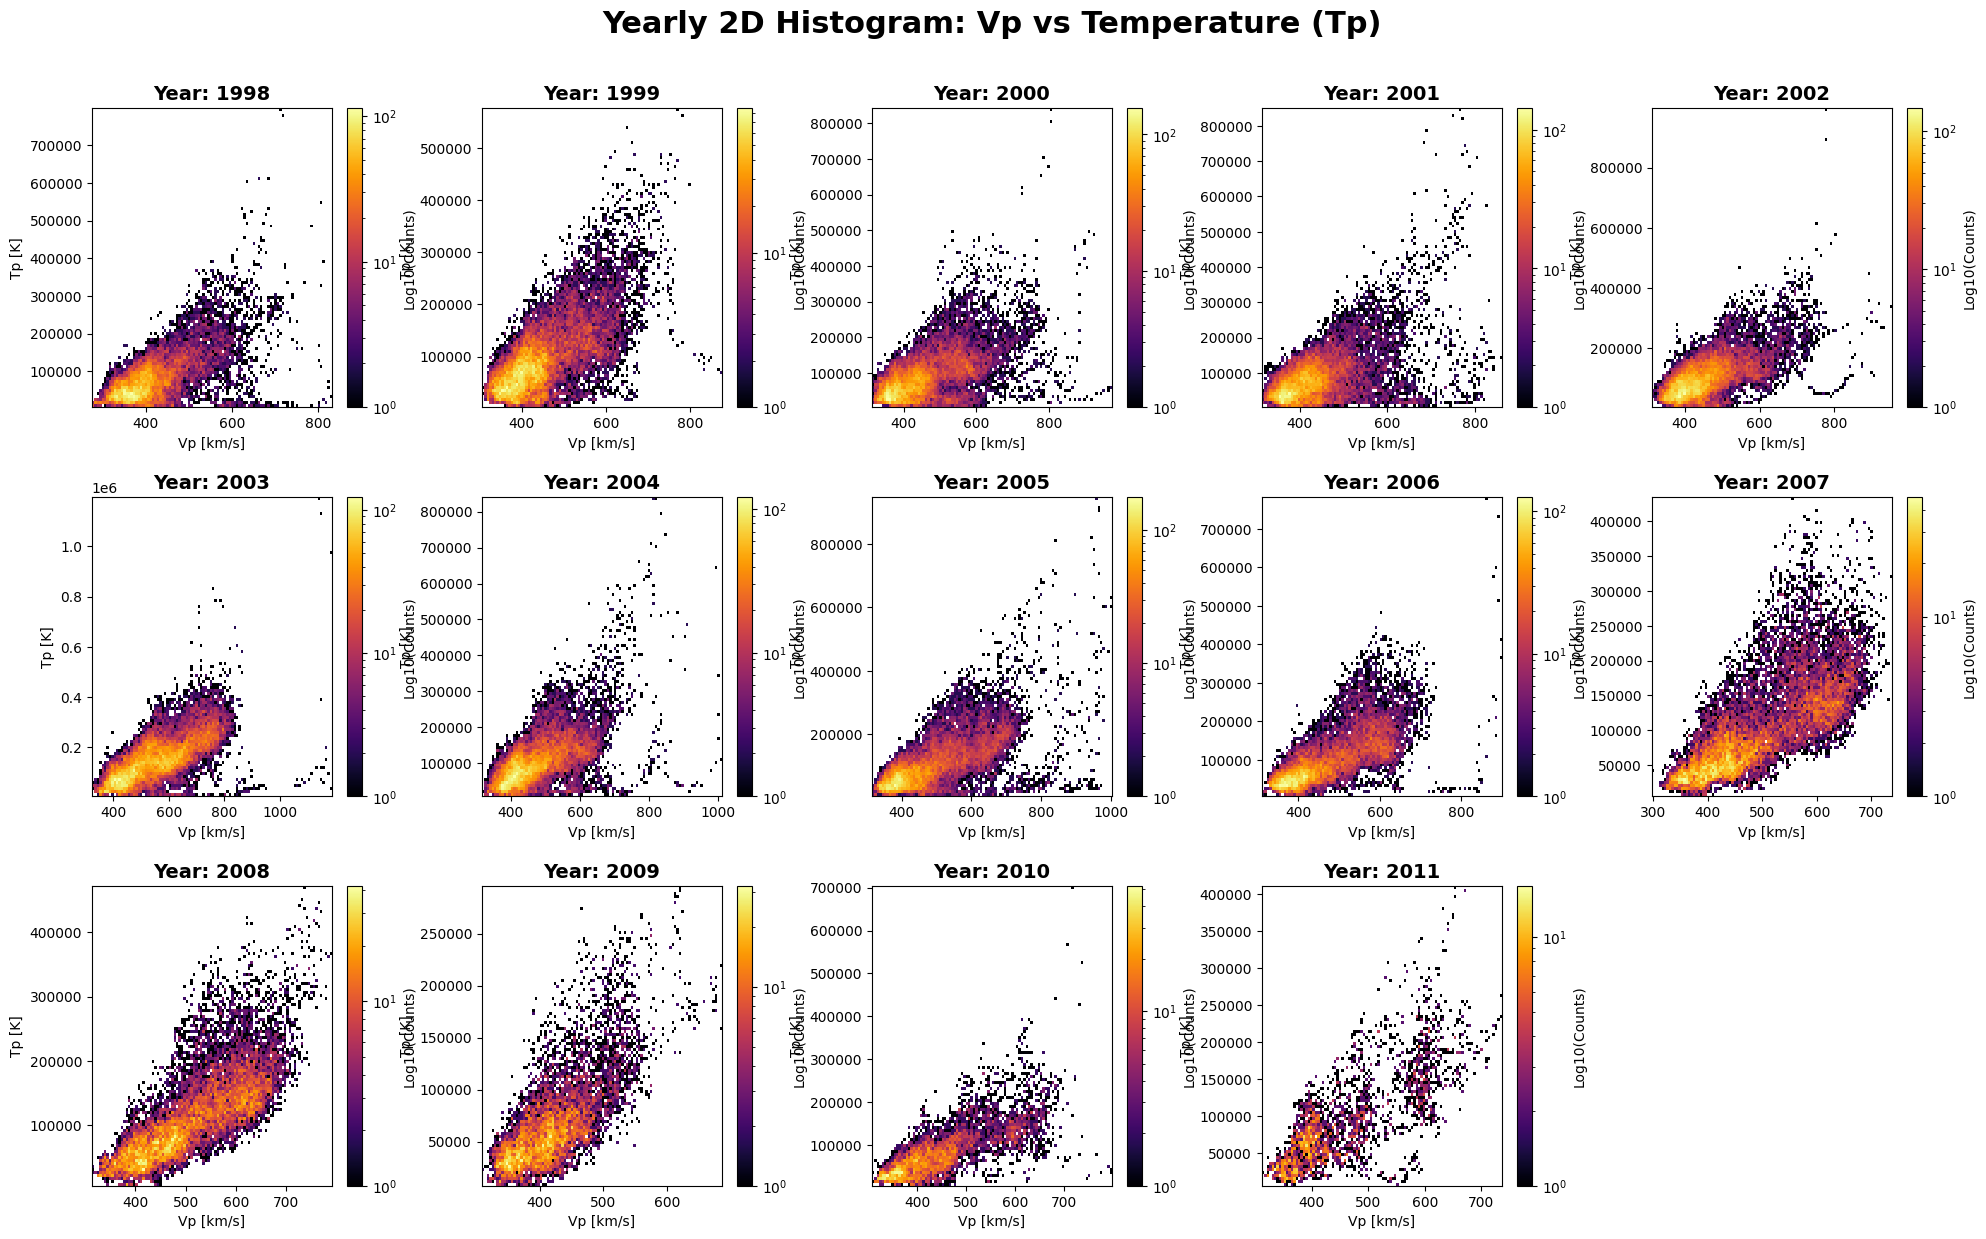

In [23]:
vp = inp_flat[:, 0]
target_var = inp_flat[:, 5] # 5: Tp

fig, axes = plt.subplots(3, 5, figsize=(24, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()

for i, y_val in enumerate(unique_years):
    mask = (years_array == y_val) & ~np.isnan(vp) & ~np.isnan(target_var)
    x_year = vp[mask]
    y_year = target_var[mask]

    if len(x_year) > 0:
        counts, xedges, yedges, im = axes[i].hist2d(
            x_year, y_year, bins=100, cmap='inferno', norm=mcolors.LogNorm()
        )
        axes[i].set_title(f'Year: {y_val}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Vp [km/s]')
        axes[i].set_ylabel('Tp [K]')
        fig.colorbar(im, ax=axes[i], label='Log10(Counts)')

for j in range(len(unique_years), len(axes)):
    axes[j].axis('off')

plt.suptitle('Yearly 2D Histogram: Vp vs Temperature (Tp)', fontsize=22, fontweight='bold', y=0.95)
plt.show()

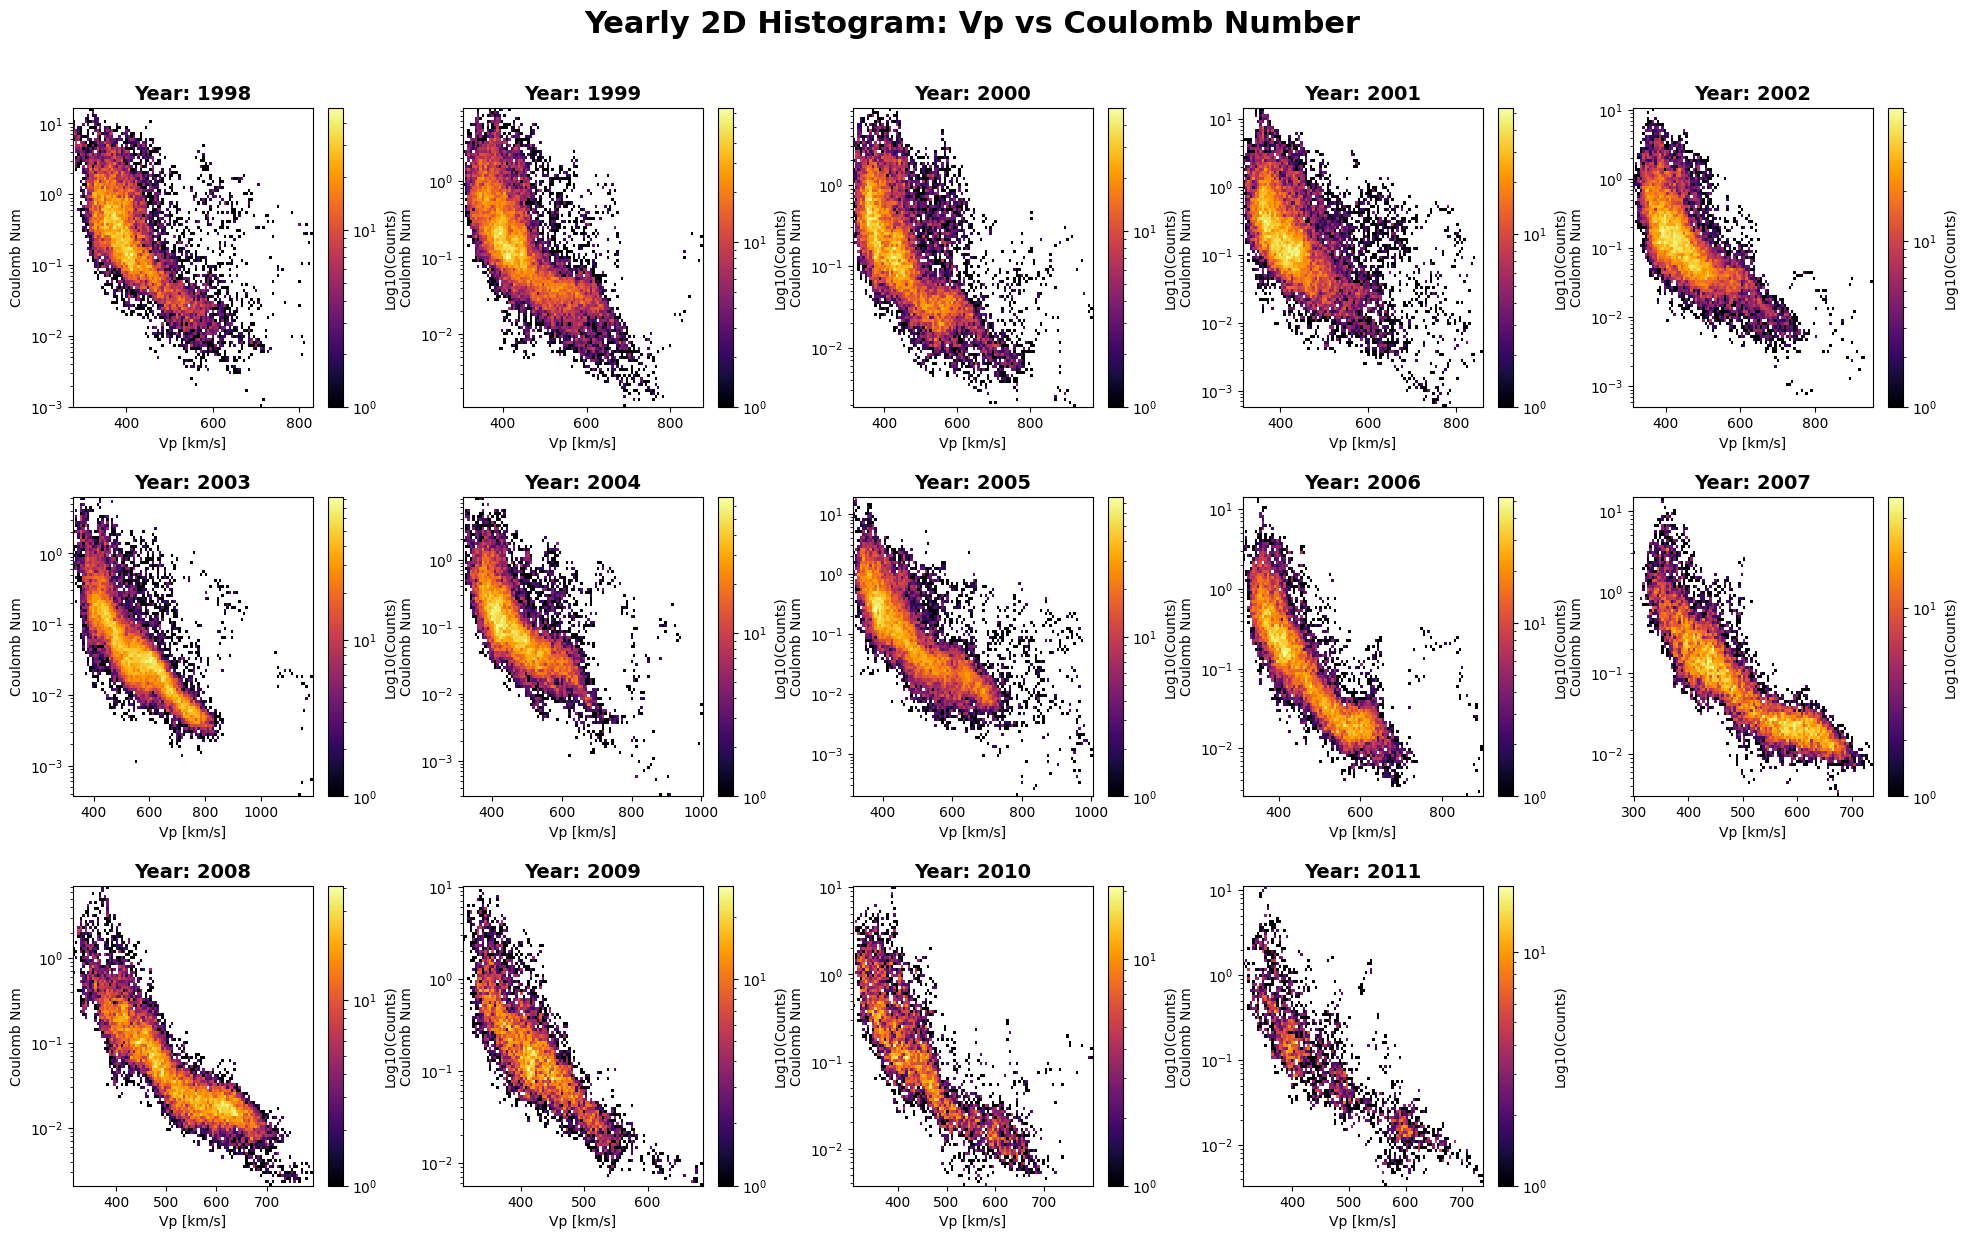

In [24]:
vp = inp_flat[:, 0]
target_var = inp_flat[:, 6] # 6: Coulomb Num

fig, axes = plt.subplots(3, 5, figsize=(24, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()

for i, y_val in enumerate(unique_years):
    # 0 이하 값 제외 (로그 스케일 적용을 위함)
    mask = (years_array == y_val) & ~np.isnan(vp) & ~np.isnan(target_var) & (target_var > 0)
    x_year = vp[mask]
    y_year = target_var[mask]

    if len(x_year) > 0:
        # y축 로그 스케일 빈(bins) 생성
        y_bins = np.logspace(np.log10(y_year.min()), np.log10(y_year.max()), 100)

        counts, xedges, yedges, im = axes[i].hist2d(
            x_year, y_year, bins=[100, y_bins], cmap='inferno', norm=mcolors.LogNorm()
        )
        axes[i].set_yscale('log')
        axes[i].set_title(f'Year: {y_val}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Vp [km/s]')
        axes[i].set_ylabel('Coulomb Num')
        fig.colorbar(im, ax=axes[i], label='Log10(Counts)')

for j in range(len(unique_years), len(axes)):
    axes[j].axis('off')

plt.suptitle('Yearly 2D Histogram: Vp vs Coulomb Number', fontsize=22, fontweight='bold', y=0.95)
plt.show()

### box plot
- 네이버나 구글에서 box plot을 검색하여, 간단한 ai 브리핑을 보면서 그래프 해석에 참고하시면 좋겠습니다.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터를 2D로 평탄화 (276052, 7)
inp_flat = inp.reshape(-1, 7)

# time 배열을 inp_flat 길이에 맞게 확장시킨다.
repeated_time = np.repeat(time, 7) # (1개 샘플당 7개 타임스텝이 있으므로 반복한다.)

# 각 데이터 포인트의 연도(Year) 추출
years_array = pd.to_datetime(repeated_time).year
unique_years = np.sort(np.unique(years_array))

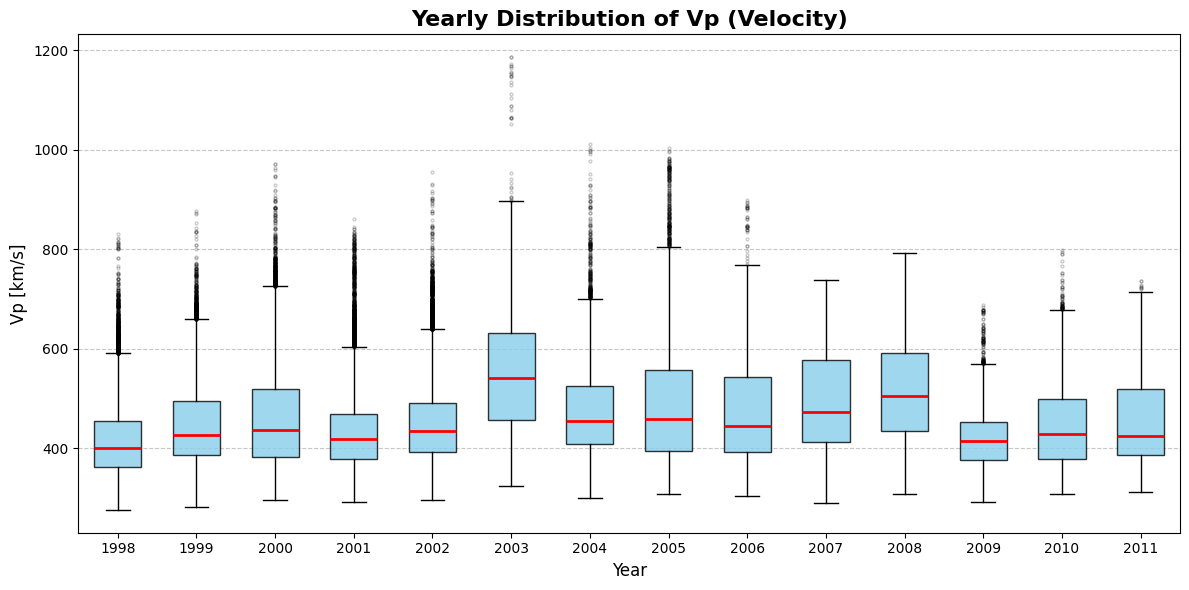

In [26]:
# vp box plot
vp = inp_flat[:, 0]

data_by_year = []
for y in unique_years:
    mask = (years_array == y) & ~np.isnan(vp)
    data_by_year.append(vp[mask])

plt.figure(figsize=(12, 6))
plt.boxplot(data_by_year, positions=unique_years, widths=0.6, patch_artist=True,
            boxprops=dict(facecolor='#87CEEB', color='#000000', alpha=0.8),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markersize=2, alpha=0.2, color='#000000'))

plt.title('Yearly Distribution of Vp (Velocity)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Vp [km/s]', fontsize=12)
plt.xticks(unique_years)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

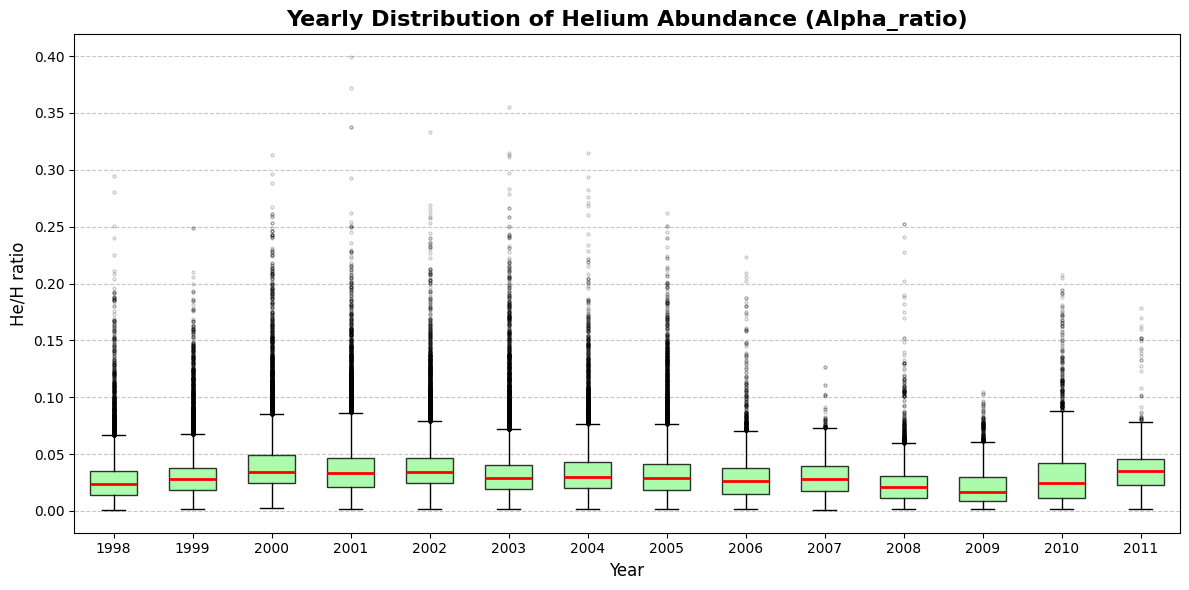

In [27]:
# alpha_ratio box plot
alpha_ratio = inp_flat[:, 1]

data_by_year = []
for y in unique_years:
    mask = (years_array == y) & ~np.isnan(alpha_ratio)
    data_by_year.append(alpha_ratio[mask])

plt.figure(figsize=(12, 6))
plt.boxplot(data_by_year, positions=unique_years, widths=0.6, patch_artist=True,
            boxprops=dict(facecolor='#98FB98', color='#000000', alpha=0.8),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markersize=2, alpha=0.2, color='#000000'))

plt.title('Yearly Distribution of Helium Abundance (Alpha_ratio)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('He/H ratio', fontsize=12)
plt.xticks(unique_years)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

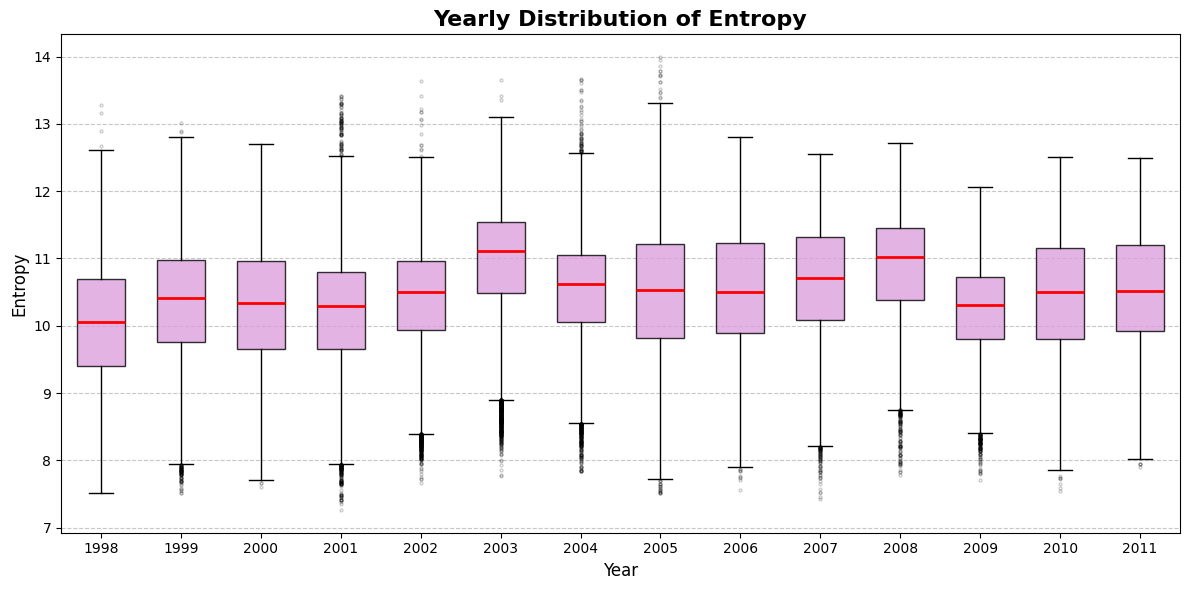

In [28]:
# entropy box plot
entropy = inp_flat[:, 2]

data_by_year = []
for y in unique_years:
    mask = (years_array == y) & ~np.isnan(entropy)
    data_by_year.append(entropy[mask])

plt.figure(figsize=(12, 6))
plt.boxplot(data_by_year, positions=unique_years, widths=0.6, patch_artist=True,
            boxprops=dict(facecolor='#DDA0DD', color='#000000', alpha=0.8),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markersize=2, alpha=0.2, color='#000000'))

plt.title('Yearly Distribution of Entropy', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Entropy', fontsize=12)
plt.xticks(unique_years)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

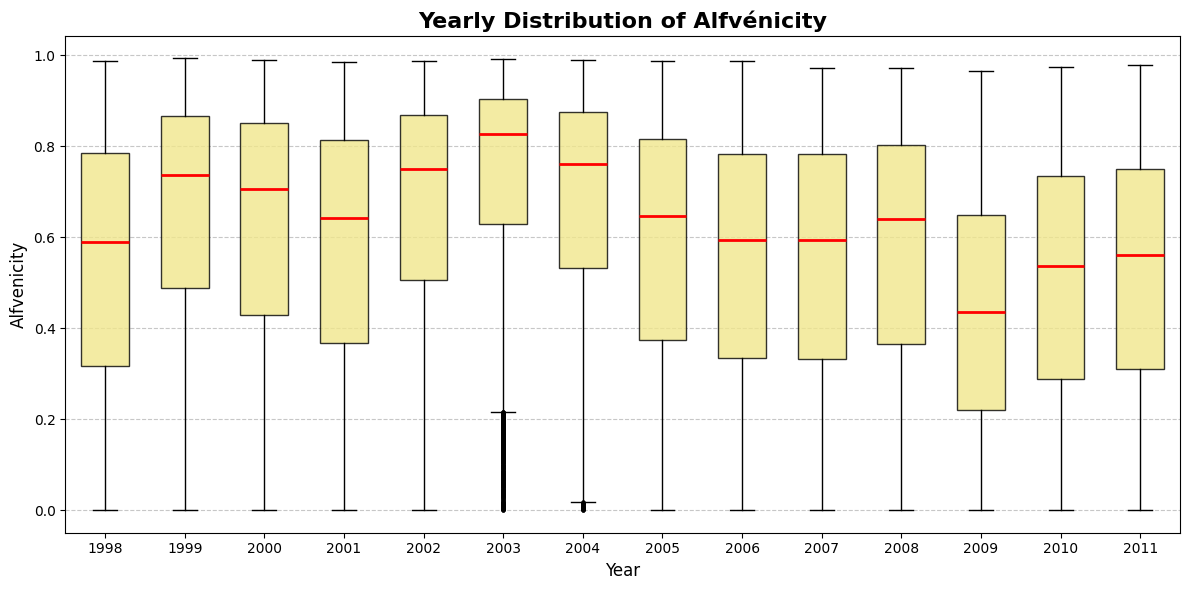

In [29]:
# alfvenicity box plot
alfvenicity = inp_flat[:, 3]

data_by_year = []
for y in unique_years:
    mask = (years_array == y) & ~np.isnan(alfvenicity)
    data_by_year.append(alfvenicity[mask])

plt.figure(figsize=(12, 6))
plt.boxplot(data_by_year, positions=unique_years, widths=0.6, patch_artist=True,
            boxprops=dict(facecolor='#F0E68C', color='#000000', alpha=0.8),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markersize=2, alpha=0.2, color='#000000'))

plt.title('Yearly Distribution of Alfvénicity', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Alfvenicity', fontsize=12)
plt.xticks(unique_years)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

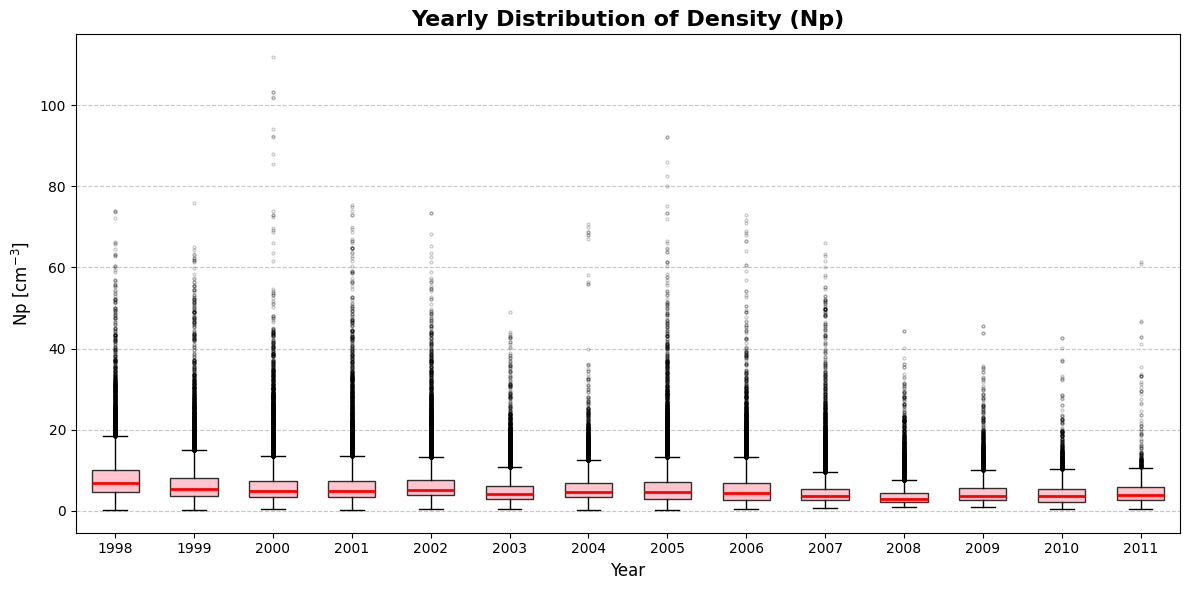

In [30]:
# np box plot
np_dens = inp_flat[:, 4]

data_by_year = []
for y in unique_years:
    mask = (years_array == y) & ~np.isnan(np_dens)
    data_by_year.append(np_dens[mask])

plt.figure(figsize=(12, 6))
plt.boxplot(data_by_year, positions=unique_years, widths=0.6, patch_artist=True,
            boxprops=dict(facecolor='#FFB6C1', color='#000000', alpha=0.8),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markersize=2, alpha=0.2, color='#000000'))

plt.title('Yearly Distribution of Density (Np)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Np [cm$^{-3}$]', fontsize=12)
plt.xticks(unique_years)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

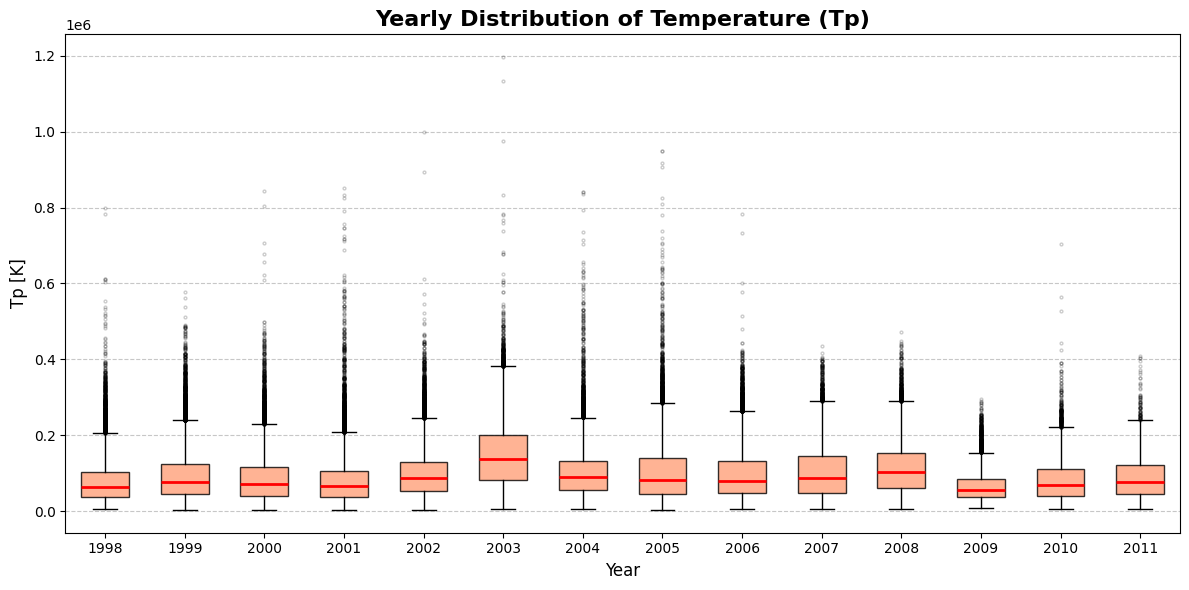

In [31]:
# tp box plot
tp = inp_flat[:, 5]

data_by_year = []
for y in unique_years:
    mask = (years_array == y) & ~np.isnan(tp)
    data_by_year.append(tp[mask])

plt.figure(figsize=(12, 6))
plt.boxplot(data_by_year, positions=unique_years, widths=0.6, patch_artist=True,
            boxprops=dict(facecolor='#FFA07A', color='#000000', alpha=0.8),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markersize=2, alpha=0.2, color='#000000'))

plt.title('Yearly Distribution of Temperature (Tp)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Tp [K]', fontsize=12)
plt.xticks(unique_years)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

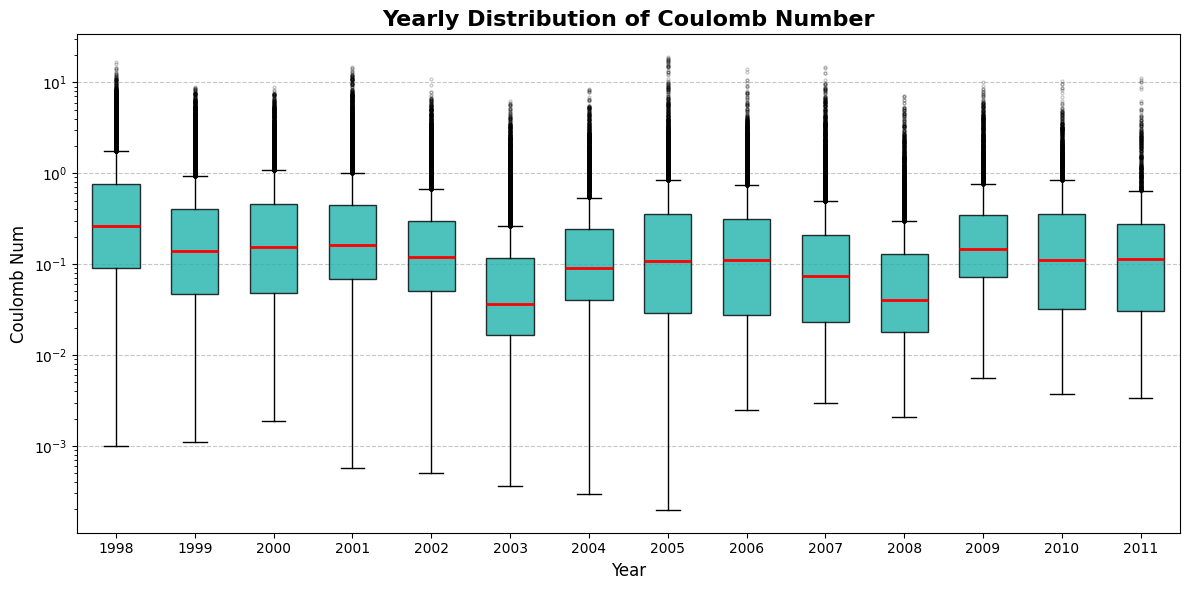

In [32]:
# coulomb box plot
coulomb = inp_flat[:, 6]

data_by_year = []
for y in unique_years:
    # 로그 스케일 적용을 위해 0 이하인 값도 제외
    mask = (years_array == y) & ~np.isnan(coulomb) & (coulomb > 0)
    data_by_year.append(coulomb[mask])

plt.figure(figsize=(12, 6))
plt.boxplot(data_by_year, positions=unique_years, widths=0.6, patch_artist=True,
            boxprops=dict(facecolor='#20B2AA', color='#000000', alpha=0.8),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markersize=2, alpha=0.2, color='#000000'))

plt.title('Yearly Distribution of Coulomb Number', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Coulomb Num', fontsize=12)
plt.xticks(unique_years)
plt.yscale('log') # 세로축 로그 스케일 적용
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

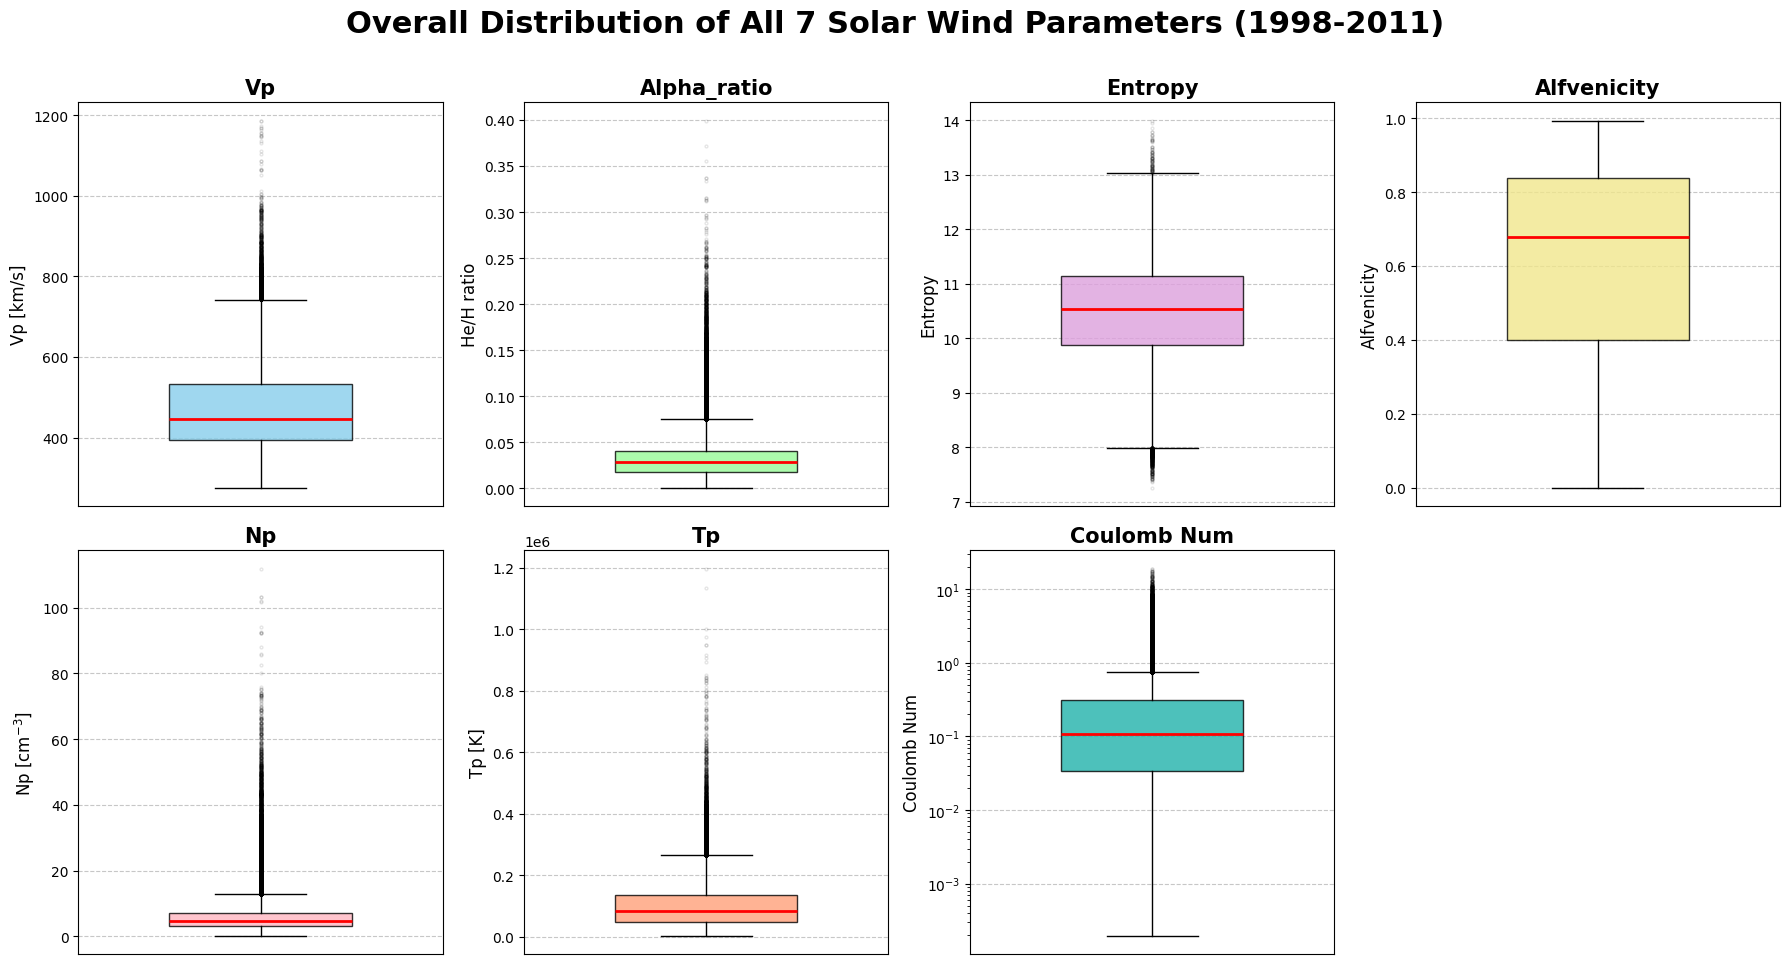

In [33]:
# 데이터 평탄화
inp_flat = inp.reshape(-1, 7)

# 변수 설정
var_names = ['Vp', 'Alpha_ratio', 'Entropy', 'Alfvenicity', 'Np', 'Tp', 'Coulomb Num']
units = ['Vp [km/s]', 'He/H ratio', 'Entropy', 'Alfvenicity', 'Np [cm$^{-3}$]', 'Tp [K]', 'Coulomb Num']
colors = ['#87CEEB', '#98FB98', '#DDA0DD', '#F0E68C', '#FFB6C1', '#FFA07A', '#20B2AA']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i in range(7):
    data = inp_flat[:, i]

    # 결측치 제외 (Coulomb Num은 로그 스케일을 위해 0 이하 추가 제외)
    if i == 6:
        valid_data = data[~np.isnan(data) & (data > 0)]
    else:
        valid_data = data[~np.isnan(data)]

    axes[i].boxplot(valid_data, widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor=colors[i], color='#000000', alpha=0.8),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.1, color='#000000'))

    axes[i].set_title(var_names[i], fontsize=15, fontweight='bold')
    axes[i].set_ylabel(units[i], fontsize=12)
    axes[i].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    # Coulomb Num(인덱스 6) 세로축 로그 스케일 적용
    if i == 6:
        axes[i].set_yscale('log')

# 남는 8번째 빈 공간(axes[7]) 숨기기
axes[7].axis('off')

plt.suptitle('Overall Distribution of All 7 Solar Wind Parameters (1998-2011)', fontsize=22, fontweight='bold', y=0.96)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### contour plot

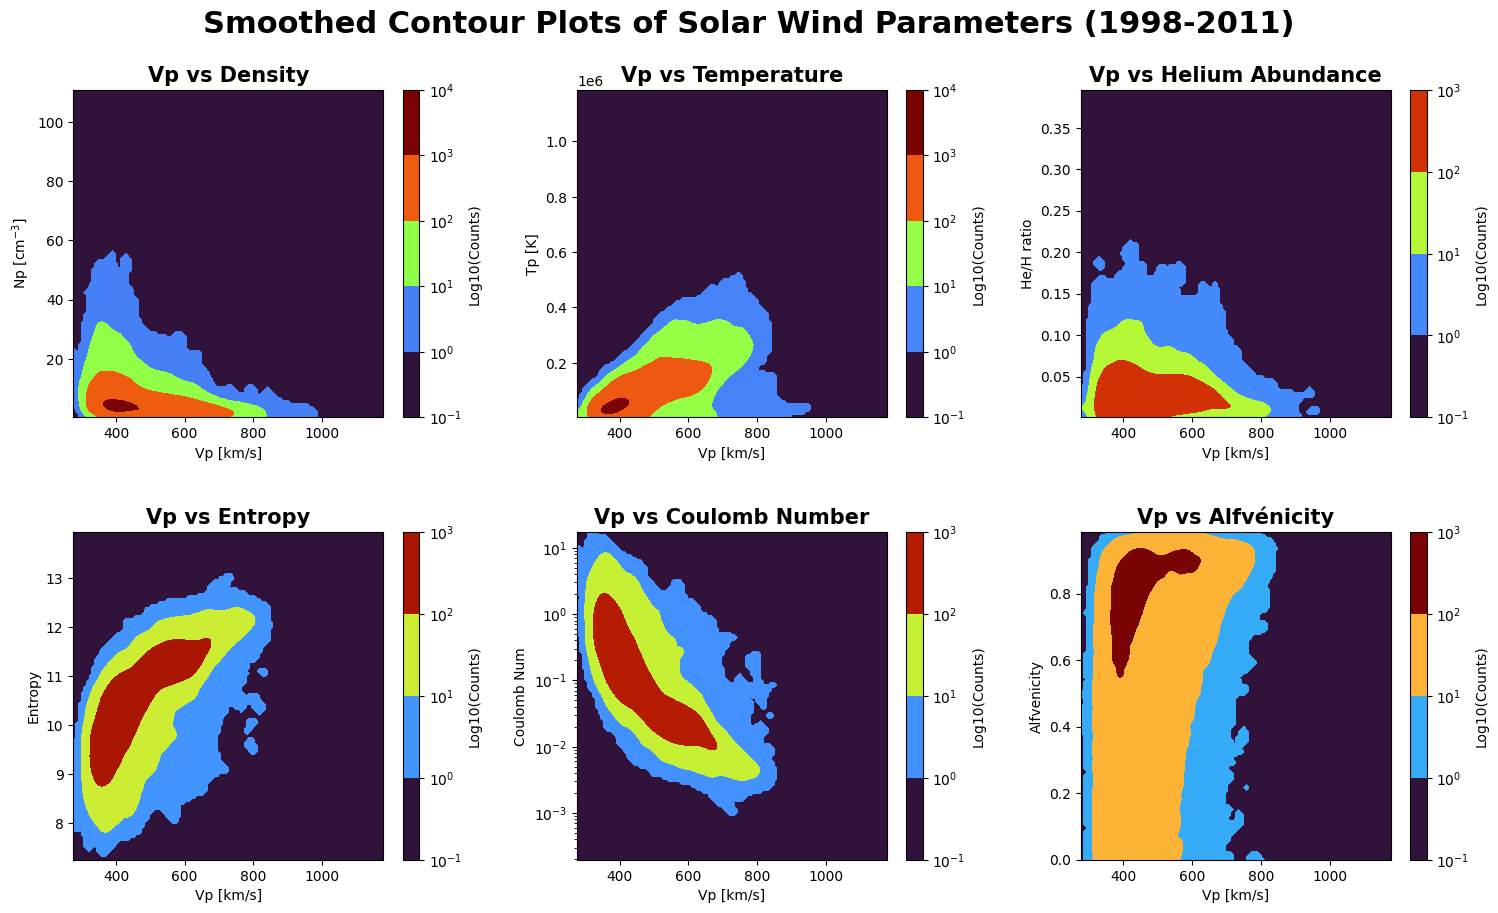

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

# 데이터 평탄화
inp_flat = inp.reshape(-1, 7)

vp = inp_flat[:, 0]          # 0: Vp
alpha_ratio = inp_flat[:, 1] # 1: Alpha_ratio
entropy = inp_flat[:, 2]     # 2: Entropy
alfvenicity = inp_flat[:, 3] # 3: Alfvenicity
np_dens = inp_flat[:, 4]     # 4: Np
tp = inp_flat[:, 5]          # 5: Tp
coulomb = inp_flat[:, 6]     # 6: coulomb num

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(hspace=0.35, wspace=0.3)
axes = axes.flatten()

relations = [
    (vp, np_dens, 'Vp vs Density', 'Vp [km/s]', 'Np [cm$^{-3}$]'),
    (vp, tp, 'Vp vs Temperature', 'Vp [km/s]', 'Tp [K]'),
    (vp, alpha_ratio, 'Vp vs Helium Abundance', 'Vp [km/s]', 'He/H ratio'),
    (vp, entropy, 'Vp vs Entropy', 'Vp [km/s]', 'Entropy'),
    (vp, coulomb, 'Vp vs Coulomb Number', 'Vp [km/s]', 'Coulomb Num'),
    (vp, alfvenicity, 'Vp vs Alfvénicity', 'Vp [km/s]', 'Alfvenicity')
]

for i, (x, y, title, xlabel, ylabel) in enumerate(relations):
    # 결측치 제외
    valid_mask = ~np.isnan(x) & ~np.isnan(y)
    x_valid = x[valid_mask]
    y_valid = y[valid_mask]

    if title == 'Vp vs Coulomb Number':
        # 로그 스케일 처리를 위해 0 이하 값 제외
        positive_mask = y_valid > 0
        x_valid = x_valid[positive_mask]
        y_valid = y_valid[positive_mask]

        x_bins = np.linspace(x_valid.min(), x_valid.max(), 120)
        y_bins = np.logspace(np.log10(y_valid.min()), np.log10(y_valid.max()), 120)
        axes[i].set_yscale('log')
    else:
        x_bins = np.linspace(x_valid.min(), x_valid.max(), 120)
        y_bins = np.linspace(y_valid.min(), y_valid.max(), 120)

    # 1. 2D 히스토그램으로 밀집도를 계산한다.
    H, xedges, yedges = np.histogram2d(x_valid, y_valid, bins=[x_bins, y_bins])
    H = H.T  # x, y 축 방향 맞추기

    # 2. 가우시안 필터로 데이터 스무딩 (부드러운 등고선을 위해
    H_smooth = gaussian_filter(H, sigma=1.5)
    H_smooth[H_smooth < 1] = 1 # 빈 공간은 기본값 1로 두어 LogNorm 에러를 방지한다.

    # 3. 격자 생성
    X, Y = np.meshgrid(xedges[:-1], yedges[:-1])

    # 4. Contourf (채색된 등고선) 그리기
    contour = axes[i].contourf(
        X, Y, H_smooth,
        levels=35,           # 등고선 층 수 (높을수록 그라데이션이 부드러워짐)
        cmap='turbo',        # 시각적 구분이 뚜렷한 컬러맵
        norm=mcolors.LogNorm(vmin=1, vmax=H_smooth.max())
    )

    axes[i].set_title(title, fontsize=15, fontweight='bold')
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel(ylabel)
    fig.colorbar(contour, ax=axes[i], label='Log10(Counts)')

plt.suptitle('Smoothed Contour Plots of Solar Wind Parameters (1998-2011)', fontsize=22, fontweight='bold', y=0.96)
plt.show()

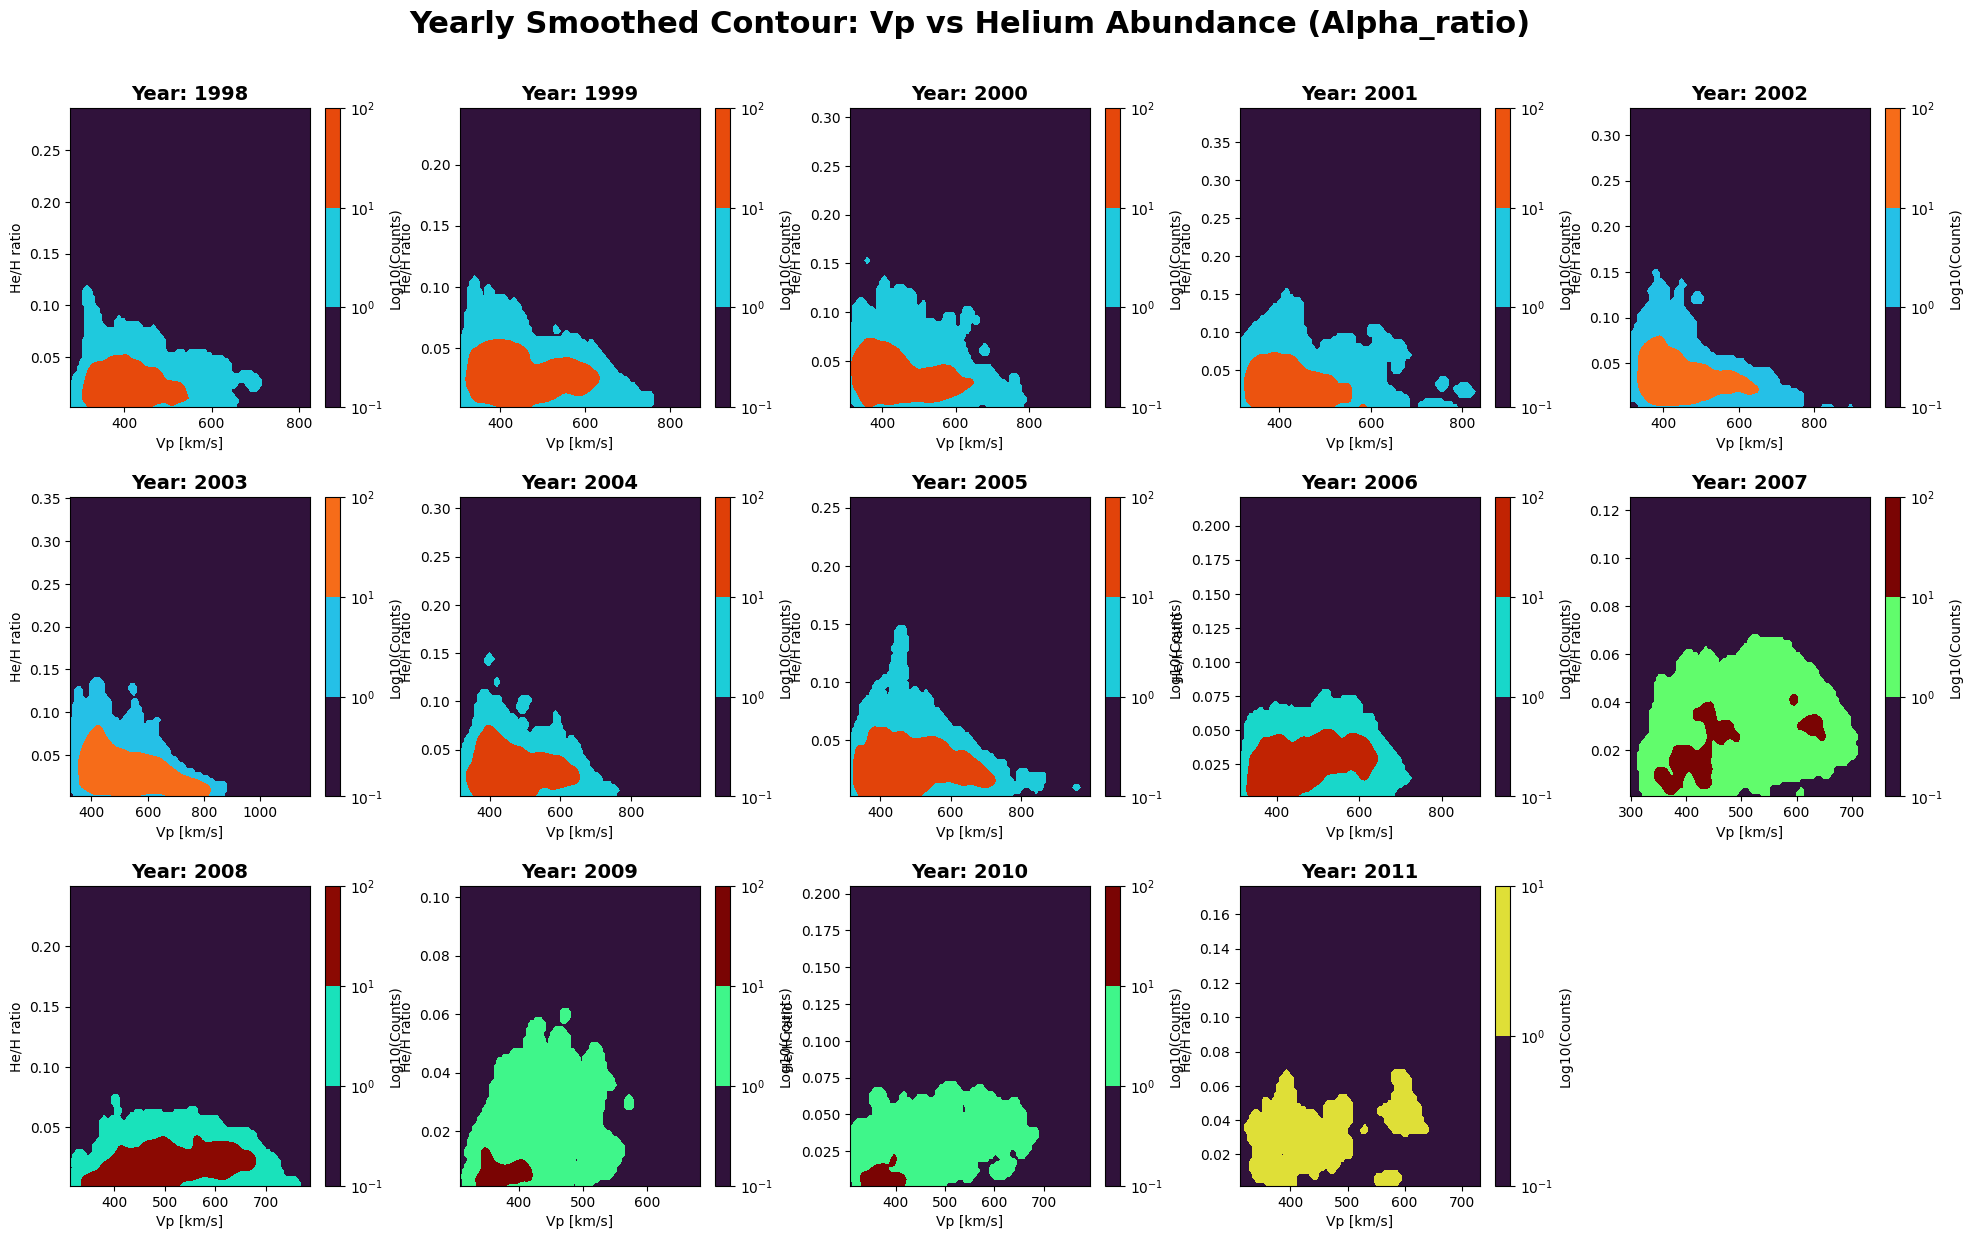

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

vp = inp_flat[:, 0]
target_var = inp_flat[:, 1] # 1: Alpha_ratio

fig, axes = plt.subplots(3, 5, figsize=(24, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()

for i, y_val in enumerate(unique_years):
    mask = (years_array == y_val) & ~np.isnan(vp) & ~np.isnan(target_var)
    x_year = vp[mask]
    y_year = target_var[mask]

    if len(x_year) > 0:
        x_bins = np.linspace(x_year.min(), x_year.max(), 100)
        y_bins = np.linspace(y_year.min(), y_year.max(), 100)

        H, xedges, yedges = np.histogram2d(x_year, y_year, bins=[x_bins, y_bins])
        H = H.T
        H_smooth = gaussian_filter(H, sigma=1.5)
        H_smooth[H_smooth < 1] = 1

        X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
        contour = axes[i].contourf(X, Y, H_smooth, levels=35, cmap='turbo',
                                   norm=mcolors.LogNorm(vmin=1, vmax=H_smooth.max()))

        axes[i].set_title(f'Year: {y_val}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Vp [km/s]')
        axes[i].set_ylabel('He/H ratio')
        fig.colorbar(contour, ax=axes[i], label='Log10(Counts)')

for j in range(len(unique_years), len(axes)):
    axes[j].axis('off')

plt.suptitle('Yearly Smoothed Contour: Vp vs Helium Abundance (Alpha_ratio)', fontsize=22, fontweight='bold', y=0.95)
plt.show()

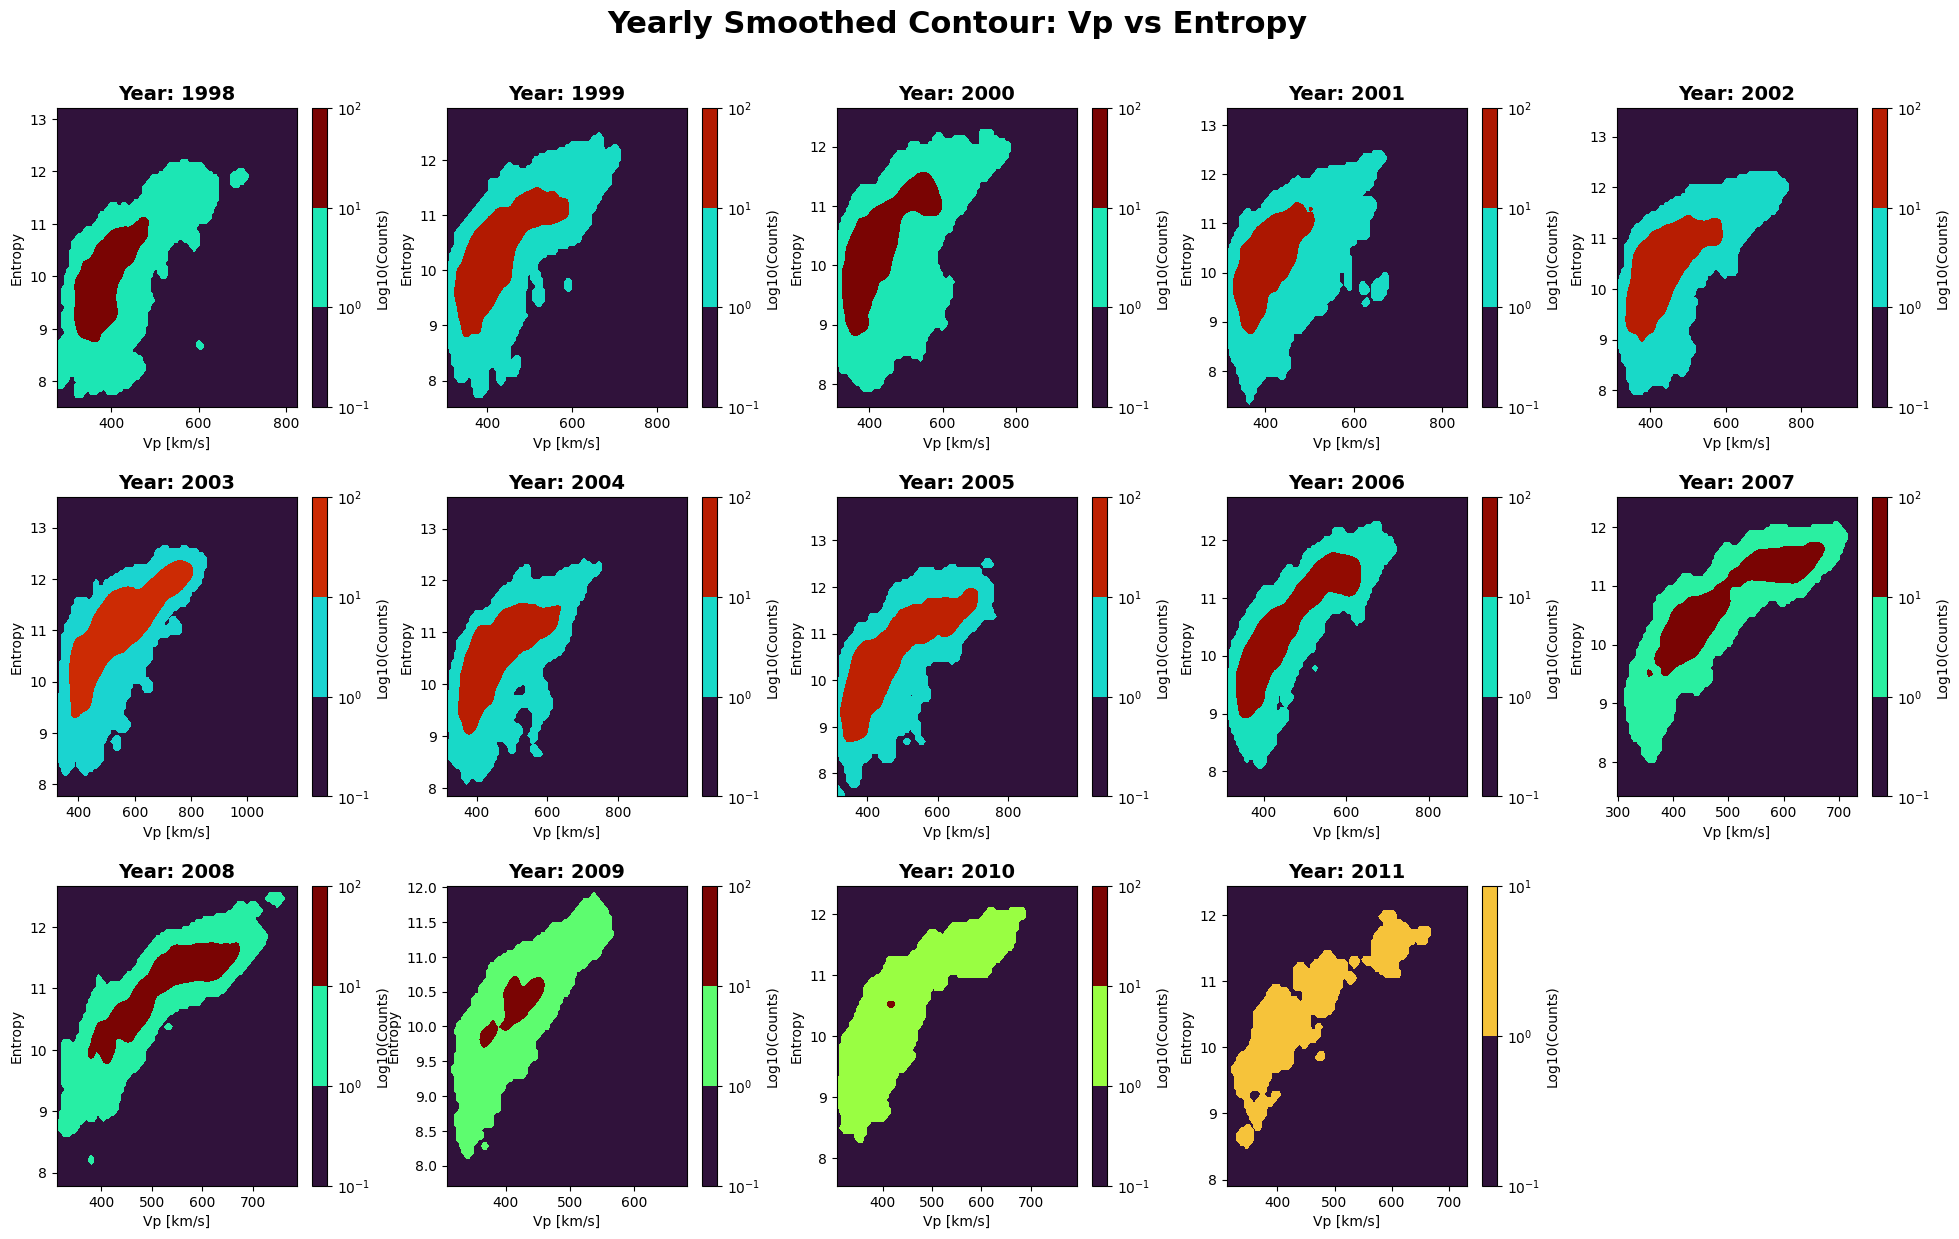

In [36]:
vp = inp_flat[:, 0]
target_var = inp_flat[:, 2] # 2: Entropy

fig, axes = plt.subplots(3, 5, figsize=(24, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()

for i, y_val in enumerate(unique_years):
    mask = (years_array == y_val) & ~np.isnan(vp) & ~np.isnan(target_var)
    x_year = vp[mask]
    y_year = target_var[mask]

    if len(x_year) > 0:
        x_bins = np.linspace(x_year.min(), x_year.max(), 100)
        y_bins = np.linspace(y_year.min(), y_year.max(), 100)

        H, xedges, yedges = np.histogram2d(x_year, y_year, bins=[x_bins, y_bins])
        H = H.T
        H_smooth = gaussian_filter(H, sigma=1.5)
        H_smooth[H_smooth < 1] = 1

        X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
        contour = axes[i].contourf(X, Y, H_smooth, levels=35, cmap='turbo',
                                   norm=mcolors.LogNorm(vmin=1, vmax=H_smooth.max()))

        axes[i].set_title(f'Year: {y_val}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Vp [km/s]')
        axes[i].set_ylabel('Entropy')
        fig.colorbar(contour, ax=axes[i], label='Log10(Counts)')

for j in range(len(unique_years), len(axes)):
    axes[j].axis('off')

plt.suptitle('Yearly Smoothed Contour: Vp vs Entropy', fontsize=22, fontweight='bold', y=0.95)
plt.show()

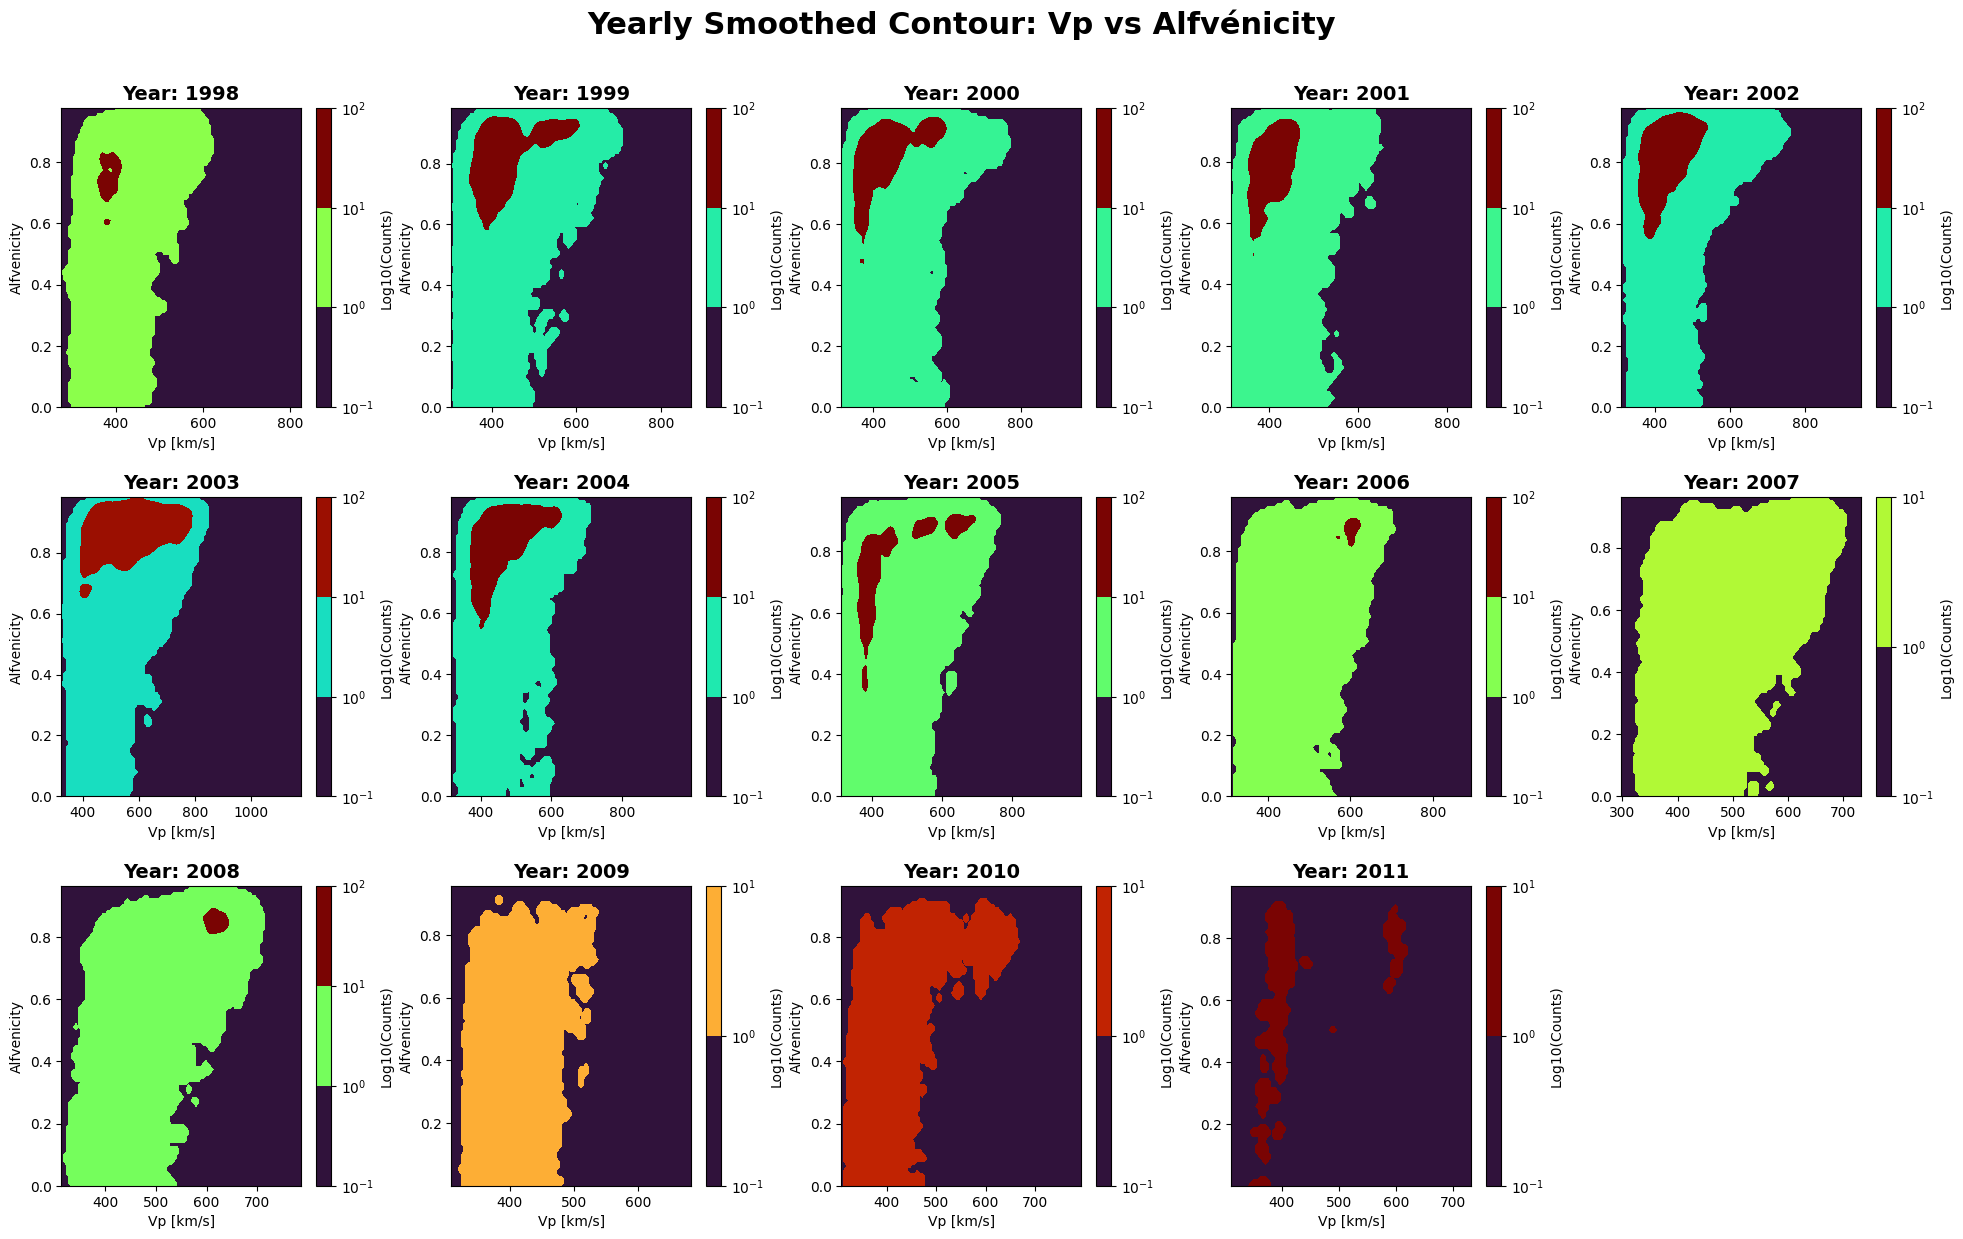

In [37]:
vp = inp_flat[:, 0]
target_var = inp_flat[:, 3] # 3: Alfvenicity

fig, axes = plt.subplots(3, 5, figsize=(24, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()

for i, y_val in enumerate(unique_years):
    mask = (years_array == y_val) & ~np.isnan(vp) & ~np.isnan(target_var)
    x_year = vp[mask]
    y_year = target_var[mask]

    if len(x_year) > 0:
        x_bins = np.linspace(x_year.min(), x_year.max(), 100)
        y_bins = np.linspace(y_year.min(), y_year.max(), 100)

        H, xedges, yedges = np.histogram2d(x_year, y_year, bins=[x_bins, y_bins])
        H = H.T
        H_smooth = gaussian_filter(H, sigma=1.5)
        H_smooth[H_smooth < 1] = 1

        X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
        contour = axes[i].contourf(X, Y, H_smooth, levels=35, cmap='turbo',
                                   norm=mcolors.LogNorm(vmin=1, vmax=H_smooth.max()))

        axes[i].set_title(f'Year: {y_val}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Vp [km/s]')
        axes[i].set_ylabel('Alfvenicity')
        fig.colorbar(contour, ax=axes[i], label='Log10(Counts)')

for j in range(len(unique_years), len(axes)):
    axes[j].axis('off')

plt.suptitle('Yearly Smoothed Contour: Vp vs Alfvénicity', fontsize=22, fontweight='bold', y=0.95)
plt.show()

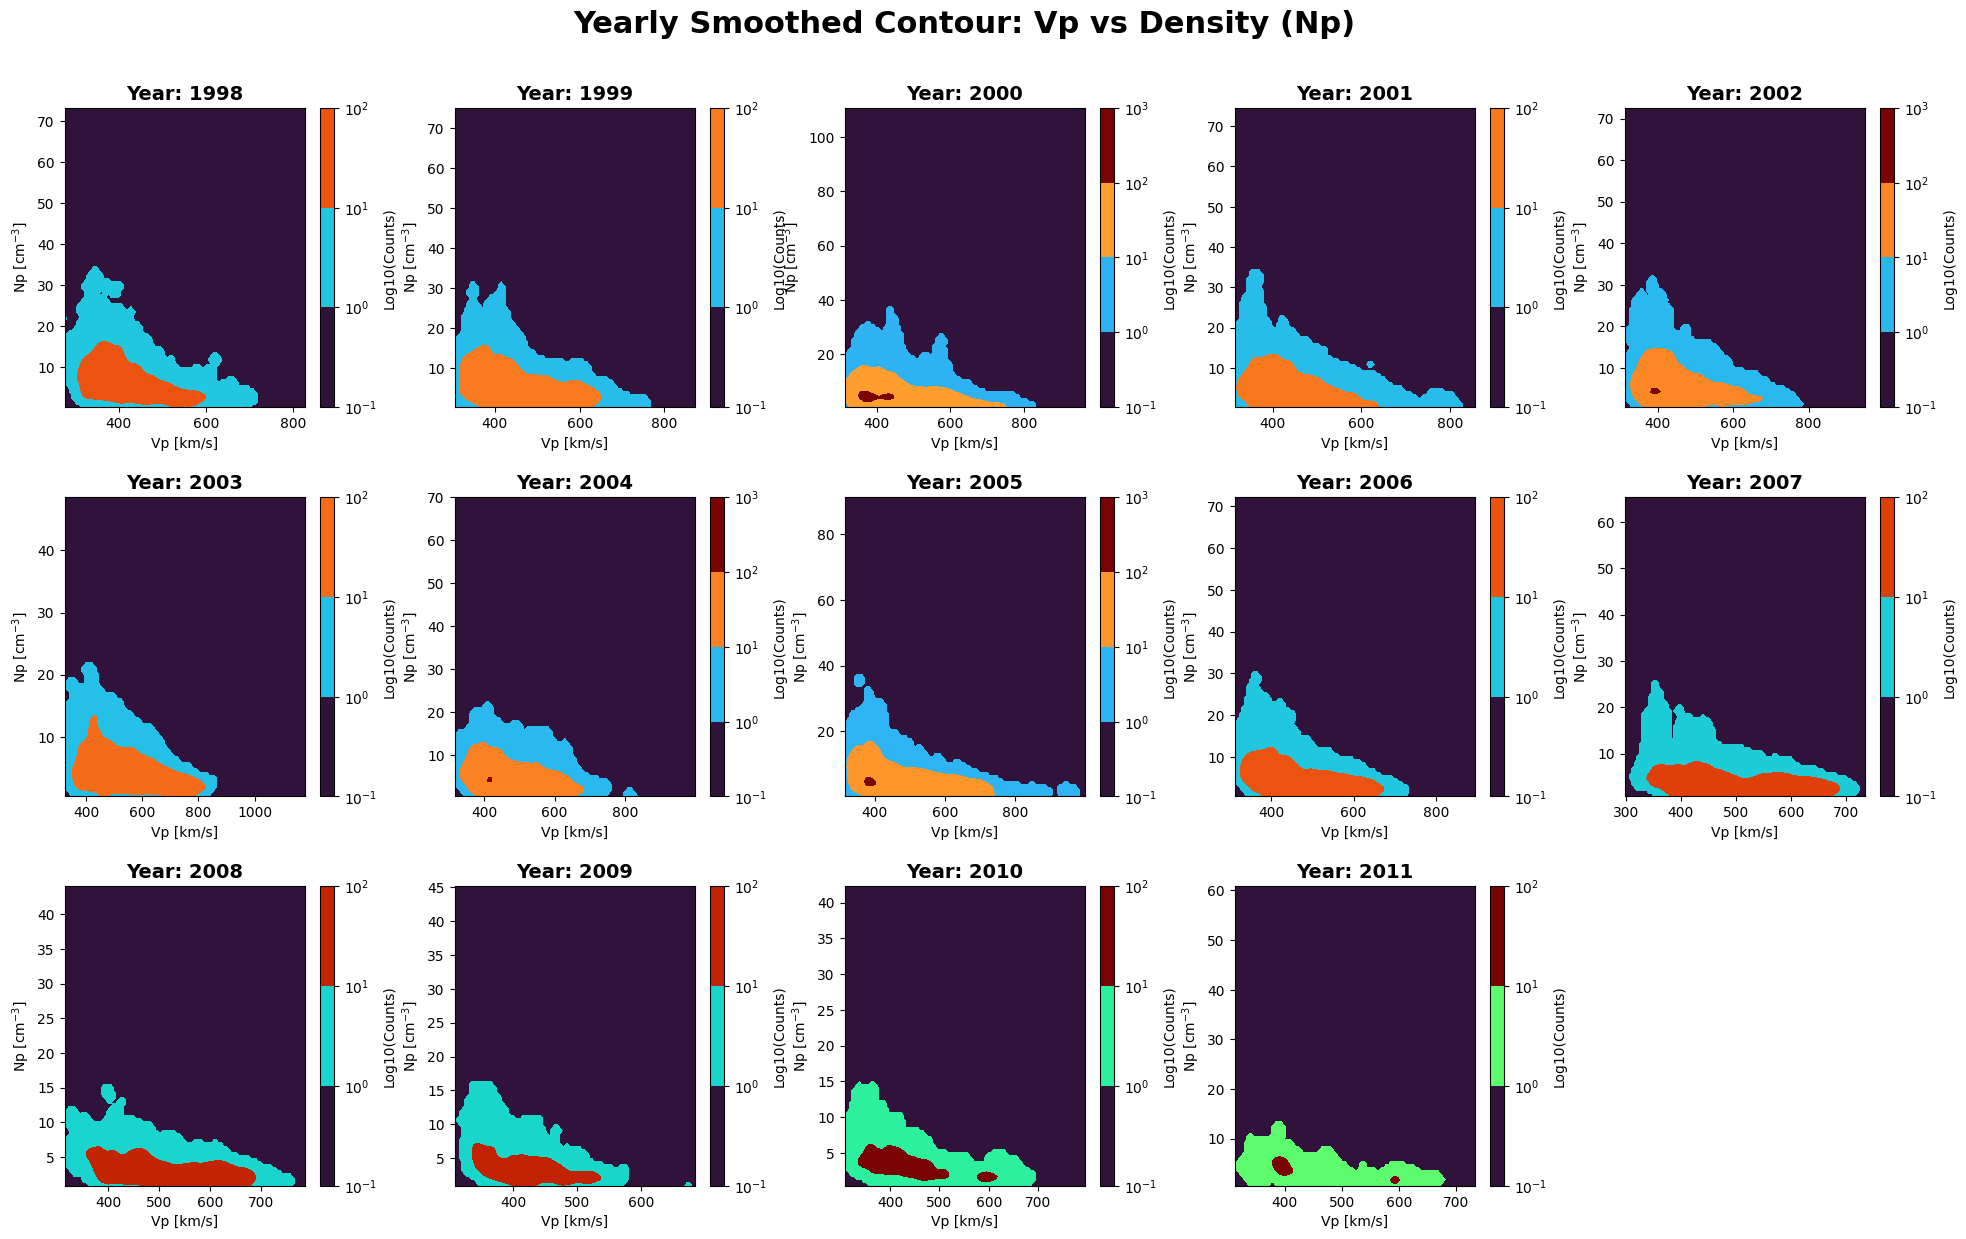

In [38]:
vp = inp_flat[:, 0]
target_var = inp_flat[:, 4] # 4: Np

fig, axes = plt.subplots(3, 5, figsize=(24, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()

for i, y_val in enumerate(unique_years):
    mask = (years_array == y_val) & ~np.isnan(vp) & ~np.isnan(target_var)
    x_year = vp[mask]
    y_year = target_var[mask]

    if len(x_year) > 0:
        x_bins = np.linspace(x_year.min(), x_year.max(), 100)
        y_bins = np.linspace(y_year.min(), y_year.max(), 100)

        H, xedges, yedges = np.histogram2d(x_year, y_year, bins=[x_bins, y_bins])
        H = H.T
        H_smooth = gaussian_filter(H, sigma=1.5)
        H_smooth[H_smooth < 1] = 1

        X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
        contour = axes[i].contourf(X, Y, H_smooth, levels=35, cmap='turbo',
                                   norm=mcolors.LogNorm(vmin=1, vmax=H_smooth.max()))

        axes[i].set_title(f'Year: {y_val}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Vp [km/s]')
        axes[i].set_ylabel('Np [cm$^{-3}$]')
        fig.colorbar(contour, ax=axes[i], label='Log10(Counts)')

for j in range(len(unique_years), len(axes)):
    axes[j].axis('off')

plt.suptitle('Yearly Smoothed Contour: Vp vs Density (Np)', fontsize=22, fontweight='bold', y=0.95)
plt.show()

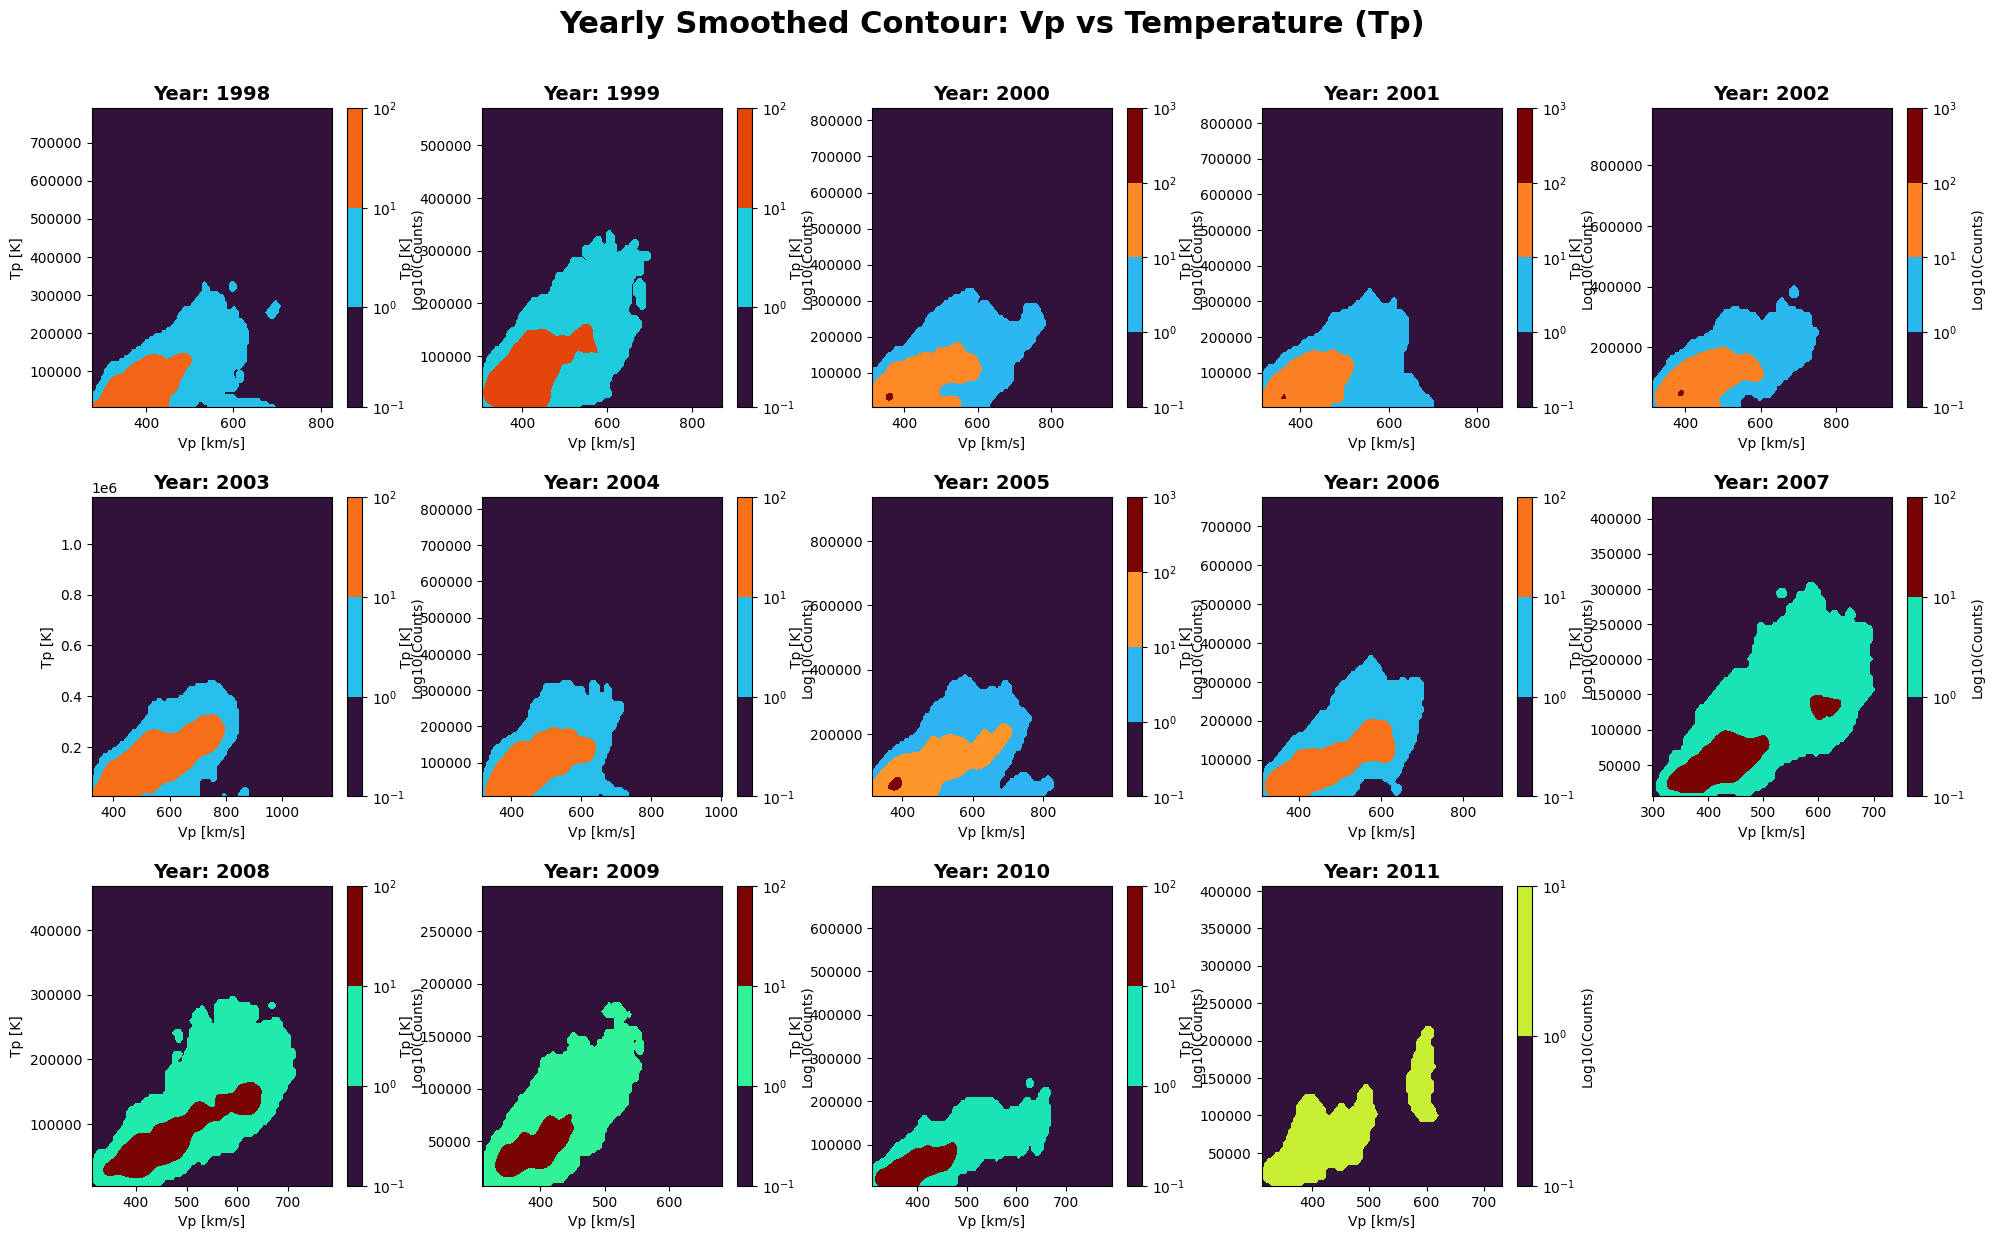

In [39]:
vp = inp_flat[:, 0]
target_var = inp_flat[:, 5] # 5: Tp

fig, axes = plt.subplots(3, 5, figsize=(24, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()

for i, y_val in enumerate(unique_years):
    mask = (years_array == y_val) & ~np.isnan(vp) & ~np.isnan(target_var)
    x_year = vp[mask]
    y_year = target_var[mask]

    if len(x_year) > 0:
        x_bins = np.linspace(x_year.min(), x_year.max(), 100)
        y_bins = np.linspace(y_year.min(), y_year.max(), 100)

        H, xedges, yedges = np.histogram2d(x_year, y_year, bins=[x_bins, y_bins])
        H = H.T
        H_smooth = gaussian_filter(H, sigma=1.5)
        H_smooth[H_smooth < 1] = 1

        X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
        contour = axes[i].contourf(X, Y, H_smooth, levels=35, cmap='turbo',
                                   norm=mcolors.LogNorm(vmin=1, vmax=H_smooth.max()))

        axes[i].set_title(f'Year: {y_val}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Vp [km/s]')
        axes[i].set_ylabel('Tp [K]')
        fig.colorbar(contour, ax=axes[i], label='Log10(Counts)')

for j in range(len(unique_years), len(axes)):
    axes[j].axis('off')

plt.suptitle('Yearly Smoothed Contour: Vp vs Temperature (Tp)', fontsize=22, fontweight='bold', y=0.95)
plt.show()

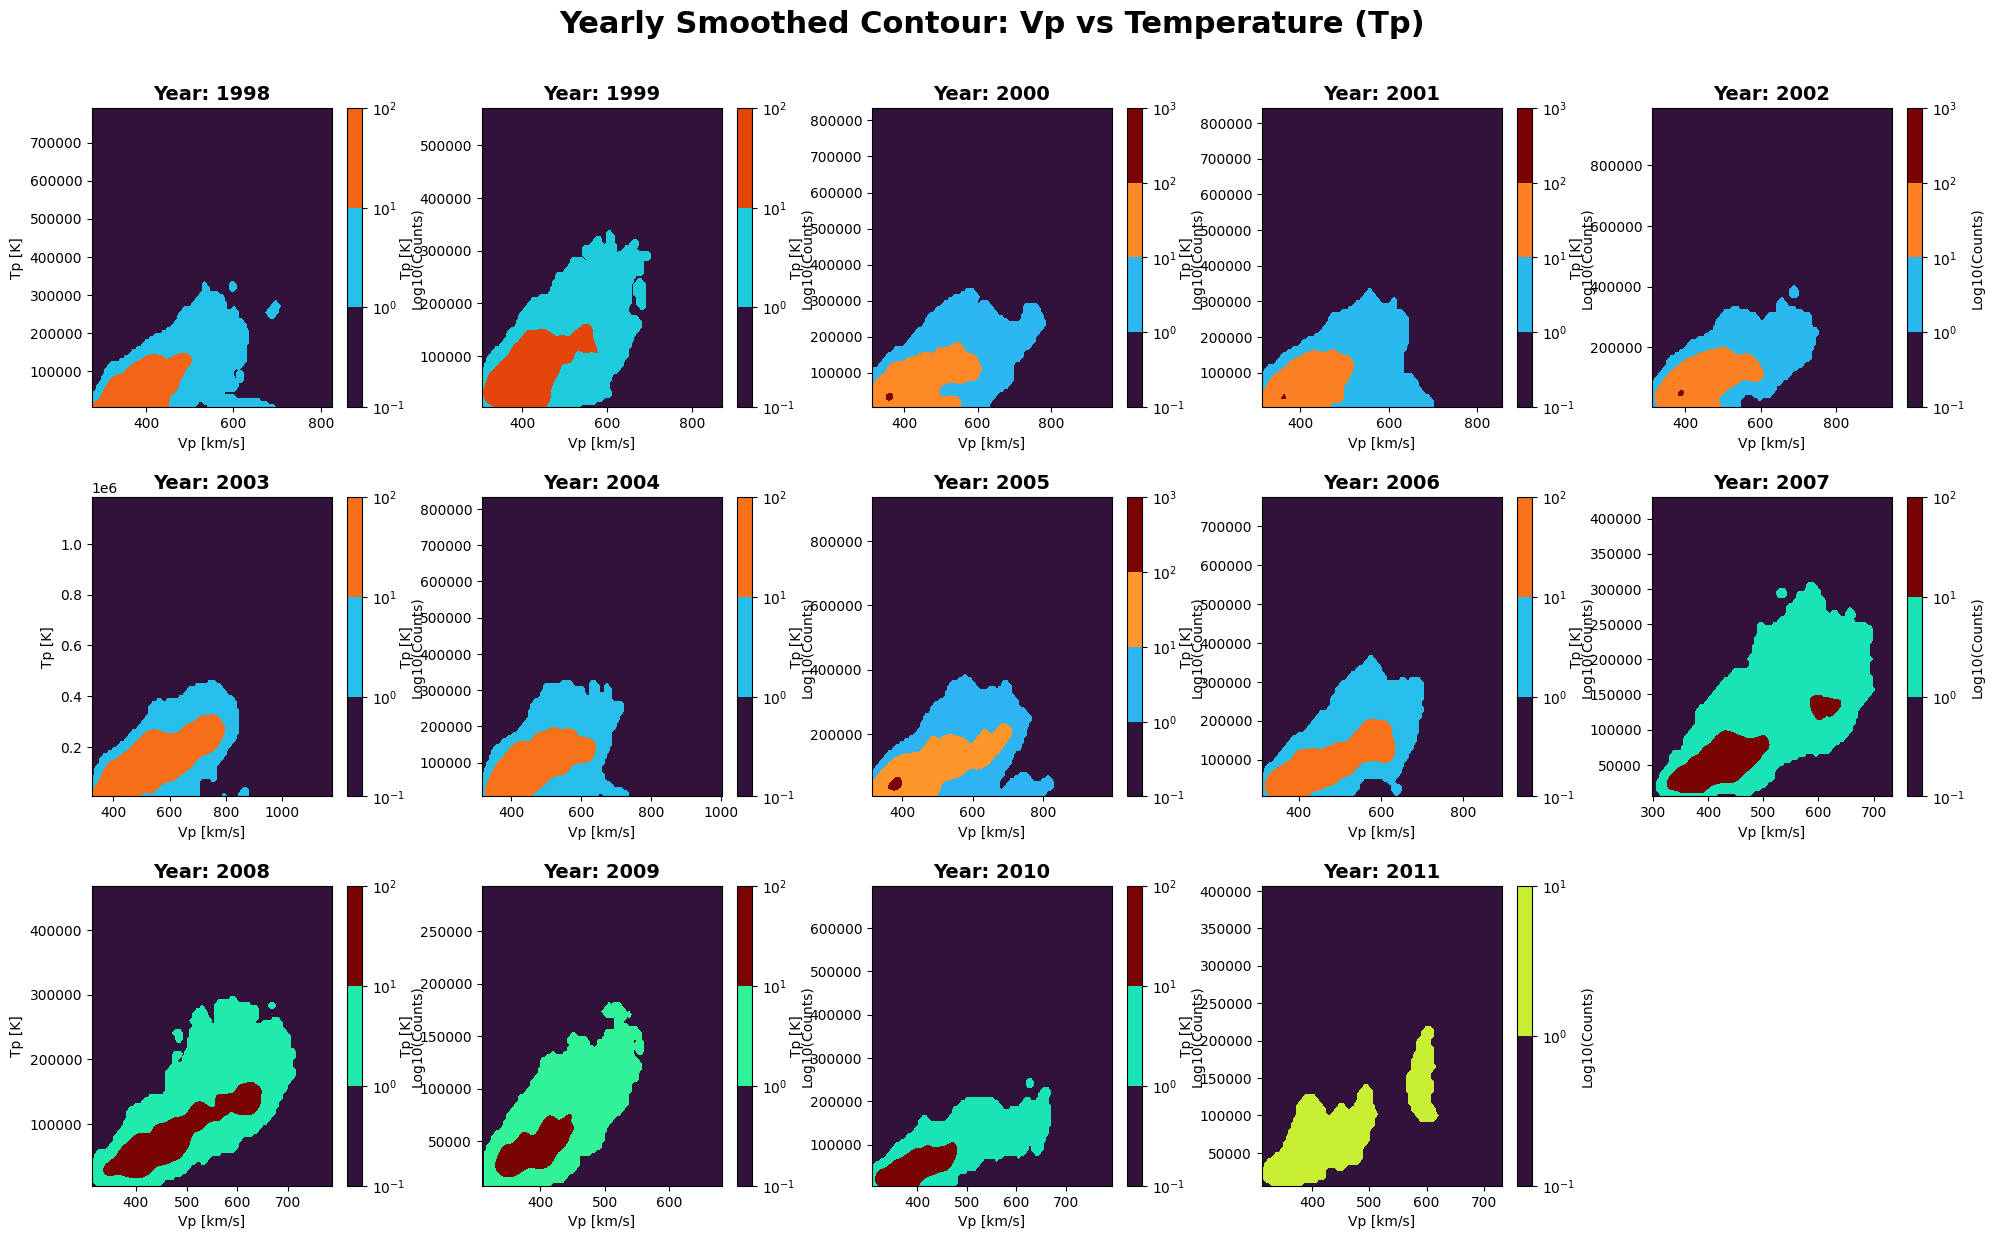

In [40]:
vp = inp_flat[:, 0]
target_var = inp_flat[:, 5] # 5: Tp

fig, axes = plt.subplots(3, 5, figsize=(24, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()

for i, y_val in enumerate(unique_years):
    mask = (years_array == y_val) & ~np.isnan(vp) & ~np.isnan(target_var)
    x_year = vp[mask]
    y_year = target_var[mask]

    if len(x_year) > 0:
        x_bins = np.linspace(x_year.min(), x_year.max(), 100)
        y_bins = np.linspace(y_year.min(), y_year.max(), 100)

        H, xedges, yedges = np.histogram2d(x_year, y_year, bins=[x_bins, y_bins])
        H = H.T
        H_smooth = gaussian_filter(H, sigma=1.5)
        H_smooth[H_smooth < 1] = 1

        X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
        contour = axes[i].contourf(X, Y, H_smooth, levels=35, cmap='turbo',
                                   norm=mcolors.LogNorm(vmin=1, vmax=H_smooth.max()))

        axes[i].set_title(f'Year: {y_val}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Vp [km/s]')
        axes[i].set_ylabel('Tp [K]')
        fig.colorbar(contour, ax=axes[i], label='Log10(Counts)')

for j in range(len(unique_years), len(axes)):
    axes[j].axis('off')

plt.suptitle('Yearly Smoothed Contour: Vp vs Temperature (Tp)', fontsize=22, fontweight='bold', y=0.95)
plt.show()

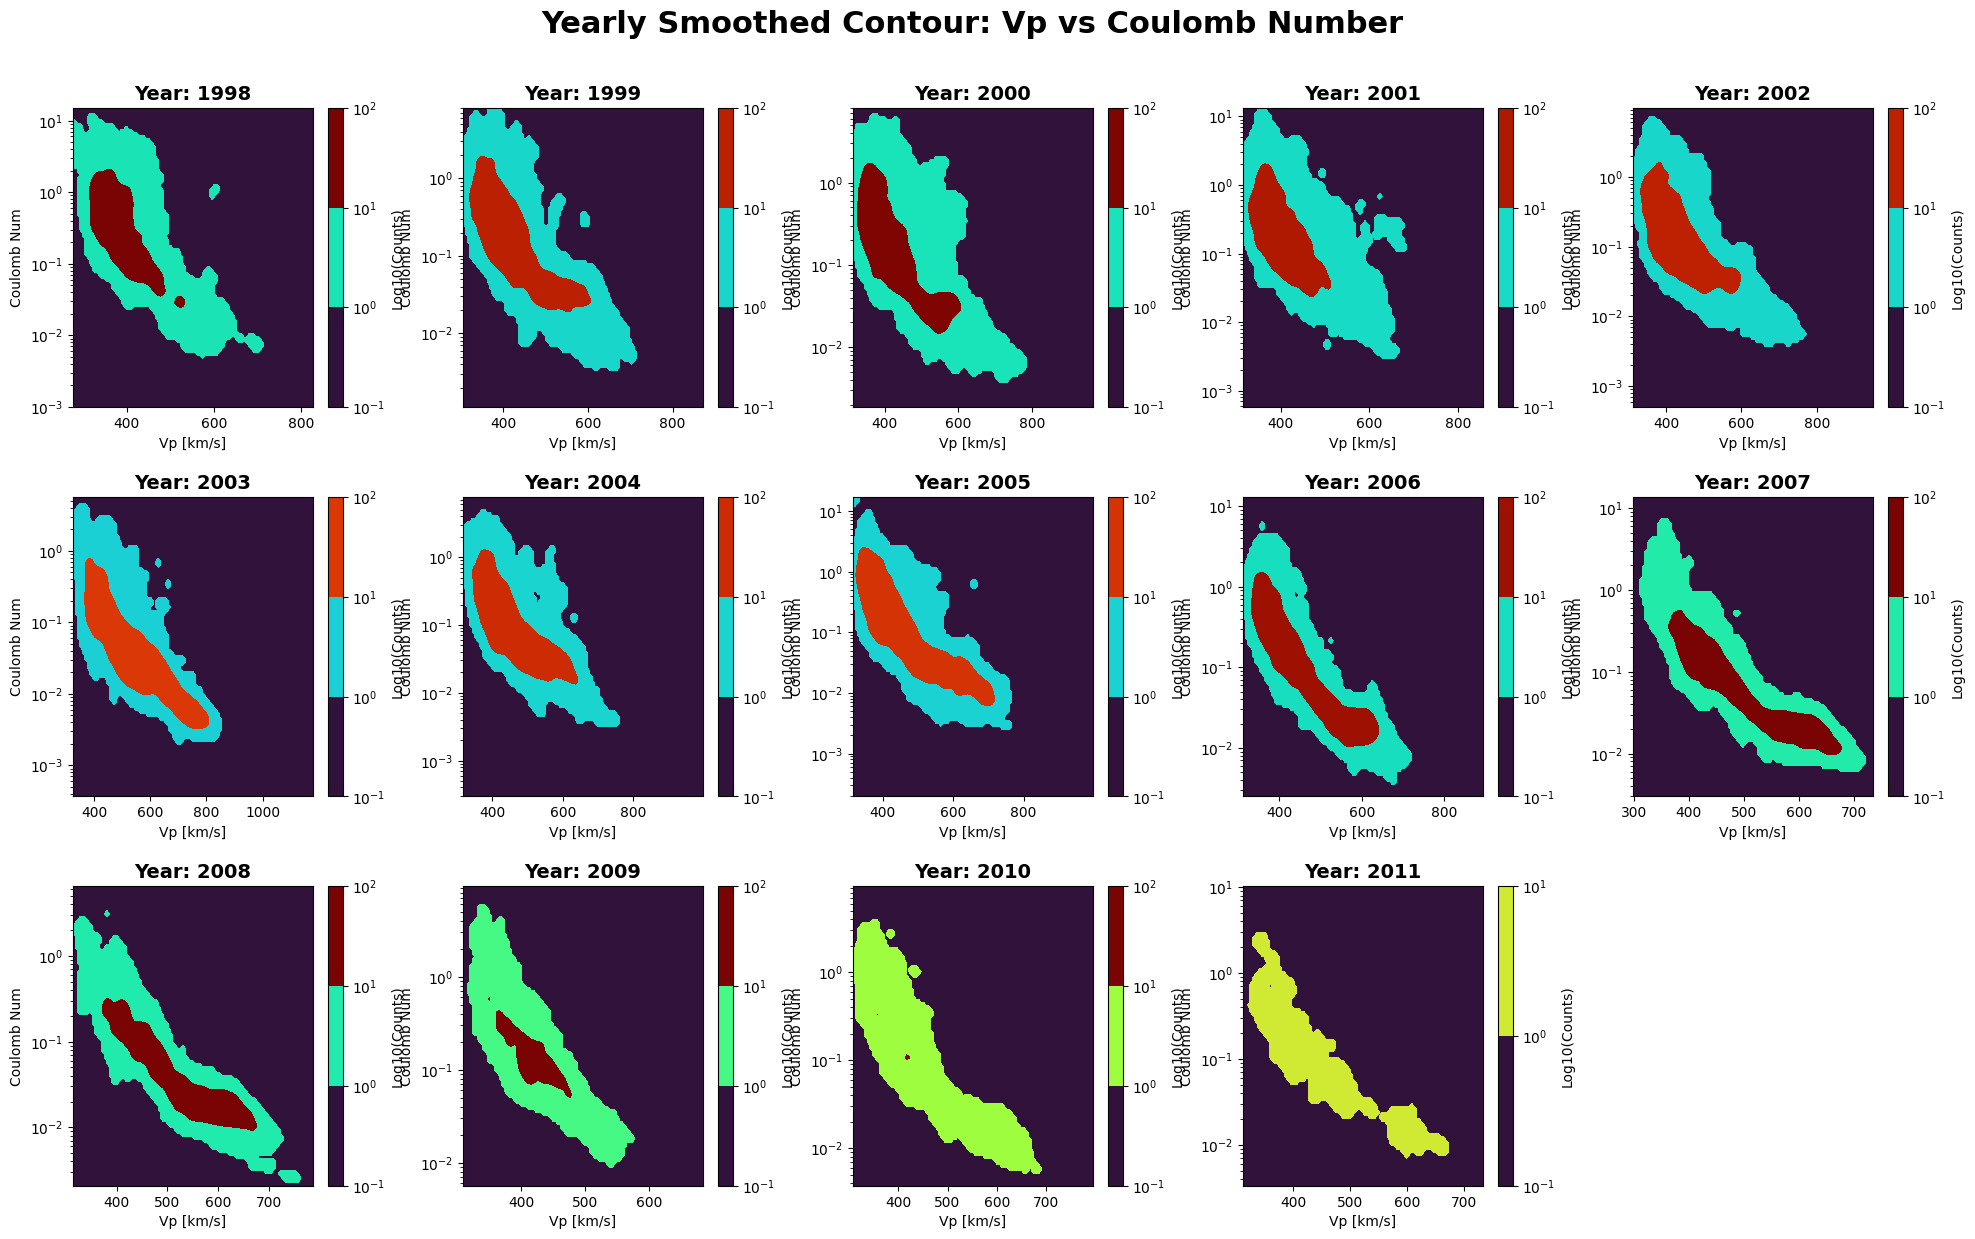

In [41]:
vp = inp_flat[:, 0]
target_var = inp_flat[:, 6] # 6: Coulomb Num

fig, axes = plt.subplots(3, 5, figsize=(24, 14))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
axes = axes.flatten()

for i, y_val in enumerate(unique_years):
    # 로그 스케일 적용을 위해 0 이하 값 제외
    mask = (years_array == y_val) & ~np.isnan(vp) & ~np.isnan(target_var) & (target_var > 0)
    x_year = vp[mask]
    y_year = target_var[mask]

    if len(x_year) > 0:
        x_bins = np.linspace(x_year.min(), x_year.max(), 100)
        y_bins = np.logspace(np.log10(y_year.min()), np.log10(y_year.max()), 100)

        H, xedges, yedges = np.histogram2d(x_year, y_year, bins=[x_bins, y_bins])
        H = H.T
        H_smooth = gaussian_filter(H, sigma=1.5)
        H_smooth[H_smooth < 1] = 1

        X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
        contour = axes[i].contourf(X, Y, H_smooth, levels=35, cmap='turbo',
                                   norm=mcolors.LogNorm(vmin=1, vmax=H_smooth.max()))

        axes[i].set_yscale('log')
        axes[i].set_title(f'Year: {y_val}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Vp [km/s]')
        axes[i].set_ylabel('Coulomb Num')
        fig.colorbar(contour, ax=axes[i], label='Log10(Counts)')

for j in range(len(unique_years), len(axes)):
    axes[j].axis('off')

plt.suptitle('Yearly Smoothed Contour: Vp vs Coulomb Number', fontsize=22, fontweight='bold', y=0.95)
plt.show()

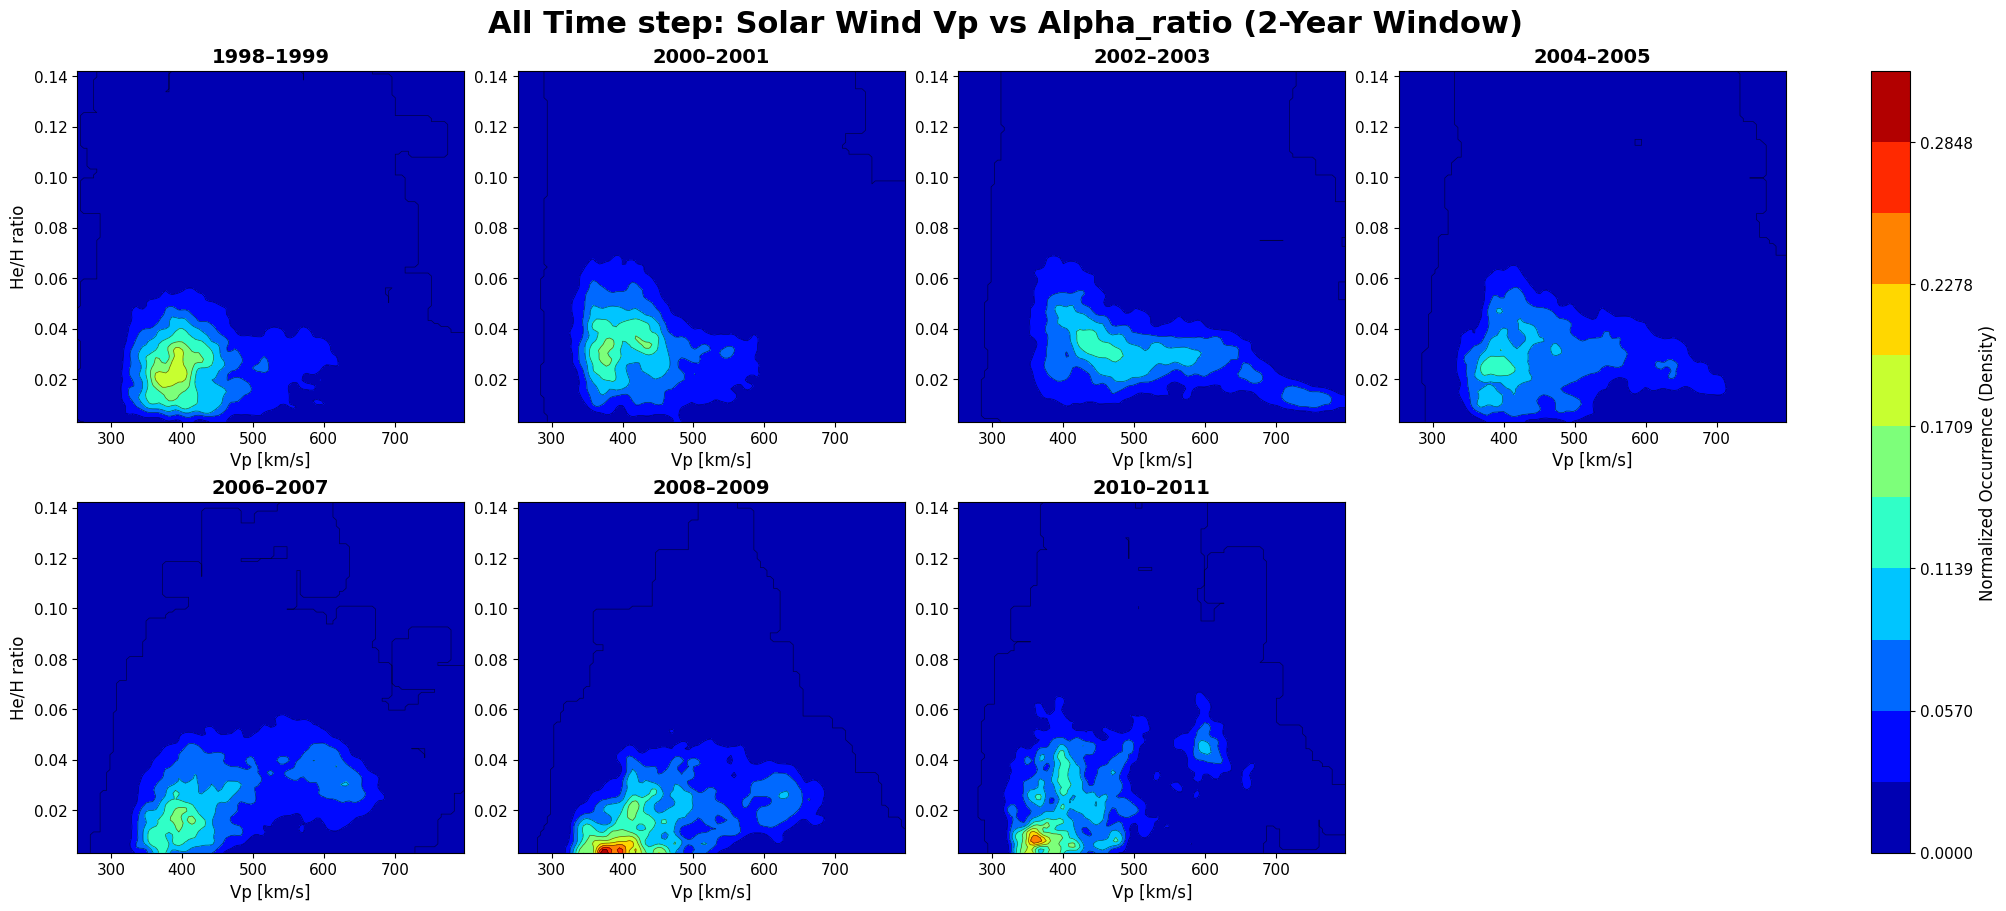

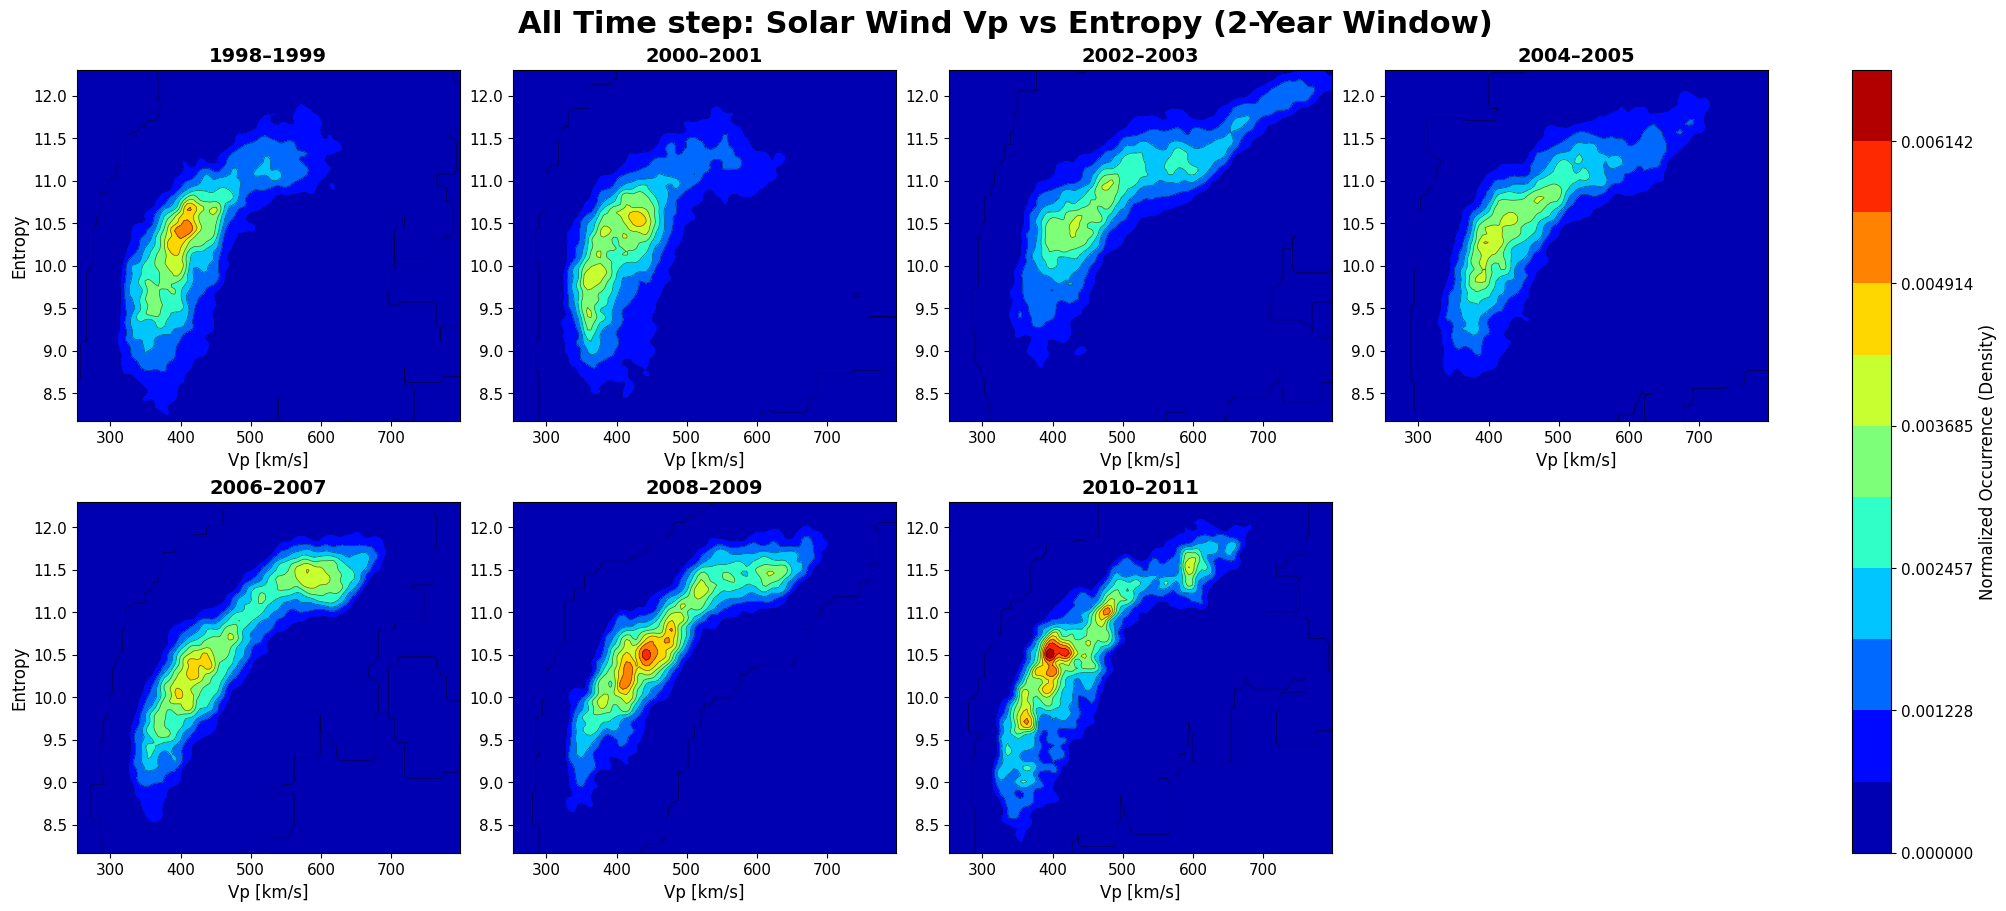

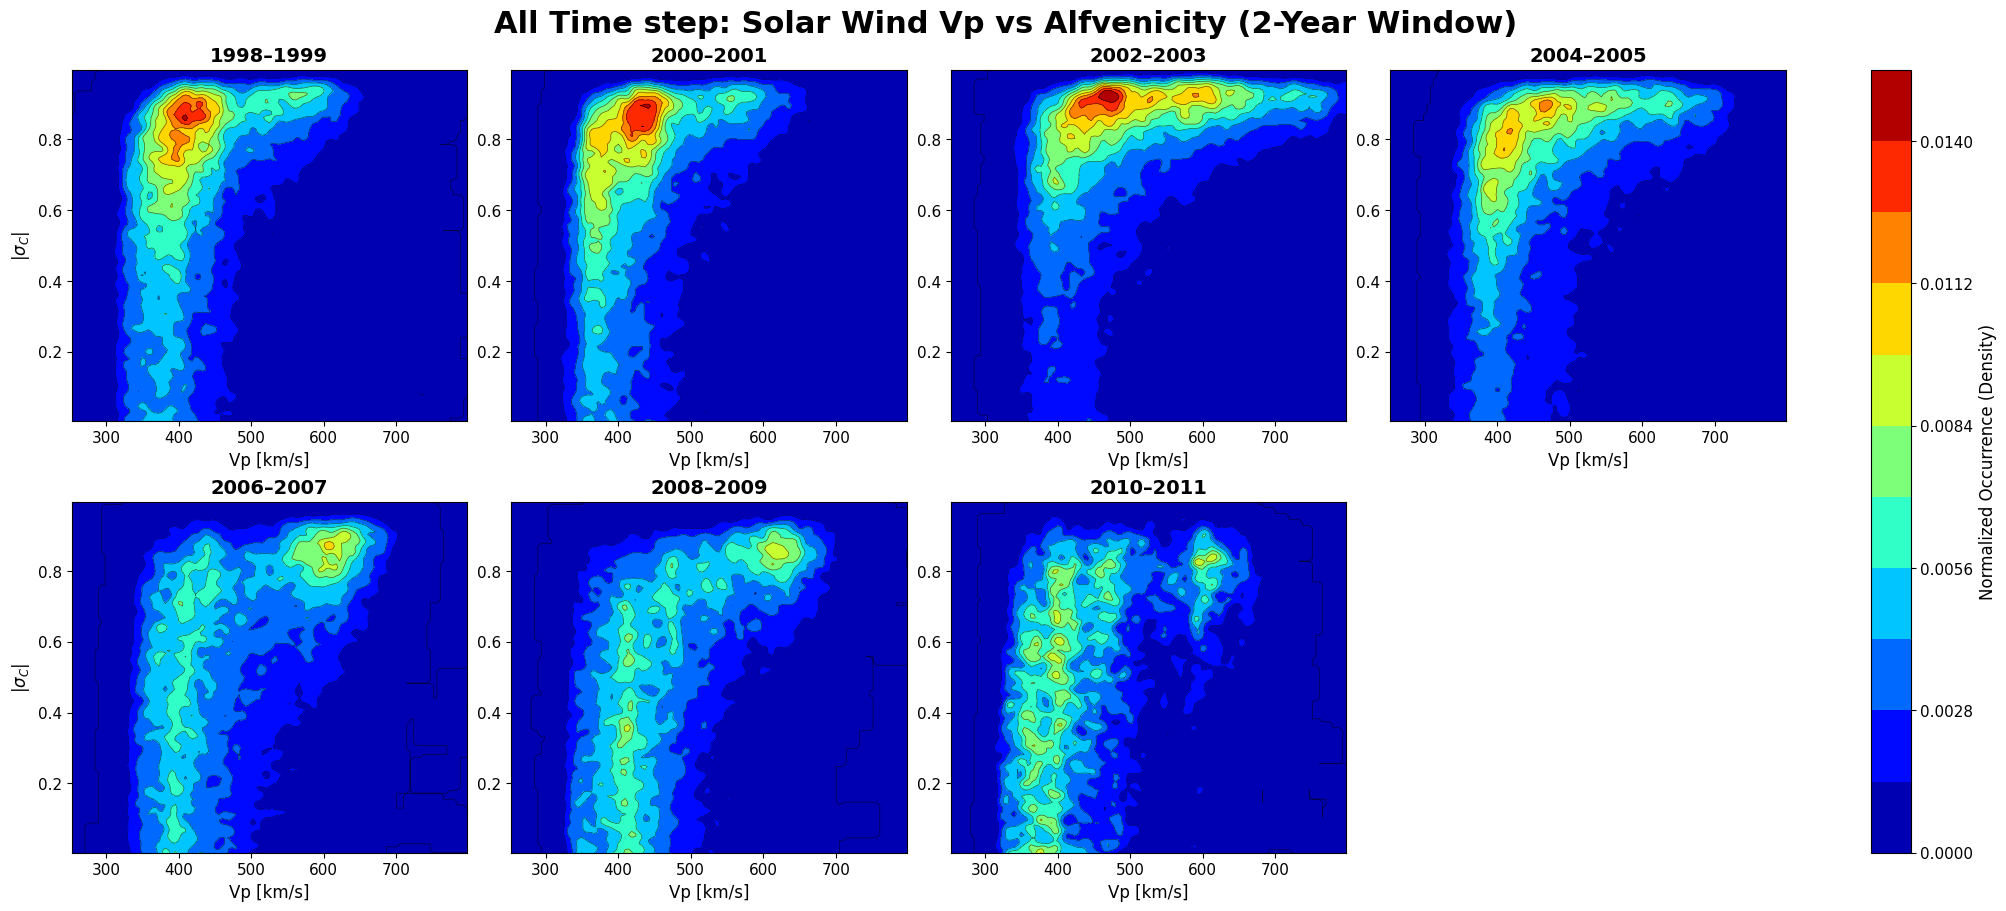

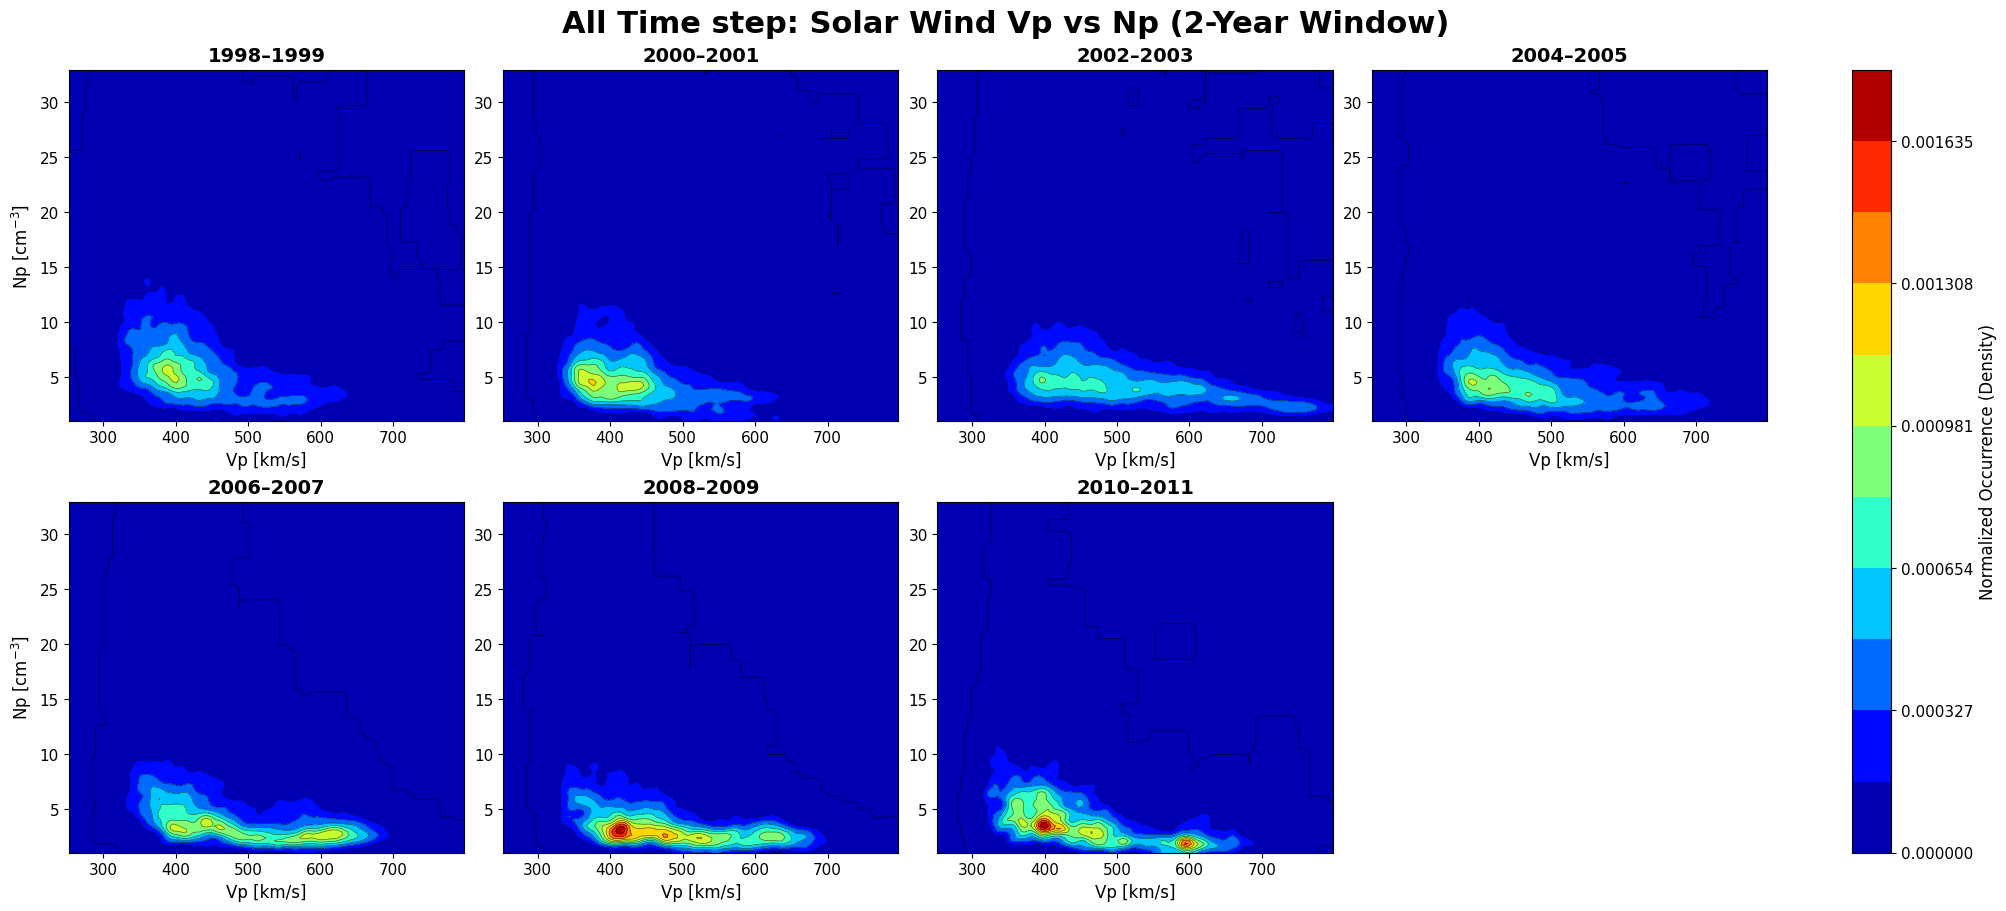

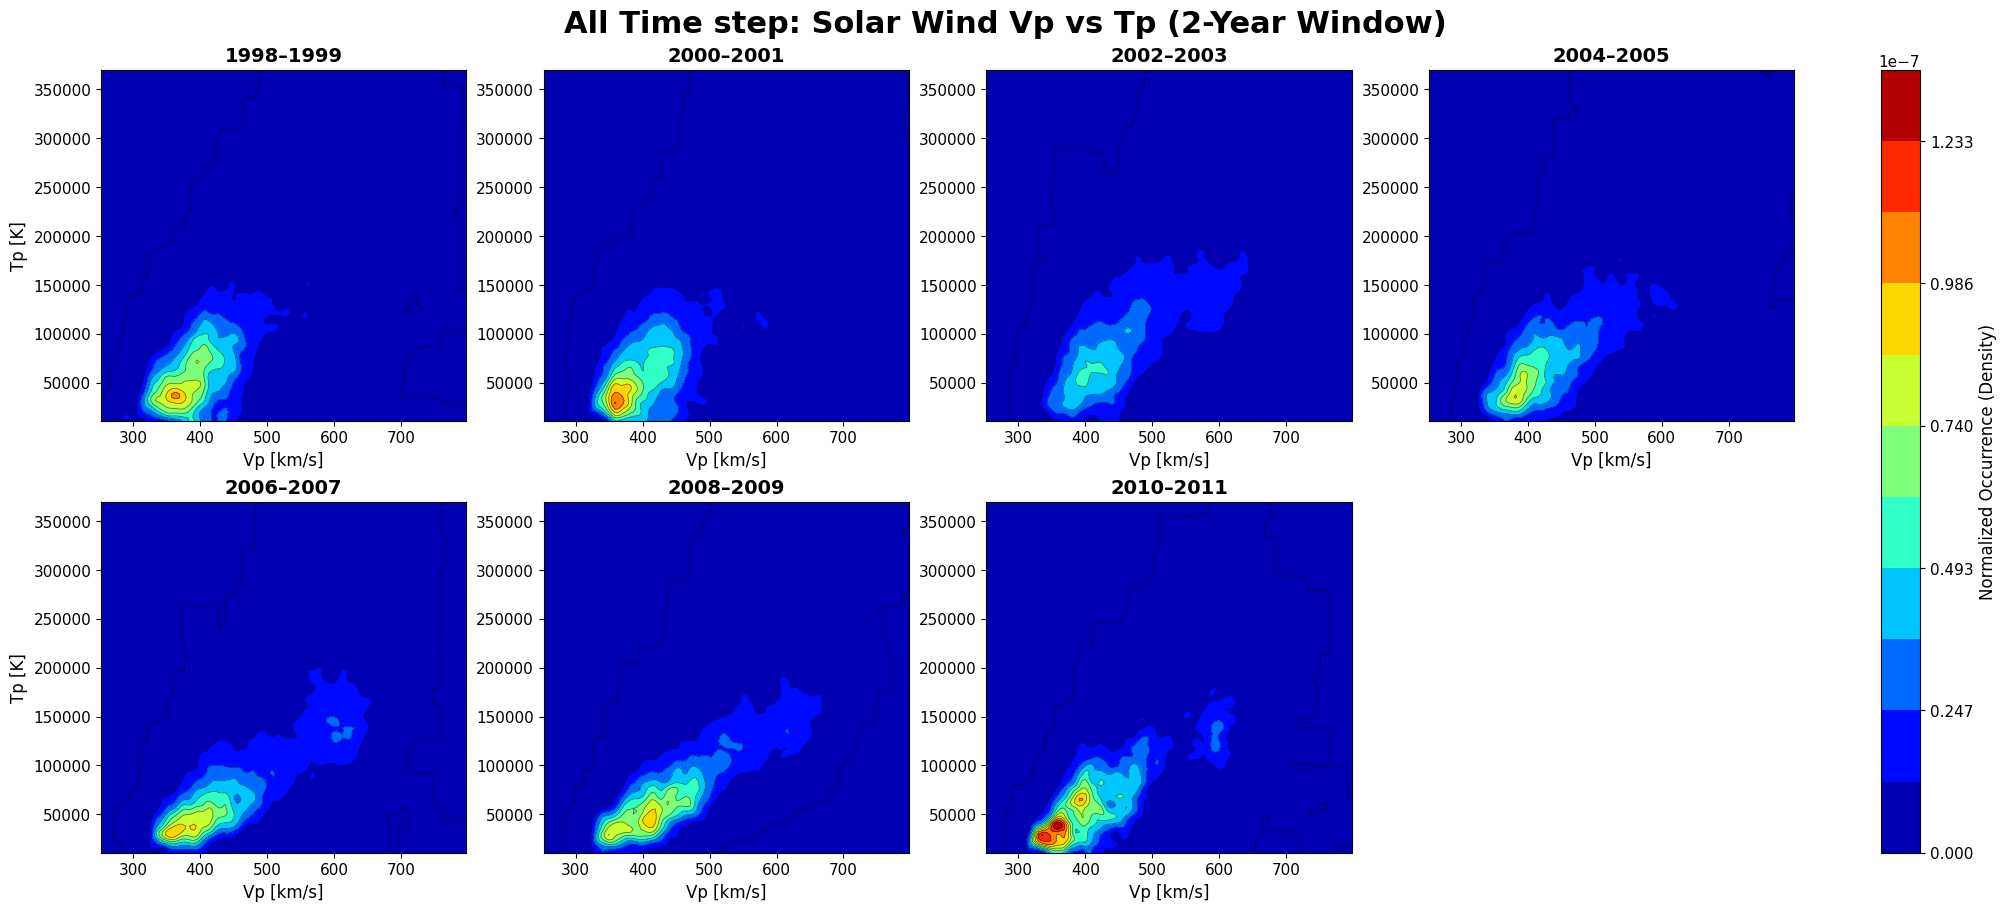

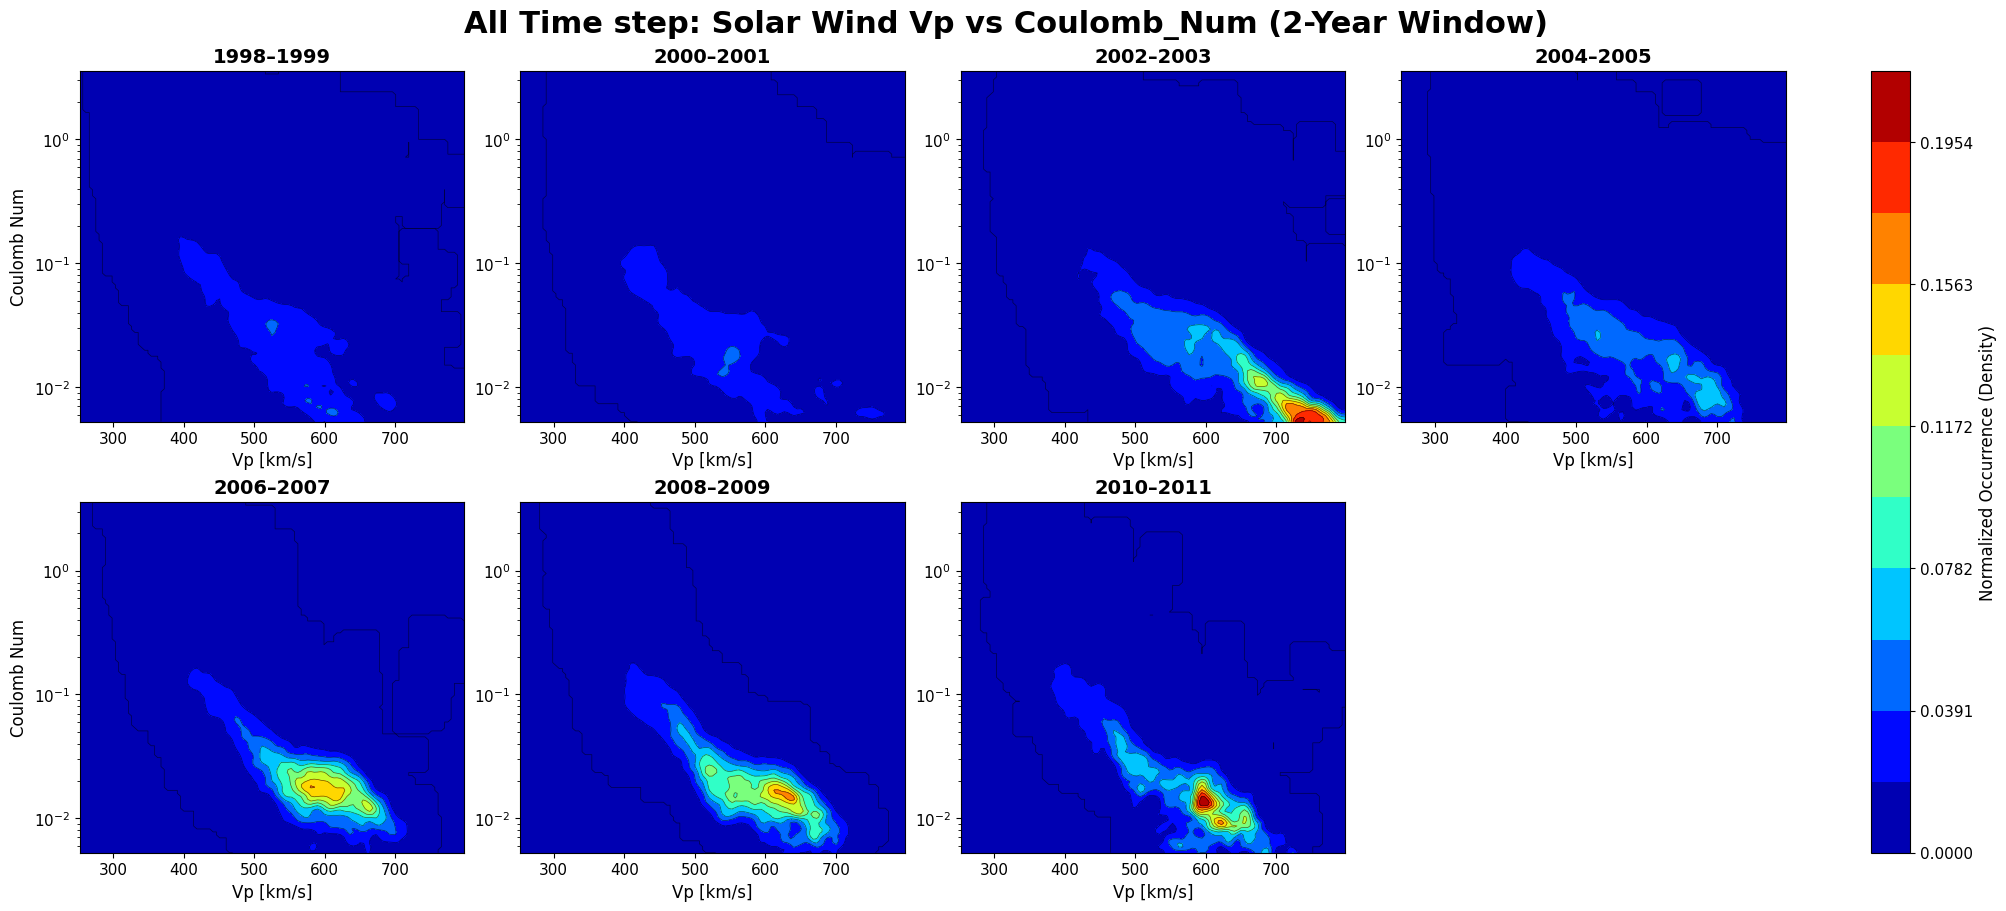

In [44]:
# ─ 설정 ───────────────────────────────
df_all = pd.DataFrame(inp_flat, columns=['Vp', 'Alpha_ratio', 'Entropy', 'Alfvenicity', 'Np', 'Tp', 'Coulomb_Num'])
df_all['time_col'] = np.repeat(time, 7)
df_all['time_col'] = pd.to_datetime(df_all['time_col'])

years = range(1998, 2012)
window = 2 # 2년 단위 묶음 (총 7개 구간)
# ────────────────────────────────────────

# 연도 구간 리스트 생성: [(1998,1999), (2000,2001), ..., (2010,2011)]
yrs = list(years)
year_ranges = []
for start in yrs[::window]:
    end = min(start + window - 1, yrs[-1])
    year_ranges.append((start, end))

# Vp 공통 x축 설정
x_bins = np.linspace(250, 800, 120)
x_cent = (x_bins[:-1] + x_bins[1:]) / 2

# 변수 리스트
target_vars = [
    ('Alpha_ratio', 'He/H ratio', False),
    ('Entropy', 'Entropy', False),
    ('Alfvenicity', r'$|\sigma_C|$', False),
    ('Np', 'Np [cm$^{-3}$]', False),
    ('Tp', 'Tp [K]', False),
    ('Coulomb_Num', 'Coulomb Num', True)
]

# 각 변수별로 타임라인 그리드 생성
for col, ylabel, is_log in target_vars:

    # 전체 데이터에서 해당 변수의 유효 데이터만 추출한다. (bin 계산용)
    valid_all = df_all.dropna(subset=['Vp', col]).copy()

    if is_log:
        valid_all = valid_all[valid_all[col] > 0]
        vmin, vmax = valid_all[col].quantile(0.01), valid_all[col].quantile(0.99)
        y_bins = np.logspace(np.log10(vmin), np.log10(vmax), 120)
    else:
        vmin, vmax = valid_all[col].quantile(0.005), valid_all[col].quantile(0.995)
        if col == 'Alfvenicity':
            y_bins = np.linspace(0, 1, 120)
        else:
            y_bins = np.linspace(vmin, vmax, 120)

    y_cent = (y_bins[:-1] + y_bins[1:]) / 2
    X, Y = np.meshgrid(x_cent, y_cent)

    # 각 구간별 히스토그램(H)을 저장할 리스트 & 글로벌 최대값
    Hs = []
    global_max = 0.0

    # 7개의 연도 구간에 대해 반복 계산한다.
    for start, end in year_ranges:
        mask = (valid_all['time_col'] >= f'{start}-01-01') & (valid_all['time_col'] <= f'{end}-12-31')
        df_rg = valid_all.loc[mask]

        if len(df_rg) > 0:
            H, _, _ = np.histogram2d(df_rg['Vp'], df_rg[col], bins=[x_bins, y_bins], density=True)
            H = gaussian_filter(H, sigma=1.2)
            global_max = max(global_max, H.max())
        else:
            H = np.zeros((len(x_bins)-1, len(y_bins)-1))
        Hs.append(H)

    levels = np.linspace(0, global_max if global_max > 0 else 1, 12)

    # 2행 4열 서브플롯 생성 (총 8칸 중 7칸 사용)
    fig, axes = plt.subplots(2, 4, figsize=(20, 9), constrained_layout=True)

    for idx, ((start, end), H) in enumerate(zip(year_ranges, Hs)):
        ax = axes.flatten()[idx]

        if H.max() > 0: # 데이터가 있는 경우만 그린다.
            cf = ax.contourf(X, Y, H.T, levels=levels, cmap='jet')
            ax.contour(X, Y, H.T, levels=levels, colors='k', linewidths=0.5, alpha=0.6)

        ax.set_title(f'{start}–{end}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Vp [km/s]', fontsize=12)

        # y축 라벨은 각 행의 첫 번째 그래프에만 표시한다.
        if idx % 4 == 0:
            ax.set_ylabel(ylabel, fontsize=12)

        if is_log: ax.set_yscale('log')

    # 남는 빈 축(8번째 칸) 제거
    fig.delaxes(axes.flatten()[7])

    # 공통 컬러바 추가
    cbar = fig.colorbar(cf, ax=axes.ravel().tolist(), label='Normalized Occurrence (Density)')

    # 메인 타이틀
    plt.suptitle(f'All Time step: Solar Wind Vp vs {col} (2-Year Window)', fontsize=22, fontweight='bold')
    plt.show()

#### Maximum / Minimum

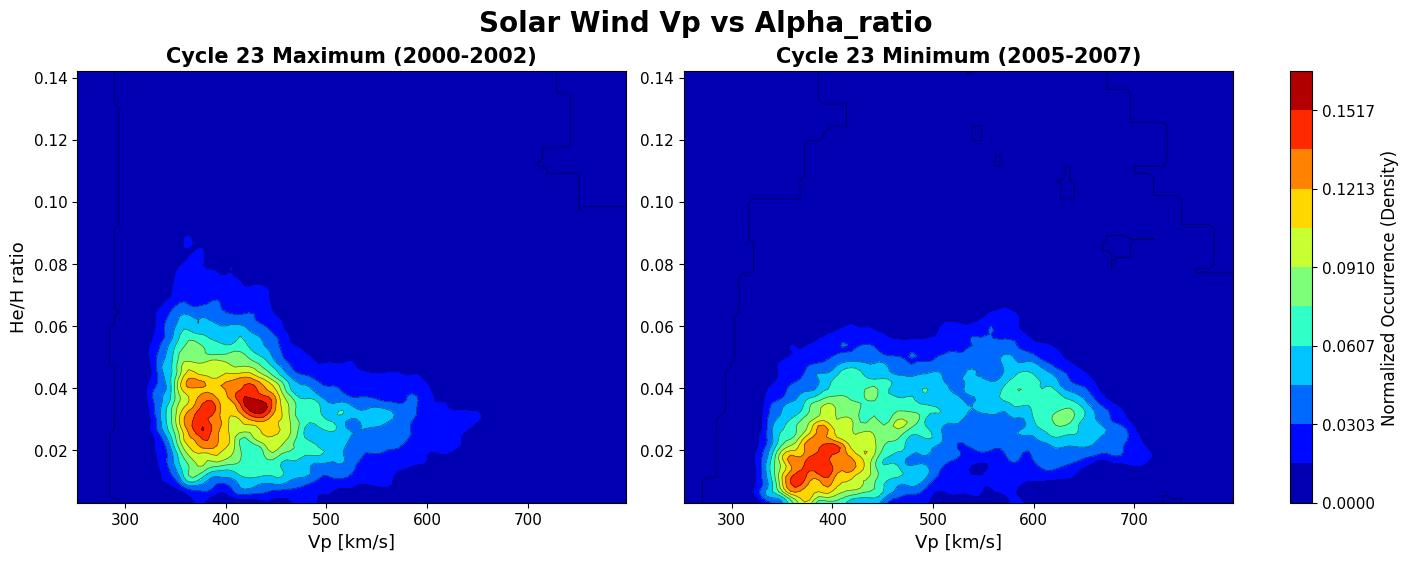

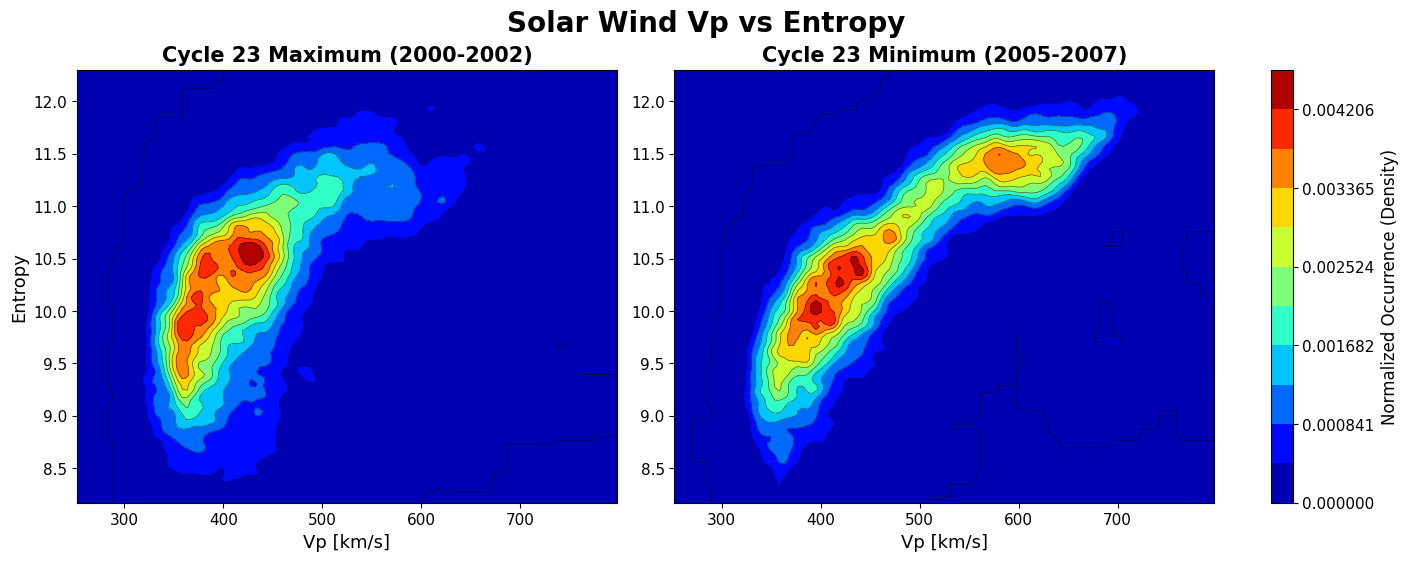

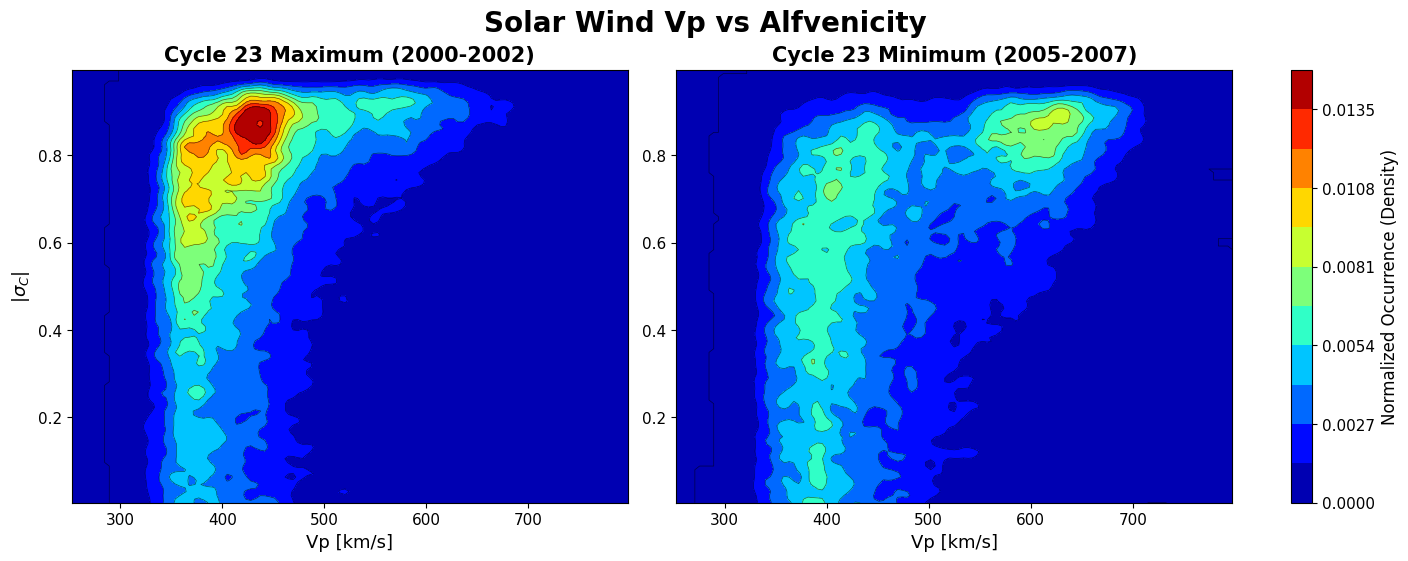

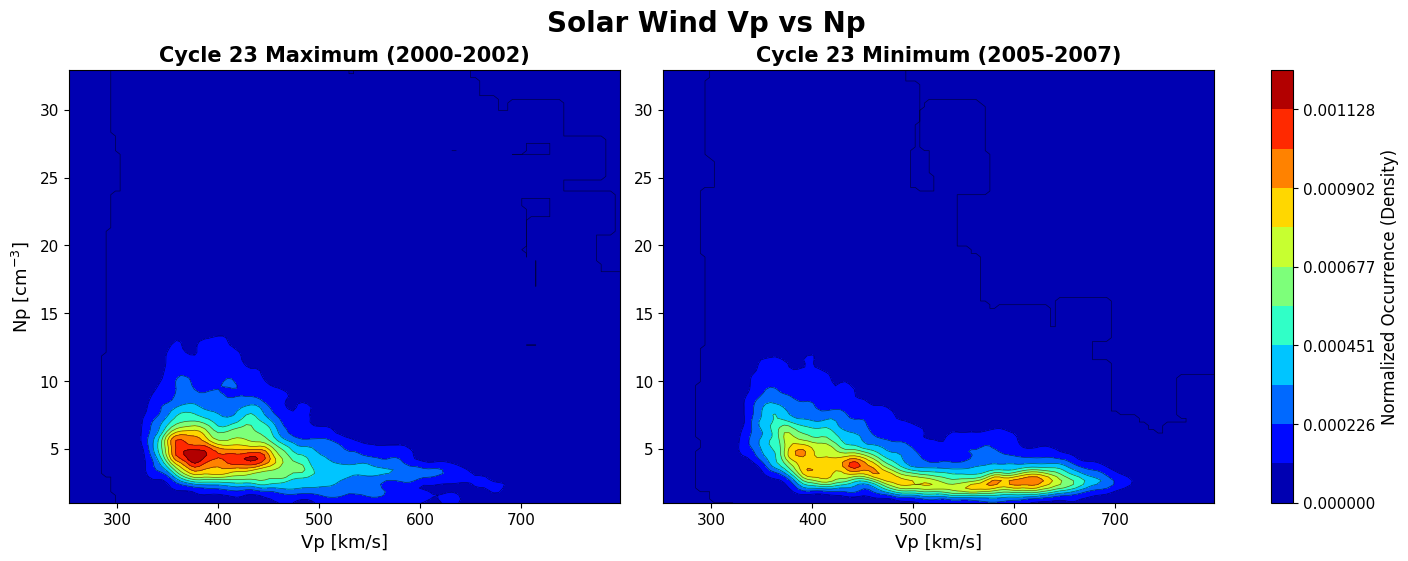

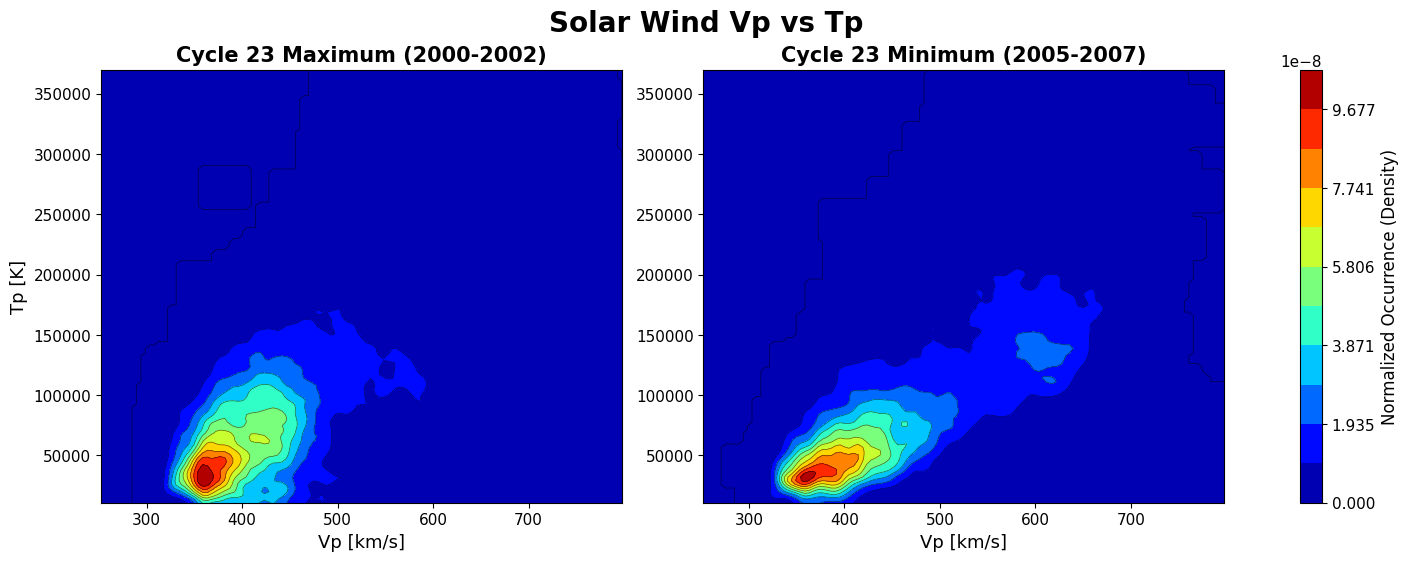

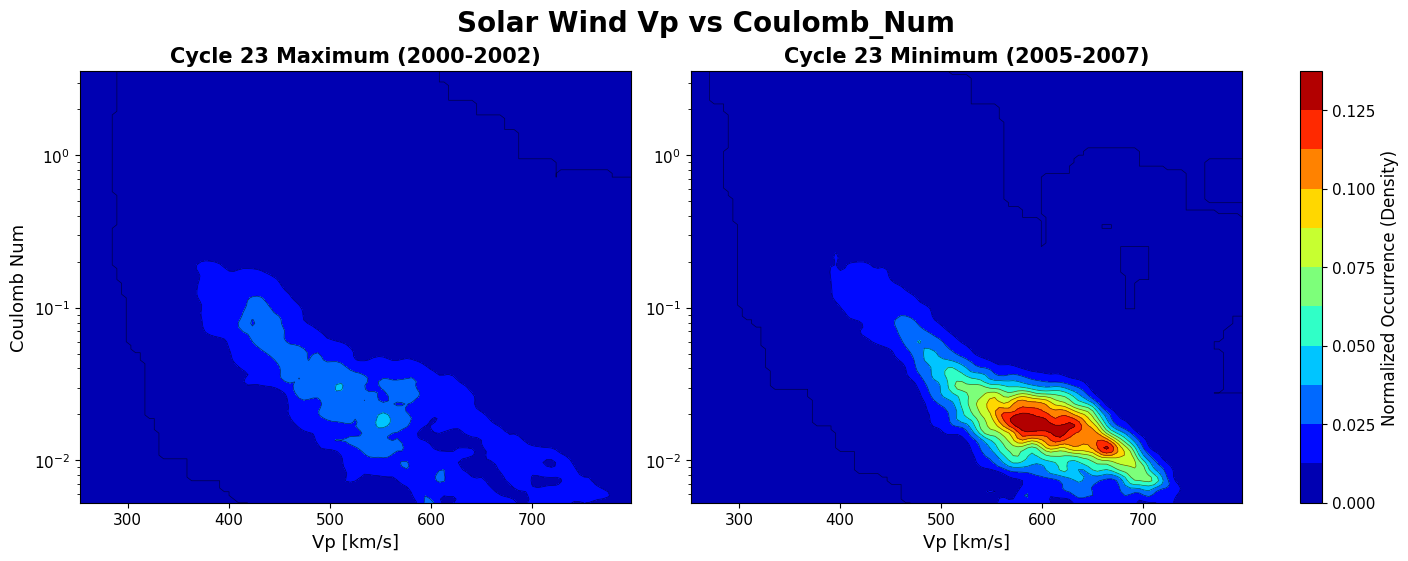

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# 데이터 준비
df_all = pd.DataFrame(inp_flat, columns=['Vp', 'Alpha_ratio', 'Entropy', 'Alfvenicity', 'Np', 'Tp', 'Coulomb_Num'])

# datetime 모듈 충돌을 피하기 위해 컬럼명을 'time_col'로 지정한다.
df_all['time_col'] = pd.to_datetime(repeated_time)
df_all['Alfvenicity'] = df_all['Alfvenicity'].abs() # 알펜성 절댓값 처리

# 태양 극대기(Maximum) / 극소기(Minimum) 기간 분리 (마스킹)
mask_max = (df_all['time_col'] >= '2000-01-01') & (df_all['time_col'] < '2002-07-02')
mask_min = (df_all['time_col'] >= '2005-07-01') & (df_all['time_col'] <= '2007-12-31')

df_max = df_all.loc[mask_max].copy()
df_min = df_all.loc[mask_min].copy()

# Vp(속도)의 공통 x축 구간
x_bins = np.linspace(250, 800, 120)
x_cent = (x_bins[:-1] + x_bins[1:]) / 2

# 그릴 변수들 리스트: (컬럼명, y축 라벨, 로그스케일 여부)
target_vars = [
    ('Alpha_ratio', 'He/H ratio', False),
    ('Entropy', 'Entropy', False),
    ('Alfvenicity', r'$|\sigma_C|$', False),
    ('Np', 'Np [cm$^{-3}$]', False),
    ('Tp', 'Tp [K]', False),
    ('Coulomb_Num', 'Coulomb Num', True)
]

# 각 변수별로 극대기 vs 극소기 그래프 생성
for col, ylabel, is_log in target_vars:

    # 결측치(NaN) 제거
    valid_max = df_max.dropna(subset=['Vp', col])
    valid_min = df_min.dropna(subset=['Vp', col])
    valid_all = df_all.dropna(subset=['Vp', col])

    if is_log:
        # 로그 스케일인 경우 (Coulomb Num) 0 이하 제거
        valid_max = valid_max[valid_max[col] > 0]
        valid_min = valid_min[valid_min[col] > 0]
        valid_all = valid_all[valid_all[col] > 0]

        # 이상치로 인한 시각적 왜곡 방지를 위해 하위 1%, 상위 99% 구간만 사용
        vmin, vmax = valid_all[col].quantile(0.01), valid_all[col].quantile(0.99)
        y_bins = np.logspace(np.log10(vmin), np.log10(vmax), 120)
    else:
        # 선형 스케일 아웃라이어 제거 (상/하위 0.5% 제거)
        vmin, vmax = valid_all[col].quantile(0.005), valid_all[col].quantile(0.995)

        # Alfvenicity는 0~1로 고정, 나머지는 계산된 min/max 사용
        if col == 'Alfvenicity':
            y_bins = np.linspace(0, 1, 120)
        else:
            y_bins = np.linspace(vmin, vmax, 120)

    y_cent = (y_bins[:-1] + y_bins[1:]) / 2
    X, Y = np.meshgrid(x_cent, y_cent)

    # 2D 히스토그램 (확률 밀도 density=True)
    H_max, _, _ = np.histogram2d(valid_max['Vp'], valid_max[col], bins=[x_bins, y_bins], density=True)
    H_min, _, _ = np.histogram2d(valid_min['Vp'], valid_min[col], bins=[x_bins, y_bins], density=True)

    # 가우시안 스무딩
    H_max = gaussian_filter(H_max, sigma=1.2)
    H_min = gaussian_filter(H_min, sigma=1.2)

    # 글로벌 스케일 통일 (Max와 Min 중 최대 확률밀도 기준)
    global_max = max(H_max.max(), H_min.max())
    levels = np.linspace(0, global_max, 12)

    # 플롯 그리기 (1행 2열)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

    # (a) Cycle 23 Maximum
    cf1 = axes[0].contourf(X, Y, H_max.T, levels=levels, cmap='jet')
    axes[0].contour(X, Y, H_max.T, levels=levels, colors='k', linewidths=0.5, alpha=0.6)
    axes[0].set_title('Cycle 23 Maximum (2000-2002)', fontsize=15, fontweight='bold')
    axes[0].set_xlabel('Vp [km/s]', fontsize=13)
    axes[0].set_ylabel(ylabel, fontsize=13)
    if is_log: axes[0].set_yscale('log')

    # (b) Cycle 23 Minimum
    cf2 = axes[1].contourf(X, Y, H_min.T, levels=levels, cmap='jet')
    axes[1].contour(X, Y, H_min.T, levels=levels, colors='k', linewidths=0.5, alpha=0.6)
    axes[1].set_title('Cycle 23 Minimum (2005-2007)', fontsize=15, fontweight='bold')
    axes[1].set_xlabel('Vp [km/s]', fontsize=13)
    if is_log: axes[1].set_yscale('log')

    # 공통 컬러바
    cbar = fig.colorbar(cf1, ax=axes, label='Normalized Occurrence (Density)')

    # 메인 타이틀
    plt.suptitle(f'Solar Wind Vp vs {col}', fontsize=20, fontweight='bold')
    plt.show()

### linear correlation


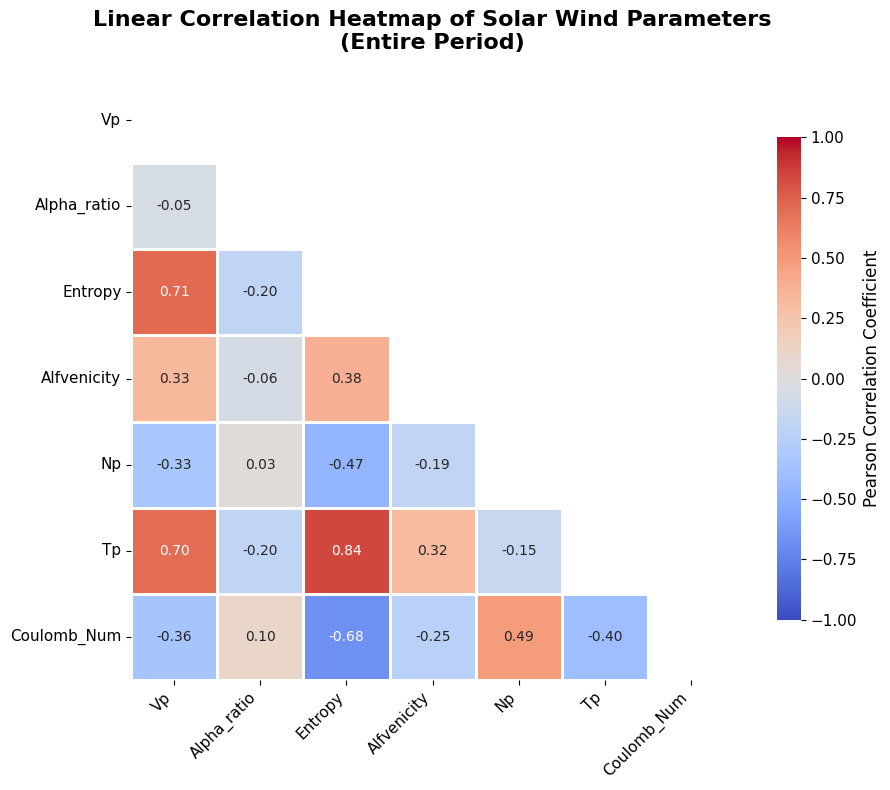

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

# 데이터 준비 (전체 기간 데이터)
df_all = pd.DataFrame(inp_flat, columns=[
    'Vp', 'Alpha_ratio', 'Entropy', 'Alfvenicity',
    'Np', 'Tp', 'Coulomb_Num'
])

# 피어슨 선형 상관계수(Pearson Correlation Coefficient) 계산
# pandas의 corr() 함수는 결측치(NaN)를 자동으로 제외하고 계산한다.
corr_matrix = df_all.corr(method='pearson')

# 시각화 설정
fig, ax = plt.subplots(figsize=(10, 8))

# 히트맵은 대각선을 기준으로 대칭(A-B와 B-A가 동일)이므로,
# 정보 중복을 피하고 가독성을 높이기 위해 우상단 절반을 가려주는 마스크(Mask)를 생성한다.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 히트맵 그리기
sns.heatmap(
    corr_matrix,
    mask=mask,               # 우상단 숨김 처리
    annot=True,              # 각 칸에 실제 상관계수 수치 표시
    fmt=".2f",               # 소수점 둘째 자리까지 표시
    cmap='coolwarm',         # 색상 테마 (파란색: 강한 음의 상관, 빨간색: 강한 양의 상관, 흰색: 상관없음)
    vmin=-1, vmax=1,         # 피어슨 상관계수 범위 (-1 ~ 1) 고정
    square=True,             # 각 칸을 정사각형 모양으로 맞춤
    linewidths=1,            # 칸 사이 경계선 굵기
    cbar_kws={
        "shrink": 0.8,
        "label": "Pearson Correlation Coefficient"
    },                       # 컬러바 크기 및 라벨 설정
    ax=ax
)

# 축 및 타이틀 정리
ax.set_title('Linear Correlation Heatmap of Solar Wind Parameters\n(Entire Period)',
             fontsize=16, fontweight='bold', pad=20)

# x축과 y축 라벨 회전 (글자가 겹치지 않도록)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

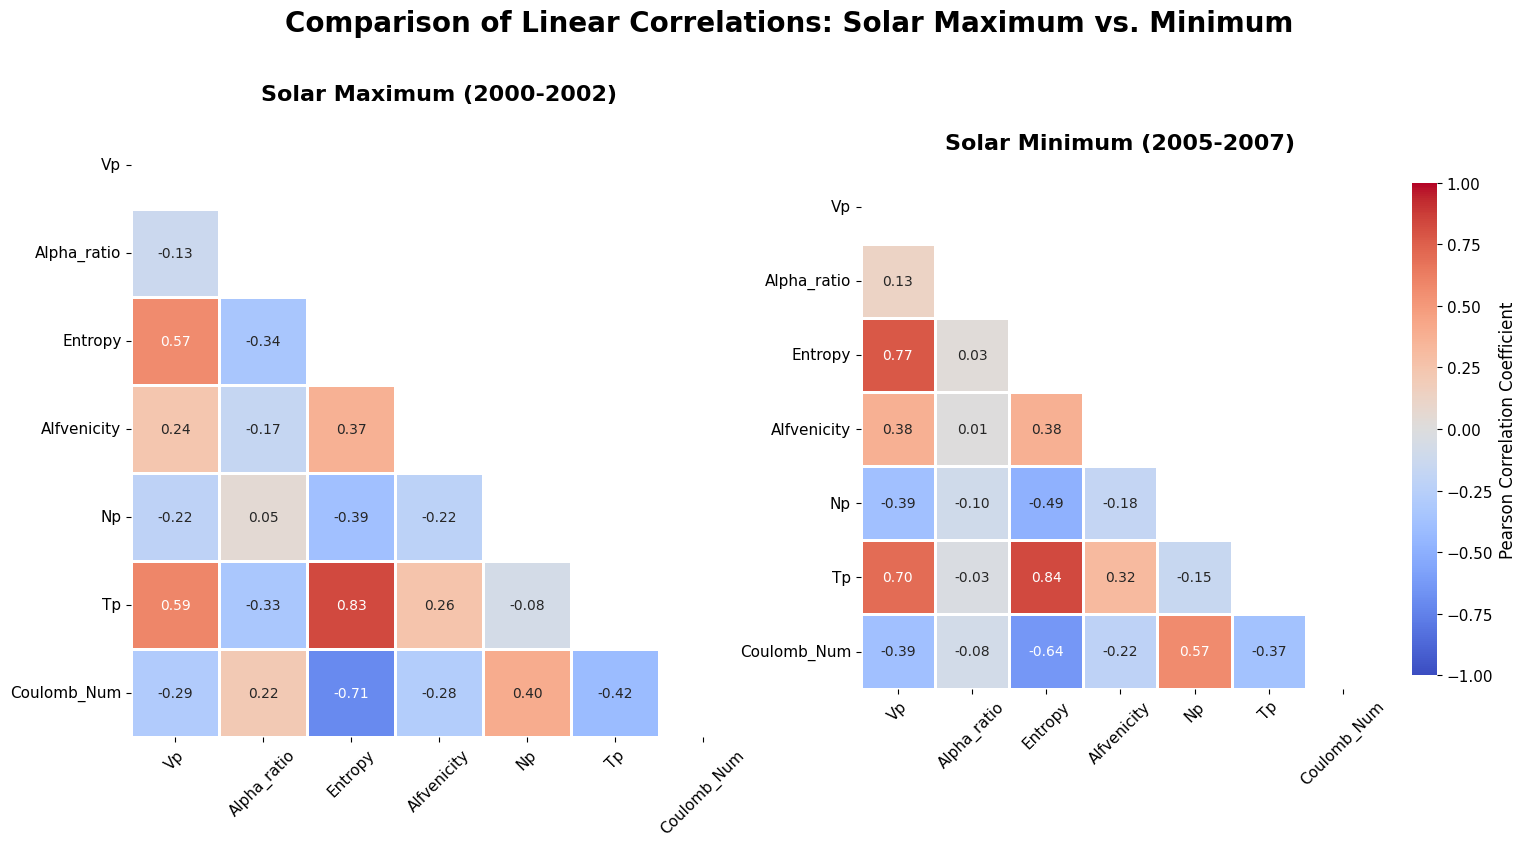

In [48]:
# 극대기/극소기

df_all = pd.DataFrame(inp_flat, columns=['Vp', 'Alpha_ratio', 'Entropy', 'Alfvenicity', 'Np', 'Tp', 'Coulomb_Num'])
df_all['time_col'] = pd.to_datetime(np.repeat(time, 7))

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

# 태양 극대기 (2000-2002) 데이터 필터링 및 상관계수 계산
mask_max = (df_all['time_col'].dt.year >= 2000) & (df_all['time_col'].dt.year <= 2002)
df_max = df_all.loc[mask_max, ['Vp', 'Alpha_ratio', 'Entropy', 'Alfvenicity', 'Np', 'Tp', 'Coulomb_Num']]
corr_max = df_max.corr(method='pearson')

# 태양 극소기 (2005-2007) 데이터 필터링 및 상관계수 계산
mask_min = (df_all['time_col'].dt.year >= 2005) & (df_all['time_col'].dt.year <= 2007)
df_min = df_all.loc[mask_min, ['Vp', 'Alpha_ratio', 'Entropy', 'Alfvenicity', 'Np', 'Tp', 'Coulomb_Num']]
corr_min = df_min.corr(method='pearson')

# 1행 2열의 나란한 서브플롯 생성
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plt.subplots_adjust(wspace=0.15) # 두 그래프 사이 간격 조정

# 우상단 숨김 마스크 공통 생성
mask = np.triu(np.ones_like(corr_max, dtype=bool))

# 히트맵 공통 사용 설정
heatmap_kws = {
    'mask': mask,
    'annot': True,
    'fmt': ".2f",
    'cmap': 'coolwarm',
    'vmin': -1,
    'vmax': 1,
    'square': True,
    'linewidths': 1
}

# 첫 번째 그래프: 극대기 (Solar Maximum)
sns.heatmap(corr_max, ax=axes[0], cbar=False, **heatmap_kws) # 컬러바는 중복되므로 왼쪽은 숨긴다.
axes[0].set_title('Solar Maximum (2000-2002)', fontsize=16, fontweight='bold', pad=15)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# 두 번째 그래프: 극소기 (Solar Minimum)
# 오른쪽 그래프에만 컬러바를 표시한다.
sns.heatmap(corr_min, ax=axes[1], cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient"}, **heatmap_kws)
axes[1].set_title('Solar Minimum (2005-2007)', fontsize=16, fontweight='bold', pad=15)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Comparison of Linear Correlations: Solar Maximum vs. Minimum',
             fontsize=20, fontweight='bold', y=1.02)

plt.show()